In [1]:
# Load libraries
library(DESeq2)
library(ggrepel)
library(ggplot2)
library(fgsea)
library(stringr)
library(dplyr)
library(gage)
library(ggplot2)
#install.packages(c("ggplot2", "ggrepel", "cowplot", "stringr"))

Loading required package: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.3.2”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

   

# MAST Results

In [3]:
setwd('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/mast/')

In [4]:
mast_0 = read.csv('leiden_res_0.1_0.csv')

In [6]:
head(mast_0)

,X,primerid,Pr..Chisq.,coef,ci.hi,ci.lo,fdr
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,A1CF,0,0.21734108,0.22625563,0.20842653,0
2,2,ABCC3,0,0.19591038,0.20447578,0.18734498,0
3,3,ABHD12B,0,0.13629124,0.14266207,0.12992041,0
4,4,ABI2,0,-0.20735166,-0.19953865,-0.21516467,0
5,5,ABRACL,0,0.32659174,0.33584450,0.31733897,0
6,6,AC002069.2,0,0.08370299,0.08844915,0.07895683,0


In [13]:
fdr <= mast_0$fdr
coef <= mast_0$coef

mast_0_sig = mast_0[fdr < 0.05 & abs(coef) > 0.6, ]
# filtered_data <- data[data$FDR <= 0.05 & data$LogFC > 0.6, ]
# fdr<.05 & abs(coef)>FCTHRESHOLD
mast_0_sig

ERROR: Error in eval(expr, envir, enclos): object 'fdr' not found


In [21]:
# Remove rows with NA values
mast_0_clean <- na.omit(mast_0)

# Extract fdr and coef columns
fdr_0 <- mast_0_clean$fdr
coef_0 <- mast_0_clean$coef

# Filter the data based on FDR and coefficient criteria
mast_0_sig <- mast_0_clean[fdr_0 < 0.05 & abs(coef_0) > 0.6, ]

# View the filtered data
mast_0_sig

,X,primerid,Pr..Chisq.,coef,ci.hi,ci.lo,fdr
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
65,65,APOA2,0,-0.8641179,-0.8549103,-0.8733254,0
117,117,C15orf48,0,0.8371071,0.8475052,0.8267091,0
118,118,C19orf33,0,0.7580771,0.7667930,0.7493611,0
207,207,COTL1,0,-0.6482835,-0.6389586,-0.6576084,0
439,439,ID1,0,0.9627594,0.9713209,0.9541979,0
440,440,ID3,0,0.6741279,0.6827550,0.6655007,0
683,683,PHGR1,0,0.8246436,0.8319645,0.8173228,0
877,877,SLC26A2,0,0.8268782,0.8366908,0.8170656,0
893,893,SMOC2,0,-1.1583764,-1.1504585,-1.1662944,0


In [22]:
mast_0_sig$primerid

[1] "APOA2"    "C15orf48" "C19orf33" "COTL1"    "ID1"      "ID3"     
 [7] "PHGR1"    "SLC26A2"  "SMOC2"    "SPINK1"

In [15]:
mast_6 = read.csv('leiden_res_0.1_6.csv')

In [20]:
# Remove rows with NA values
mast_6_clean <- na.omit(mast_6)

# Extract fdr and coef columns
fdr_6 <- mast_6_clean$fdr
coef_6 <- mast_6_clean$coef

# Filter the data based on FDR and coefficient criteria
mast_6_sig <- mast_6_clean[fdr_6 < 0.05 & abs(coef_6) > 0.6, ]

# View the filtered data
mast_6_sig

,X,primerid,Pr..Chisq.,coef,ci.hi,ci.lo,fdr
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,3,AC099520.1,0.000000e+00,1.8447013,1.8789027,1.8105000,0.000000e+00
4,4,ADAMTS19,0.000000e+00,1.3783231,1.4010465,1.3555997,0.000000e+00
6,6,AL022068.1,0.000000e+00,0.9595661,0.9915800,0.9275523,0.000000e+00
7,7,AREG,0.000000e+00,0.6804025,0.7048542,0.6559507,0.000000e+00
12,12,CD24,0.000000e+00,0.6592692,0.6847626,0.6337759,0.000000e+00
14,14,CNOT6L,0.000000e+00,0.9617507,0.9849689,0.9385324,0.000000e+00
19,19,GMCL1,0.000000e+00,0.9491291,0.9678985,0.9303598,0.000000e+00
22,22,ID1,0.000000e+00,0.7980943,0.8213986,0.7747900,0.000000e+00
23,23,ID3,0.000000e+00,0.6407142,0.6696405,0.6117879,0.000000e+00


In [26]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
mast_6_sig_sorted <- mast_6_sig[order(mast_6_sig$coef, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes_1 <- head(mast_6_sig_sorted, 20)
top_upregulated_genes_1

# Top 10 downregulated genes
top_downregulated_genes_1 <- tail(mast_6_sig_sorted, 0)
top_downregulated_genes_1

,X,primerid,Pr..Chisq.,coef,ci.hi,ci.lo,fdr,Category
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
3,3,AC099520.1,0.000000e+00,1.8447013,1.8789027,1.8105000,0.000000e+00,Upregulated
4,4,ADAMTS19,0.000000e+00,1.3783231,1.4010465,1.3555997,0.000000e+00,Upregulated
38,38,S100A4,0.000000e+00,1.1220806,1.1456737,1.0984876,0.000000e+00,Upregulated
40,40,SEMA3A,0.000000e+00,1.0166051,1.0380897,0.9951204,0.000000e+00,Upregulated
14,14,CNOT6L,0.000000e+00,0.9617507,0.9849689,0.9385324,0.000000e+00,Upregulated
6,6,AL022068.1,0.000000e+00,0.9595661,0.9915800,0.9275523,0.000000e+00,Upregulated
19,19,GMCL1,0.000000e+00,0.9491291,0.9678985,0.9303598,0.000000e+00,Upregulated
24,24,KDM3A,0.000000e+00,0.8772242,0.9022968,0.8521516,0.000000e+00,Upregulated
36,36,RUBCNL,0.000000e+00,0.8395323,0.8663979,0.8126668,0.000000e+00,Upregulated


X,primerid,Pr..Chisq.,coef,ci.hi,ci.lo,fdr,Category
<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>


Warning message:
“ggrepel: 18 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


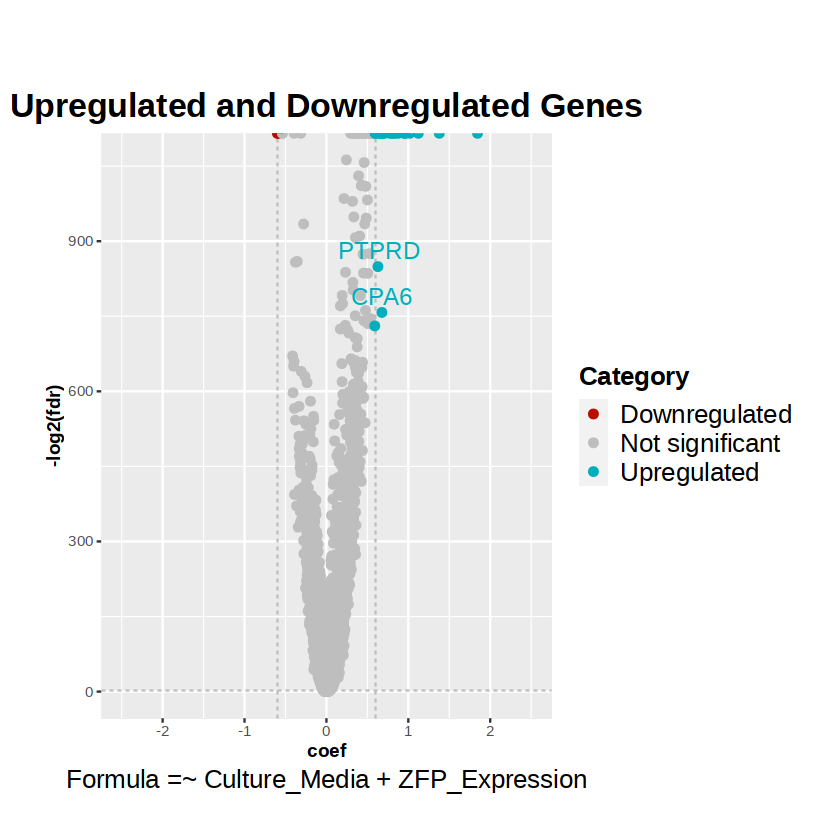

In [32]:
# Volcano plot
# Define significant genes based on the value of padj and log2FoldChange
mast_6_clean$Category <- ifelse(mast_6_clean$fdr < 0.05 & abs(mast_6_clean$coef) > log2(1.5),
                            ifelse(mast_6_clean$coef > 0, "Upregulated", "Downregulated"),
                            "Not significant")

# Filter out rows with missing values
mast_6_clean <- na.omit(mast_6_clean)

# Customize the plot
custom_theme <- theme(
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold"),
    legend.text = element_text(size = 15),
    legend.title = element_text(size = 15, face = "bold"),
    axis.title.x = element_text(face="bold"),
    axis.title.y = element_text(face="bold"),
    plot.caption = element_text(hjust = 0.5, size = 15),
    plot.margin = margin(2, 1, 1, 1, "cm") # Adjust margins
)

# Your existing ggplot code with modifications for theme settings
ggplot(data = mast_6_clean, aes(x = coef, y = -log2(fdr), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.02), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-2.5, 2.5)) +
  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_1,
            aes(label = top_upregulated_genes_1$primerid), 
            nudge_y = 0.5, color = "#00AFBB", size = 5) +
  
  geom_text_repel(data = top_downregulated_genes_1,
            aes(label = rownames(top_downregulated_genes_1)), 
            nudge_y = -0.3, color = "#bb0c00", size = 5) +

 labs(title = stringr::str_wrap("Significant Upregulated and Downregulated Genes", width = 50), 
      caption = stringr::str_wrap("Formula =~ Culture_Media + ZFP_Expression", width = 50)) +

  ggtitle('Upregulated and Downregulated Genes') + 
  custom_theme 


In [33]:
# Volcano plot
# Define significant genes based on the value of padj and log2FoldChange
mast_6_clean$Category <- ifelse(mast_6_clean$fdr < 0.05 & abs(mast_6_clean$coef) > log2(1.5),
                            ifelse(mast_6_clean$coef > 0, "Upregulated", "Downregulated"),
                            "Not significant")

# Filter out rows with missing values
mast_6_clean <- na.omit(mast_6_clean)

# Customize the plot
custom_theme <- theme(
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold"),
    legend.text = element_text(size = 15),
    legend.title = element_text(size = 15, face = "bold"),
    axis.title.x = element_text(face="bold"),
    axis.title.y = element_text(face="bold"),
    plot.caption = element_text(hjust = 0.5, size = 15),
    plot.margin = margin(1, 1, 1, 1, "cm") # Adjust margins
)

# Your existing ggplot code with modifications for theme settings
ggplot(data = mast_6_clean, aes(x = coef, y = -log2(fdr), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.02), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-2.5, 2.5), ylim = c(0, max(-log2(mast_6_clean$fdr)))) + # Adjust ylim
  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_1,
            aes(label = top_upregulated_genes_1$primerid), 
            nudge_y = 0.5, color = "#00AFBB", size = 5) +
  
  geom_text_repel(data = top_downregulated_genes_1,
            aes(label = rownames(top_downregulated_genes_1)), 
            nudge_y = -0.3, color = "#bb0c00", size = 5) +

 labs(title = stringr::str_wrap("Significant Upregulated and Downregulated Genes", width = 50), 
      caption = stringr::str_wrap("Formula =~ Culture_Media + ZFP_Expression", width = 50)) +

  ggtitle('Upregulated and Downregulated Genes') + 
  custom_theme 


Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
ERROR while rich displaying an object: Error in if (d > 0) {: missing value where TRUE/FALSE needed

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . 

In [34]:
# Your existing ggplot code with modifications for theme settings
ggplot(data = mast_6_clean, aes(x = coef, y = -log2(fdr), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.02), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-2.5, 2.5), ylim = c(0, max(-log2(mast_6_clean$fdr)))) + # Adjust ylim
  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_1,
            aes(label = top_upregulated_genes_1$primerid), 
            nudge_y = 0.5, color = "#00AFBB", size = 5, max.overlaps = 20) + # Increase max.overlaps
  geom_text_repel(data = top_downregulated_genes_1,
            aes(label = rownames(top_downregulated_genes_1)), 
            nudge_y = -0.3, color = "#bb0c00", size = 5, max.overlaps = 20) + # Increase max.overlaps

 labs(title = stringr::str_wrap("Significant Upregulated and Downregulated Genes", width = 50), 
      caption = stringr::str_wrap("Formula =~ Culture_Media + ZFP_Expression", width = 50)) +

  ggtitle('Upregulated and Downregulated Genes') + 
  custom_theme 


ERROR while rich displaying an object: Error in if (d > 0) {: missing value where TRUE/FALSE needed

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler)
6. repr::mime2repr[[mime]](obj)
7. repr_text.default(obj)
8. paste(capture.outpu

## DESeq2 Results: Metastatic Tumor Site

### Formula ~ Culture_Media + ZFP_Expression

In [5]:
# Load the DESeq2 Results
dds = readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/deseq/metastatic_zfpexp_dds_v2.rds")

# Take a look at the results names
resultsNames(dds)

[1] "Intercept"                     "Culture_Media_HISC_vs_BASE"   
[3] "ZFP_Expression_ZFP_KD_vs_CTRL"

In [8]:
# Contrast between ZFPKD and CTRL
res <- results(dds, contrast = c("ZFP_Expression", "ZFP_KD", "CTRL"))

res_df <- as.data.frame(res)
head(res_df)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,1.002173,4.361684e-04,0.02478563,0.017597636,0.98595984,NA
A1BG-AS1,1.001359,-8.000481e-04,0.02479147,-0.032271101,0.97425585,NA
A1CF,1.360032,-3.697914e-02,0.02116202,-1.747429787,0.08056281,0.3375714
A2M,1.001484,-5.503755e-04,0.02479079,-0.022200805,0.98228778,NA
A2M-AS1,1.001359,4.542178e-05,0.02479433,0.001831942,0.99853832,NA
A2ML1,1.001547,-8.348480e-04,0.02478902,-0.033678136,0.97313381,NA


In [11]:
# Extract only the significant genes based on the value of padj and log2FoldChange
res_df$Significant = res_df$padj < 0.05 & abs(res_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
sig_genes_df = res_df[res_df$Significant,]
sig_genes_df <- sig_genes_df[complete.cases(sig_genes_df$padj), ]
sig_genes_df <- na.omit(sig_genes_df)
sig_genes_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AL365295.1,1.320097,-0.7363353,0.02012554,-36.58711,4.586231e-293,4.688962e-289,TRUE


### Formula ~ Culture_Media + ZFP_Expression + ZFP_Expression:Culture_Media

In [12]:
# Load the DESeq2 Results
dds = readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/deseq/metastatic_zfpexp_cmint_dds_v2.rds")

# Take a look at the results names
resultsNames(dds)

[1] "Intercept"                             
[2] "Culture_Media_HISC_vs_BASE"            
[3] "ZFP_Expression_ZFP_KD_vs_CTRL"         
[4] "Culture_MediaHISC.ZFP_ExpressionZFP_KD"

In [13]:
# Contrast between ZFPKD and CTRL
res <- results(dds, contrast = c("ZFP_Expression", "ZFP_KD", "CTRL"))

res_df <- as.data.frame(res)
head(res_df)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,1.002173,-9.710135e-05,0.03526256,-0.002753667,0.99780289,NA
A1BG-AS1,1.001359,-1.554435e-03,0.03525350,-0.044093072,0.96483021,NA
A1CF,1.360032,-5.748555e-02,0.02850625,-2.016594391,0.04373786,0.1861081
A2M,1.001484,-3.631095e-04,0.03526356,-0.010297017,0.99178431,NA
A2M-AS1,1.001359,4.989305e-04,0.03526759,0.014146996,0.98871271,NA
A2ML1,1.001547,-1.022468e-03,0.03525149,-0.029004952,0.97686064,NA


In [14]:
# Extract only the significant genes based on the value of padj and log2FoldChange
res_df$Significant = res_df$padj < 0.05 & abs(res_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
sig_genes_df = res_df[res_df$Significant,]
sig_genes_df <- sig_genes_df[complete.cases(sig_genes_df$padj), ]
sig_genes_df <- na.omit(sig_genes_df)
sig_genes_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC099520.1,1.343627,0.6232509,0.03290047,18.94353,4.993551e-80,2.0908e-76,TRUE


## DESeq2 Results: Primary Tumor Site

### Formula ~ Culture_Media + ZFP_Expression

In [17]:
# Load the DESeq2 Results
dds = readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/deseq/primary_zfpexp_dds.rds")

# Take a look at the results names
resultsNames(dds)

[1] "Intercept"                             
[2] "Culture_Media_Dedifferentiated_vs_BASE"
[3] "Culture_Media_HISC_vs_BASE"            
[4] "ZFP_Expression_ZFP_KD_vs_CTRL"

In [18]:
# Contrast between ZFPKD and CTRL
res <- results(dds, contrast = c("ZFP_Expression", "ZFP_KD", "CTRL"))

res_df <- as.data.frame(res)
head(res_df)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,1.002136,7.163653e-04,0.01789796,0.0400249590,9.680732e-01,NA
A1BG-AS1,1.001641,-4.280749e-06,0.01790047,-0.0002391416,9.998092e-01,NA
A1CF,1.462190,9.116172e-02,0.01499212,6.0806447092,1.197003e-09,7.601339e-08
A2M,1.002895,-3.334759e-03,0.01788145,-0.1864926117,8.520585e-01,NA
A2M-AS1,1.002697,-2.460161e-03,0.01788534,-0.1375518397,8.905946e-01,NA
A2ML1,1.001971,-6.516213e-04,0.01789603,-0.0364115018,9.709542e-01,NA


In [19]:
# Extract only the significant genes based on the value of padj and log2FoldChange
res_df$Significant = res_df$padj < 0.05 & abs(res_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
sig_genes_df = res_df[res_df$Significant,]
sig_genes_df <- sig_genes_df[complete.cases(sig_genes_df$padj), ]
sig_genes_df <- na.omit(sig_genes_df)
sig_genes_df

baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>


### Formula ~ Culture_Media + ZFP_Expression + Culture_Media:ZFP_Expression

In [20]:
# Load the DESeq2 Results
dds = readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/deseq/primary_zfpexp_cmint_dds.rds")

# Take a look at the results names
resultsNames(dds)

[1] "Intercept"                                         
[2] "Culture_Media_Dedifferentiated_vs_BASE"            
[3] "Culture_Media_HISC_vs_BASE"                        
[4] "ZFP_Expression_ZFP_KD_vs_CTRL"                     
[5] "Culture_MediaDedifferentiated.ZFP_ExpressionZFP_KD"
[6] "Culture_MediaHISC.ZFP_ExpressionZFP_KD"

In [21]:
# Contrast between ZFPKD and CTRL
res <- results(dds, contrast = c("ZFP_Expression", "ZFP_KD", "CTRL"))

res_df <- as.data.frame(res)
head(res_df)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,1.002136,0.0005680433,0.02863520,0.019837239,0.9841732112,NA
A1BG-AS1,1.001641,-0.0001898240,0.02863395,-0.006629334,0.9947105952,NA
A1CF,1.462190,0.0829603497,0.02315709,3.582503700,0.0003403168,0.03027244
A2M,1.002895,-0.0034015260,0.02859957,-0.118936247,0.9053258643,NA
A2M-AS1,1.002697,-0.0020815351,0.02861768,-0.072735976,0.9420162199,NA
A2ML1,1.001971,-0.0005685338,0.02863144,-0.019856974,0.9841574683,NA


In [22]:
# Extract only the significant genes based on the value of padj and log2FoldChange
res_df$Significant = res_df$padj < 0.05 & abs(res_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
sig_genes_df = res_df[res_df$Significant,]
sig_genes_df <- sig_genes_df[complete.cases(sig_genes_df$padj), ]
sig_genes_df <- na.omit(sig_genes_df)
sig_genes_df

baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>


### DESeqs Results: Metastatic Tumor Site ~ Culture Media + ZFP Expression

In [4]:
# Load the DESeqResults object
dds_1 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new_copy/deseq/deseq.022124/metastatic_zfpexp_dds.rds")
resultsNames(dds_1)

res_1 <- results(dds_1, contrast = c("ZFP_Expression", "ZFP_KD", "CTRL"))
                                          
res1_df <- as.data.frame(res_1)

[1] "Intercept"                     "Culture_Media_HISC_vs_BASE"   
[3] "ZFP_Expression_ZFP_KD_vs_CTRL"

In [6]:
# Define significant genes based on the value of padj and log2FoldChange
res1_df$Significant = res1_df$padj < 0.05 & abs(res1_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_1 = res1_df[res1_df$Significant, ]
significant_genes_df_1 <- significant_genes_df_1[complete.cases(significant_genes_df_1$padj), ]
significant_genes_df_1 <- na.omit(significant_genes_df_1)
significant_genes_df_1

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC020637.1,1.410289,0.8313637,0.02403546,34.58905,3.691691e-262,7.948210e-259,TRUE
AC099520.1,2.100114,1.4318687,0.02659849,53.83270,0.000000e+00,0.000000e+00,TRUE
ADAMTS19,1.578611,0.8529536,0.02323536,36.70929,5.191021e-295,2.794067e-291,TRUE
AL365295.1,1.320474,-0.7568229,0.02186025,-34.62096,1.222380e-262,3.289730e-259,TRUE
CNOT6L,1.742341,0.5983238,0.02113047,28.31569,2.215067e-176,2.649466e-173,TRUE
S100A4,1.834730,0.5986421,0.02074656,28.85500,4.385319e-183,5.900995e-180,TRUE
SEMA3A,1.821298,0.7750373,0.02126643,36.44417,8.510966e-291,3.054018e-287,TRUE
ZFP36L2,1.847050,-0.5889127,0.01850909,-31.81748,3.709950e-222,5.705372e-219,TRUE


In [7]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted_1 <- significant_genes_df_1[order(significant_genes_df_1$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes_1 <- head(significant_genes_sorted_1, 6)
top_upregulated_genes_1

# Top 10 downregulated genes
top_downregulated_genes_1 <- tail(significant_genes_sorted_1, 2)
top_downregulated_genes_1

# cat("Top 10 Upregulated Genes:\n")
# print(row.names(head(significant_genes_sorted_1, 10)))

# cat("\nTop 10 Downregulated Genes:\n")
# print(row.names(tail(significant_genes_sorted_1, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC099520.1,2.100114,1.4318687,0.02659849,53.83270,0.000000e+00,0.000000e+00,TRUE
ADAMTS19,1.578611,0.8529536,0.02323536,36.70929,5.191021e-295,2.794067e-291,TRUE
AC020637.1,1.410289,0.8313637,0.02403546,34.58905,3.691691e-262,7.948210e-259,TRUE
SEMA3A,1.821298,0.7750373,0.02126643,36.44417,8.510966e-291,3.054018e-287,TRUE
S100A4,1.834730,0.5986421,0.02074656,28.85500,4.385319e-183,5.900995e-180,TRUE
CNOT6L,1.742341,0.5983238,0.02113047,28.31569,2.215067e-176,2.649466e-173,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
ZFP36L2,1.847050,-0.5889127,0.01850909,-31.81748,3.70995e-222,5.705372e-219,TRUE
AL365295.1,1.320474,-0.7568229,0.02186025,-34.62096,1.22238e-262,3.289730e-259,TRUE


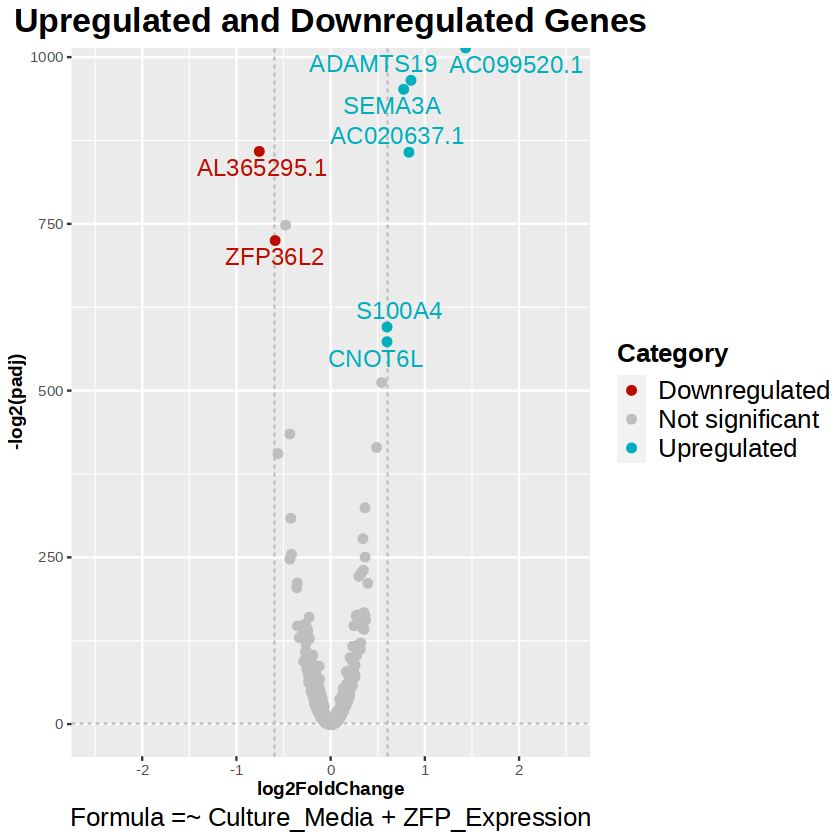

In [8]:
# Volcano plot
# Define significant genes based on the value of padj and log2FoldChange
res1_df$Category <- ifelse(res1_df$padj < 0.05 & abs(res1_df$log2FoldChange) > log2(1.5),
                            ifelse(res1_df$log2FoldChange > 0, "Upregulated", "Downregulated"),
                            "Not significant")

# Filter out rows with missing values
res1_df <- na.omit(res1_df)

# Customize the plot
custom_theme <- theme(
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold"),
    legend.text = element_text(size = 15),
    legend.title = element_text(size = 15, face = "bold"),
    axis.title.x = element_text(face="bold"),
    axis.title.y = element_text(face="bold"),
    plot.caption = element_text(hjust = 0.5, size = 15)
)

# Your existing ggplot code with modifications for theme settings
ggplot(data = res1_df, aes(x = log2FoldChange, y = -log2(padj), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.05), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-2.5, 2.5)) +
  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_1,
            aes(label = rownames(top_upregulated_genes_1)), 
            nudge_y = 0.3, color = "#00AFBB", size = 5) +
  
  geom_text_repel(data = top_downregulated_genes_1,
            aes(label = rownames(top_downregulated_genes_1)), 
            nudge_y = -0.3, color = "#bb0c00", size = 5) +

 labs(title = stringr::str_wrap("Significant Upregulated and Downregulated Genes", width = 50), 
      caption = stringr::str_wrap("Formula =~ Culture_Media + ZFP_Expression", width = 50)) +

  ggtitle('Upregulated and Downregulated Genes') + 
  custom_theme 

### DESeq2 Results: Metastatic Tumor Site ~ Culture Media + ZFP Expression + ZFP Expression: Culture Media

In [10]:
# Load the DESeqResults object
dds_1 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new_copy/deseq/deseq.022124/metastatic_zfpexp_cmint_dds.rds")
resultsNames(dds_1)

res_1 <- results(dds_1)
                                          
res1_df <- as.data.frame(res_1)

[1] "Intercept"                             
[2] "Culture_Media_HISC_vs_BASE"            
[3] "Culture_MediaBASE.ZFP_ExpressionZFP_KD"
[4] "Culture_MediaHISC.ZFP_ExpressionZFP_KD"

In [11]:
# Define significant genes based on the value of padj and log2FoldChange
res1_df$Significant = res1_df$padj < 0.05 & abs(res1_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_1 = res1_df[res1_df$Significant, ]
significant_genes_df_1 <- significant_genes_df_1[complete.cases(significant_genes_df_1$padj), ]
significant_genes_df_1 <- na.omit(significant_genes_df_1)
significant_genes_df_1

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC020637.1,1.410289,1.2830302,0.03294562,38.94388,0.000000e+00,0.000000e+00,TRUE
AC099520.1,2.100114,1.5593984,0.03818920,40.83349,0.000000e+00,0.000000e+00,TRUE
AC108734.4,1.187900,-0.8457293,0.03267437,-25.88357,1.019769e-147,1.993988e-144,TRUE
ADAMTS19,1.578611,0.8476989,0.03347136,25.32609,1.648371e-141,2.417336e-138,TRUE
AL592429.2,1.287393,-0.5982545,0.03405079,-17.56947,4.220638e-69,2.132025e-66,TRUE
BMPR1A,2.068938,0.5994419,0.02780441,21.55924,4.336680e-103,3.179871e-100,TRUE
CNOT6L,1.742341,0.7341072,0.03036499,24.17611,3.968934e-129,3.880294e-126,TRUE
EFCAB11,1.331616,-0.7712009,0.03084670,-25.00109,5.949345e-138,6.979772e-135,TRUE
MAGI2,1.312578,-0.6622635,0.03409256,-19.42545,4.702199e-84,3.064789e-81,TRUE


In [12]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted_1 <- significant_genes_df_1[order(significant_genes_df_1$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes_1 <- head(significant_genes_sorted_1, 5)
top_upregulated_genes_1

# Top 10 downregulated genes
top_downregulated_genes_1 <- tail(significant_genes_sorted_1, 5)
top_downregulated_genes_1

# cat("Top 10 Upregulated Genes:\n")
# print(row.names(head(significant_genes_sorted_1, 10)))

# cat("\nTop 10 Downregulated Genes:\n")
# print(row.names(tail(significant_genes_sorted_1, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC099520.1,2.100114,1.5593984,0.03818920,40.83349,0.000000e+00,0.000000e+00,TRUE
AC020637.1,1.410289,1.2830302,0.03294562,38.94388,0.000000e+00,0.000000e+00,TRUE
ADAMTS19,1.578611,0.8476989,0.03347136,25.32609,1.648371e-141,2.417336e-138,TRUE
CNOT6L,1.742341,0.7341072,0.03036499,24.17611,3.968934e-129,3.880294e-126,TRUE
SEMA3A,1.821298,0.7032937,0.02937809,23.93939,1.191665e-126,9.986151e-124,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
BMPR1A,2.068938,0.5994419,0.02780441,21.55924,4.336680e-103,3.179871e-100,TRUE
AL592429.2,1.287393,-0.5982545,0.03405079,-17.56947,4.220638e-69,2.132025e-66,TRUE
MAGI2,1.312578,-0.6622635,0.03409256,-19.42545,4.702199e-84,3.064789e-81,TRUE
EFCAB11,1.331616,-0.7712009,0.03084670,-25.00109,5.949345e-138,6.979772e-135,TRUE
AC108734.4,1.187900,-0.8457293,0.03267437,-25.88357,1.019769e-147,1.993988e-144,TRUE


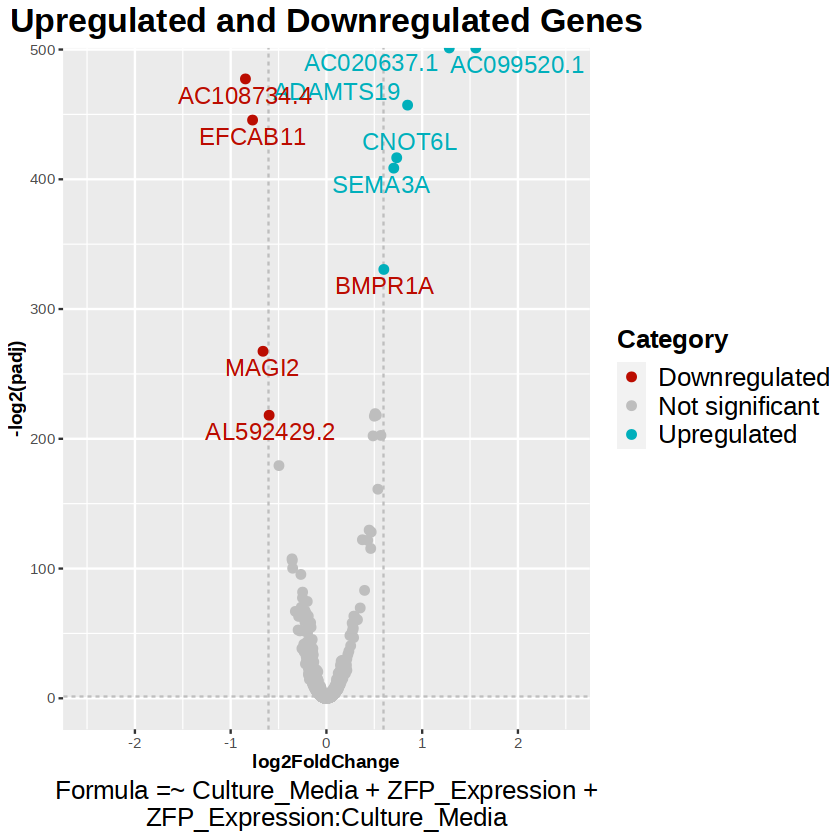

In [13]:
# Volcano plot
# Define significant genes based on the value of padj and log2FoldChange
res1_df$Category <- ifelse(res1_df$padj < 0.05 & abs(res1_df$log2FoldChange) > log2(1.5),
                            ifelse(res1_df$log2FoldChange > 0, "Upregulated", "Downregulated"),
                            "Not significant")

# Filter out rows with missing values
res1_df <- na.omit(res1_df)

# Customize the plot
custom_theme <- theme(
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold"),
    legend.text = element_text(size = 15),
    legend.title = element_text(size = 15, face = "bold"),
    axis.title.x = element_text(face="bold"),
    axis.title.y = element_text(face="bold"),
    plot.caption = element_text(hjust = 0.5, size = 15)
)

# Your existing ggplot code with modifications for theme settings
ggplot(data = res1_df, aes(x = log2FoldChange, y = -log2(padj), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.05), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-2.5, 2.5)) +
  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_1,
            aes(label = rownames(top_upregulated_genes_1)), 
            nudge_y = 0.3, color = "#00AFBB", size = 5) +
  
  geom_text_repel(data = top_downregulated_genes_1,
            aes(label = rownames(top_downregulated_genes_1)), 
            nudge_y = -0.3, color = "#bb0c00", size = 5) +

 labs(title = stringr::str_wrap("Significant Upregulated and Downregulated Genes", width = 50), 
      caption = stringr::str_wrap("Formula =~ Culture_Media + ZFP_Expression + ZFP_Expression:Culture_Media", width = 50)) +

  ggtitle('Upregulated and Downregulated Genes') + 
  custom_theme 

### MAST Results

In [2]:
mast_results = read.csv('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/mast/mast.022024/mast_results1.csv')

In [4]:
mast_results

X,datatable.primerid,datatable.component,datatable.contrast,datatable.ci.hi,datatable.ci.lo,datatable.coef,datatable.z
<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,p00008,C,(Intercept),NA,NA,NA,NA
2,p00008,D,(Intercept),NA,NA,NA,NA
3,p00011,C,(Intercept),NA,NA,NA,NA
4,p00017,C,(Intercept),NA,NA,NA,NA
5,p00082,C,(Intercept),NA,NA,NA,NA
6,p00096,C,(Intercept),NA,NA,NA,NA
7,p00109,C,(Intercept),NA,NA,NA,NA
8,p00116,C,(Intercept),NA,NA,NA,NA
9,p00126,C,(Intercept),NA,NA,NA,NA


### Likelihood Ratio Test: Culture Media Interaction Term

In [7]:
# Load the DESeqResults object
dds_1 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/deseq/deseq.020524/metacell_zfpexp_cmint_lrt_dds.rds")
resultsNames(dds_1)

res_1 <- results(dds_1)
                                          
res1_df <- as.data.frame(res_1)

[1] "Intercept"                                        
[2] "Tumor_Site_Metastatic_vs_Primary"                 
[3] "Culture_Media_Dedifferentiated_vs_BASE"           
[4] "Culture_Media_HISC_vs_BASE"                       
[5] "ZFP_Expression_ZFPKD_vs_CTRL"                     
[6] "Culture_MediaDedifferentiated.ZFP_ExpressionZFPKD"
[7] "Culture_MediaHISC.ZFP_ExpressionZFPKD"

In [8]:
# Define significant genes based on the value of padj and log2FoldChange
res1_df$Significant = res1_df$padj < 0.05 & abs(res1_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_1 = res1_df[res1_df$Significant, ]
significant_genes_df_1 <- significant_genes_df_1[complete.cases(significant_genes_df_1$padj), ]
significant_genes_df_1 <- na.omit(significant_genes_df_1)
significant_genes_df_1

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC004593.1,1.236407,-0.6039408,0.11078748,47.54695,4.734912e-11,1.139073e-08,TRUE
AC009313.1,1.270415,0.9714489,0.11437241,105.03809,1.553344e-23,1.204101e-20,TRUE
AC019117.1,1.438571,-0.7886283,0.11252000,74.34268,7.189410e-17,3.715327e-14,TRUE
AC020637.1,1.396925,0.6668025,0.11608679,71.68786,2.711313e-16,1.351106e-13,TRUE
AC090001.1,1.195742,0.6779935,0.11612614,45.25522,1.489199e-10,3.246687e-08,TRUE
AC108734.4,1.216006,-1.0884791,0.11198564,127.44101,2.120974e-28,2.466163e-25,TRUE
AL031599.1,1.197345,1.0530895,0.11391439,106.37826,7.947919e-24,6.523371e-21,TRUE
AL160272.1,1.292137,-0.7504014,0.11591887,77.82211,1.262246e-17,7.044846e-15,TRUE
AL592429.2,1.550743,-1.4157581,0.11136719,183.77991,1.237942e-40,3.454600e-37,TRUE


In [13]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted_1 <- significant_genes_df_1[order(significant_genes_df_1$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes_1 <- head(significant_genes_sorted_1, 10)
top_upregulated_genes_1

# Top 10 downregulated genes
top_downregulated_genes_1 <- tail(significant_genes_sorted_1, 10)
top_downregulated_genes_1

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted_1, 10)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted_1, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
CADM2,1.402450,1.1756252,0.11327861,204.76000,3.442953e-45,1.200988e-41,TRUE
AL031599.1,1.197345,1.0530895,0.11391439,106.37826,7.947919e-24,6.523371e-21,TRUE
HTO-1,4.128692,1.0330305,0.06311734,428.57149,8.647366e-94,6.032835e-90,TRUE
LINC02410,1.202809,0.9783171,0.11619856,76.85656,2.045548e-17,1.097751e-14,TRUE
AC009313.1,1.270415,0.9714489,0.11437241,105.03809,1.553344e-23,1.204101e-20,TRUE
ROBO2,2.358824,0.9545188,0.11933165,70.24213,5.586172e-16,2.514318e-13,TRUE
MT1G,2.368780,0.8869218,0.08343015,145.25065,2.878864e-32,5.021099e-29,TRUE
MT1H,1.362552,0.7792417,0.10743881,54.95061,1.168492e-12,3.544341e-10,TRUE
CA9,1.472995,0.6849957,0.11603309,41.85237,8.163459e-10,1.389082e-07,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC004593.1,1.236407,-0.6039408,0.11078748,47.54695,4.734912e-11,1.139073e-08,TRUE
SKAP1,2.215377,-0.6441420,0.09710294,46.60200,7.594593e-11,1.778641e-08,TRUE
LINC01625,1.185332,-0.7442914,0.11724277,42.50477,5.891233e-10,1.081584e-07,TRUE
AL160272.1,1.292137,-0.7504014,0.11591887,77.82211,1.262246e-17,7.044846e-15,TRUE
AC019117.1,1.438571,-0.7886283,0.11252000,74.34268,7.189410e-17,3.715327e-14,TRUE
LINC02458,1.261061,-0.9596019,0.11142809,89.84524,3.092813e-20,2.157701e-17,TRUE
AC108734.4,1.216006,-1.0884791,0.11198564,127.44101,2.120974e-28,2.466163e-25,TRUE
HTO-2,4.744236,-1.3393436,0.06161318,776.54162,2.377548e-169,3.317393e-165,TRUE
MAGI2,1.620185,-1.3529039,0.10925628,172.71745,3.125239e-38,7.267743e-35,TRUE


Top 10 Upregulated Genes:
 [1] "CADM2"      "AL031599.1" "HTO-1"      "LINC02410"  "AC009313.1"
 [6] "ROBO2"      "MT1G"       "MT1H"       "CA9"        "MT2A"      

Top 10 Downregulated Genes:
 [1] "AC004593.1" "SKAP1"      "LINC01625"  "AL160272.1" "AC019117.1"
 [6] "LINC02458"  "AC108734.4" "HTO-2"      "MAGI2"      "AL592429.2"


In [11]:
significant_genes_sorted_1

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
CADM2,1.402450,1.1756252,0.11327861,204.76000,3.442953e-45,1.200988e-41,TRUE
AL031599.1,1.197345,1.0530895,0.11391439,106.37826,7.947919e-24,6.523371e-21,TRUE
HTO-1,4.128692,1.0330305,0.06311734,428.57149,8.647366e-94,6.032835e-90,TRUE
LINC02410,1.202809,0.9783171,0.11619856,76.85656,2.045548e-17,1.097751e-14,TRUE
AC009313.1,1.270415,0.9714489,0.11437241,105.03809,1.553344e-23,1.204101e-20,TRUE
ROBO2,2.358824,0.9545188,0.11933165,70.24213,5.586172e-16,2.514318e-13,TRUE
MT1G,2.368780,0.8869218,0.08343015,145.25065,2.878864e-32,5.021099e-29,TRUE
MT1H,1.362552,0.7792417,0.10743881,54.95061,1.168492e-12,3.544341e-10,TRUE
CA9,1.472995,0.6849957,0.11603309,41.85237,8.163459e-10,1.389082e-07,TRUE


# Analyse DESeq2 Results

## DESeq2 Results for Metacell Data

### design = ~ Tumor_Site + Culture_Media + Patient + ZFP_Expression

In [2]:
# Load the DESeqResults object
dds_1 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/metacell_zfpexp_dds.rds")
resultsNames(dds_1)

res_1 <- results(dds_1, contrast = c("ZFP_Expression", "ZFPKD", "CTRL"))
                                          
res1_df <- as.data.frame(res_1)

[1] "Intercept"                             
[2] "Tumor_Site_Metastatic_vs_Primary"      
[3] "Culture_Media_Dedifferentiated_vs_BASE"
[4] "Culture_Media_HISC_vs_BASE"            
[5] "Patient_146_vs_125"                    
[6] "ZFP_Expression_ZFPKD_vs_CTRL"

In [5]:
res1 <- results(dds_1, contrast = c("ZFP_Expression", "ZFPKD", "CTRL"))
# LRT
ddsLRT <- DESeq(dds_1, test="LRT", reduced = ~1)
resLRT <- results(ddsLRT)

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing



In [3]:
# Define significant genes based on the value of padj and log2FoldChange
res1_df$Significant = res1_df$padj < 0.05 & abs(res1_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_1 = res1_df[res1_df$Significant, ]
significant_genes_df_1 <- significant_genes_df_1[complete.cases(significant_genes_df_1$padj), ]
significant_genes_df_1 <- na.omit(significant_genes_df_1)
significant_genes_df_1

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
BEX5,1.642277,0.6318367,0.04117975,15.34339,3.921982e-53,8.206748e-50,TRUE
CADM2,1.292247,-0.6498484,0.04081047,-15.92357,4.348262e-57,1.039856e-53,TRUE
DANT2,1.661956,0.6096773,0.04071519,14.97420,1.082668e-50,1.766700e-47,TRUE
H19,3.056642,0.7433508,0.03075106,24.17317,4.261245e-129,7.133323e-125,TRUE
MEIOB,1.332425,-0.7992596,0.04001156,-19.97572,8.958776e-89,4.998997e-85,TRUE
MIR548XHG,1.827617,0.8212334,0.04019977,20.42881,9.274211e-93,7.762515e-89,TRUE


In [4]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted_1 <- significant_genes_df_1[order(significant_genes_df_1$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes_1 <- head(significant_genes_sorted_1, 4)
top_upregulated_genes_1

# Top 10 downregulated genes
top_downregulated_genes_1 <- tail(significant_genes_sorted_1, 2)
top_downregulated_genes_1

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted_1, 4)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted_1, 2)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
MIR548XHG,1.827617,0.8212334,0.04019977,20.42881,9.274211e-93,7.762515e-89,TRUE
H19,3.056642,0.7433508,0.03075106,24.17317,4.261245e-129,7.133323e-125,TRUE
BEX5,1.642277,0.6318367,0.04117975,15.34339,3.921982e-53,8.206748e-50,TRUE
DANT2,1.661956,0.6096773,0.04071519,14.97420,1.082668e-50,1.766700e-47,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
CADM2,1.292247,-0.6498484,0.04081047,-15.92357,4.348262e-57,1.039856e-53,TRUE
MEIOB,1.332425,-0.7992596,0.04001156,-19.97572,8.958776e-89,4.998997e-85,TRUE


Top 10 Upregulated Genes:
[1] "MIR548XHG" "H19"       "BEX5"      "DANT2"    

Top 10 Downregulated Genes:
[1] "CADM2" "MEIOB"


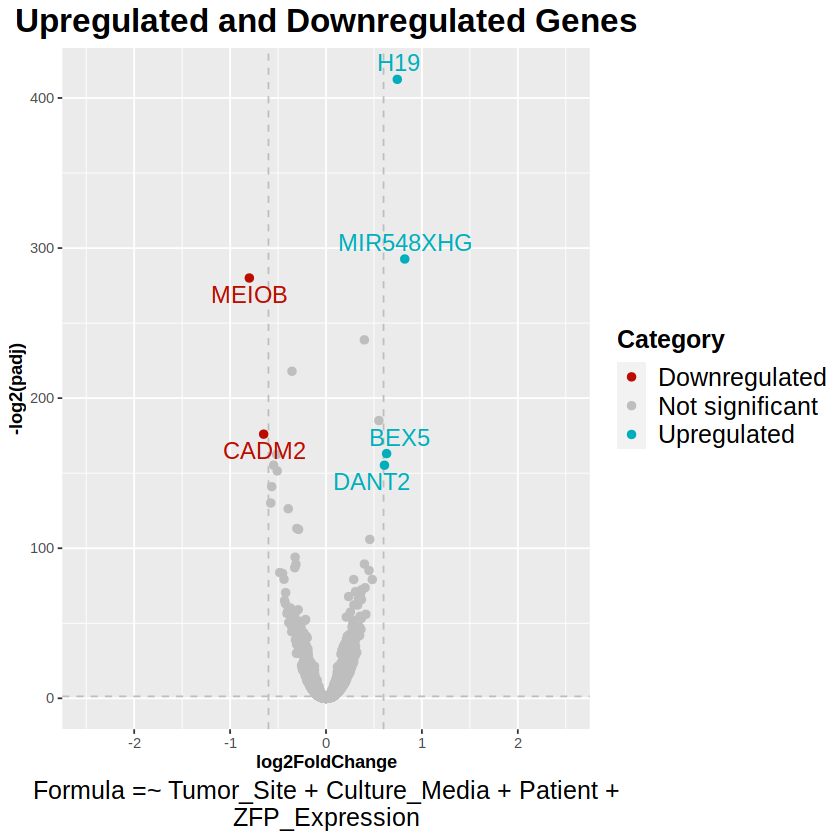

In [5]:
# Volcano plot
# Define significant genes based on the value of padj and log2FoldChange
res1_df$Category <- ifelse(res1_df$padj < 0.05 & abs(res1_df$log2FoldChange) > log2(1.5),
                            ifelse(res1_df$log2FoldChange > 0, "Upregulated", "Downregulated"),
                            "Not significant")

# Filter out rows with missing values
res1_df <- na.omit(res1_df)

# Customize the plot
custom_theme <- theme(
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold"),
    legend.text = element_text(size = 15),
    legend.title = element_text(size = 15, face = "bold"),
    axis.title.x = element_text(face="bold"),
    axis.title.y = element_text(face="bold"),
    plot.caption = element_text(hjust = 0.5, size = 15)
)

# Your existing ggplot code with modifications for theme settings
ggplot(data = res1_df, aes(x = log2FoldChange, y = -log2(padj), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.05), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-2.5, 2.5)) +
  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_1,
            aes(label = rownames(top_upregulated_genes_1)), 
            nudge_y = 0.3, color = "#00AFBB", size = 5) +
  
  geom_text_repel(data = top_downregulated_genes_1,
            aes(label = rownames(top_downregulated_genes_1)), 
            nudge_y = -0.3, color = "#bb0c00", size = 5) +

 labs(title = stringr::str_wrap("Significant Upregulated and Downregulated Genes", width = 50), 
      caption = stringr::str_wrap("Formula =~ Tumor_Site + Culture_Media + Patient + ZFP_Expression", width = 50)) +

  ggtitle('Upregulated and Downregulated Genes') + 
  custom_theme 


In [6]:
res1_df['ZFP36L2',]
res1_df['ZFPL1',]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant,Category
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>
ZFP36L2,4.499369,-0.2858151,0.02230201,-12.81566,1.339848e-37,1.319356e-34,FALSE,Not significant


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant,Category
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>
ZFPL1,2.44339,0.0570647,0.03122557,1.827499,0.06762478,0.2920637,FALSE,Not significant


In [17]:
zfp_genes_res1 <- res1_df[grep("^ZFP", rownames(res1_df)), ]
zfp_genes_res1

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant,Category
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>
ZFP1,1.698695,-0.026230568,0.03713526,-0.7063521,4.799692e-01,8.110109e-01,FALSE,Not significant
ZFP14,2.433705,-0.022560657,0.03105544,-0.7264640,4.675544e-01,8.024257e-01,FALSE,Not significant
ZFP2,1.212183,-0.017440245,0.04399237,-0.3964379,6.917820e-01,9.176252e-01,FALSE,Not significant
ZFP28,1.288198,0.045992942,0.04297955,1.0701122,2.845688e-01,6.493581e-01,FALSE,Not significant
ZFP3,1.335396,0.011089594,0.04205276,0.2637067,7.920060e-01,9.527725e-01,FALSE,Not significant
ZFP30,2.609734,-0.028926482,0.03000114,-0.9641793,3.349560e-01,6.973217e-01,FALSE,Not significant
ZFP36,3.435043,0.029490393,0.02627174,1.1225138,2.616441e-01,6.257795e-01,FALSE,Not significant
ZFP36L1,4.644191,0.015763771,0.02254544,0.6991999,4.844271e-01,8.143847e-01,FALSE,Not significant
ZFP36L2,4.499369,-0.285815108,0.02230201,-12.8156650,1.339848e-37,1.319356e-34,FALSE,Not significant


### design = ~ Tumor_Site + Culture_Media + Patient + ZFP_Expression + ZFP_Expression:Culture_Media

In [22]:
# Load the DESeqResults object
dds_2 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/metacells_zfpexp_intcm_dds.rds")
resultsNames(dds_2)

res_2 <- results(dds_2, contrast = list(c("Culture_MediaDedifferentiated.ZFP_ExpressionZFPKD")))
                                          
res2_df <- as.data.frame(res_2)

[1] "Intercept"                                        
[2] "Tumor_Site_Metastatic_vs_Primary"                 
[3] "Culture_Media_Dedifferentiated_vs_BASE"           
[4] "Culture_Media_HISC_vs_BASE"                       
[5] "Patient_146_vs_125"                               
[6] "ZFP_Expression_ZFPKD_vs_CTRL"                     
[7] "Culture_MediaDedifferentiated.ZFP_ExpressionZFPKD"
[8] "Culture_MediaHISC.ZFP_ExpressionZFPKD"

In [23]:
res2_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,1.022308,-0.033269659,0.16413736,-0.202694004,8.393742e-01,NA
A1BG-AS1,1.012357,0.021156468,0.16598369,0.127461127,8.985754e-01,NA
A1CF,3.334970,-0.134924195,0.08719973,-1.547300656,1.217908e-01,0.984975073
A2M,1.024631,0.002514041,0.16445189,0.015287396,9.878029e-01,NA
A2M-AS1,1.025633,-0.061297014,0.16267810,-0.376799408,7.063227e-01,NA
A2ML1,1.025378,-0.043178944,0.16363009,-0.263881439,7.918713e-01,NA
A2ML1-AS1,1.044034,0.005871876,0.16354411,0.035903928,9.713590e-01,0.999840999
A2ML1-AS2,1.005449,-0.001268347,0.16629529,-0.007627075,9.939145e-01,NA
A3GALT2,1.024126,0.027366254,0.16515969,0.165695715,8.683964e-01,NA


In [24]:
# Define significant genes based on the value of padj and log2FoldChange
res2_df$Significant = res2_df$padj < 0.05 & abs(res2_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_2 = res2_df[res2_df$Significant, ]
significant_genes_df_2 <- significant_genes_df_2[complete.cases(significant_genes_df_2$padj), ]
significant_genes_df_2 <- na.omit(significant_genes_df_2)
significant_genes_df_2

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC008591.1,1.541690,0.8409832,0.13187145,6.377296,1.802424e-10,1.119770e-07,TRUE
AC009313.1,1.230388,-1.1338708,0.12297758,-9.220143,2.967046e-20,9.523722e-17,TRUE
AC018816.1,1.486444,-0.9371251,0.11939701,-7.848815,4.199850e-15,5.055306e-12,TRUE
AC019117.1,1.311816,0.7594985,0.15035366,5.051413,4.385526e-07,1.299398e-04,TRUE
AC019117.2,1.152425,0.6310184,0.15530588,4.063068,4.843184e-05,6.522719e-03,TRUE
AC090001.1,1.171084,-0.7532274,0.13186974,-5.711905,1.117188e-08,4.577855e-06,TRUE
AC093817.2,2.598659,-0.5870257,0.09950925,-5.899208,3.652515e-09,1.715702e-06,TRUE
AC099520.1,3.522513,1.5413879,0.12812797,12.030066,2.469627e-33,2.378127e-29,TRUE
ACOXL,1.345106,1.0086018,0.14814890,6.808028,9.894564e-12,7.622376e-09,TRUE


In [25]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted_2 <- significant_genes_df_2[order(significant_genes_df_2$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes_2 <- head(significant_genes_sorted_2, 10)
top_upregulated_genes_2

# Top 10 downregulated genes
top_downregulated_genes_2 <- tail(significant_genes_sorted_2, 10)
top_downregulated_genes_2

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted_2, 10)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted_2, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC099520.1,3.522513,1.5413879,0.1281280,12.030066,2.469627e-33,2.378127e-29,TRUE
WFDC2,2.453352,1.4268300,0.1332805,10.705463,9.594962e-27,6.159646e-23,TRUE
TFPI,2.389456,1.3205081,0.1339465,9.858475,6.299873e-23,3.033231e-19,TRUE
ACOXL,1.345106,1.0086018,0.1481489,6.808028,9.894564e-12,7.622376e-09,TRUE
ADAMTS19,2.659503,1.0054177,0.1094880,9.182901,4.196311e-20,1.012282e-16,TRUE
IL32,2.264867,0.8928616,0.1179653,7.568849,3.765458e-14,3.296316e-11,TRUE
CCL26,1.812990,0.8885586,0.1437970,6.179257,6.440412e-10,3.648115e-07,TRUE
LTB,1.291466,0.8819725,0.1432399,6.157308,7.399177e-10,3.958354e-07,TRUE
AC008591.1,1.541690,0.8409832,0.1318714,6.377296,1.802424e-10,1.119770e-07,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
SOX5,1.826371,-0.9429940,0.1077903,-8.748410,2.163792e-18,3.788406e-15,TRUE
GPRIN3,2.660011,-0.9600956,0.1062944,-9.032419,1.679188e-19,3.593276e-16,TRUE
TRPV5,1.090040,-1.0643628,0.1347923,-7.896319,2.872620e-15,3.688253e-12,TRUE
CADM2-AS1,1.066567,-1.0738336,0.1375782,-7.805262,5.937799e-15,5.717803e-12,TRUE
CADM2-AS2,1.068382,-1.0845059,0.1370671,-7.912226,2.528268e-15,3.477994e-12,TRUE
TTC29,1.156143,-1.0855046,0.1388866,-7.815764,5.463070e-15,5.717803e-12,TRUE
PDZD7,1.247210,-1.1141359,0.1253786,-8.886174,6.324941e-19,1.218120e-15,TRUE
AC009313.1,1.230388,-1.1338708,0.1229776,-9.220143,2.967046e-20,9.523722e-17,TRUE
KEL,1.145003,-1.2502565,0.1289423,-9.696249,3.127862e-22,1.204790e-18,TRUE


Top 10 Upregulated Genes:
 [1] "AC099520.1" "WFDC2"      "TFPI"       "ACOXL"      "ADAMTS19"  
 [6] "IL32"       "CCL26"      "LTB"        "AC008591.1" "CXCR4"     

Top 10 Downregulated Genes:
 [1] "SOX5"       "GPRIN3"     "TRPV5"      "CADM2-AS1"  "CADM2-AS2" 
 [6] "TTC29"      "PDZD7"      "AC009313.1" "KEL"        "CADM2"     


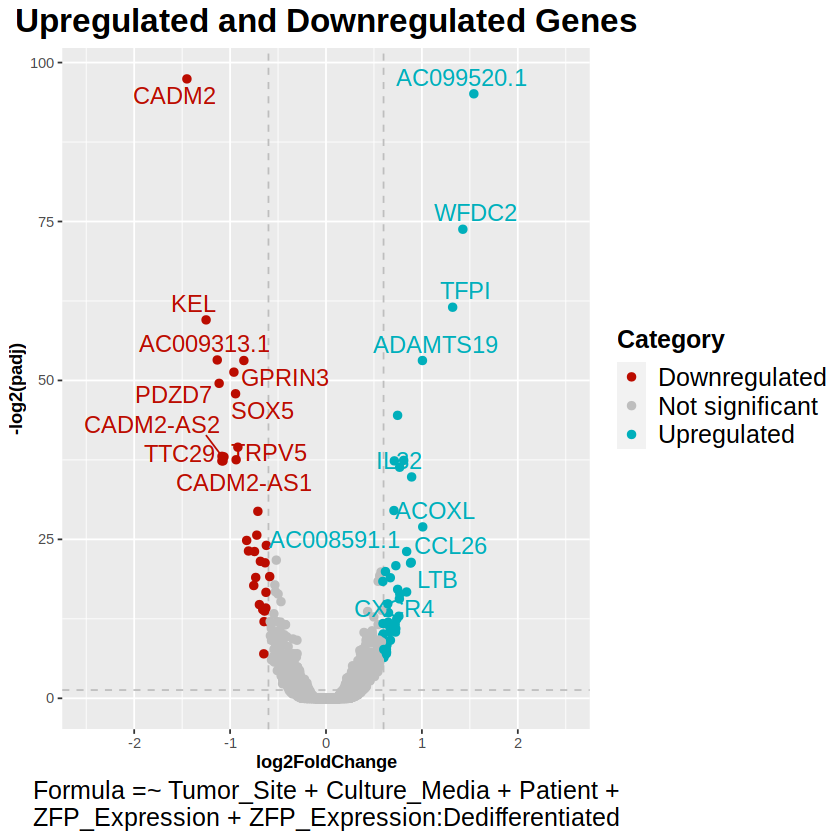

In [27]:
# Volcano plot
# Define significant genes based on the value of padj and log2FoldChange
res2_df$Category <- ifelse(res2_df$padj < 0.05 & abs(res2_df$log2FoldChange) > log2(1.5),
                            ifelse(res2_df$log2FoldChange > 0, "Upregulated", "Downregulated"),
                            "Not significant")

# Filter out rows with missing values
res2_df <- na.omit(res2_df)

# Customize the plot
custom_theme <- theme(
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold"),
    legend.text = element_text(size = 15),
    legend.title = element_text(size = 15, face = "bold"),
    axis.title.x = element_text(face="bold"),
    axis.title.y = element_text(face="bold"),
    plot.caption = element_text(hjust = 0.5, size = 15)
)

ggplot(data = res2_df, aes(x = log2FoldChange, y = -log2(padj), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.05), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-2.5, 2.5)) +
  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_2,
            aes(label = rownames(top_upregulated_genes_2)), 
            nudge_y = 0.3, color = "#00AFBB", size = 5) +
  
  geom_text_repel(data = top_downregulated_genes_2,
            aes(label = rownames(top_downregulated_genes_2)), 
            nudge_y = -0.3, color = "#bb0c00", size = 5) +

  labs(title = stringr::str_wrap("Significant Upregulated and Downregulated Genes", width = 50), 
      caption = stringr::str_wrap("Formula =~ Tumor_Site + Culture_Media + Patient + ZFP_Expression + ZFP_Expression:Dedifferentiated", width = 50)) +

  ggtitle('Upregulated and Downregulated Genes') + 
  custom_theme 


In [58]:
# Load the DESeqResults object
dds_2 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/metacells_zfpexp_intcm_dds.rds")
resultsNames(dds_2)

res_2 <- results(dds_2, contrast = list(c("Culture_MediaHISC.ZFP_ExpressionZFPKD")))
                                          
res2_df <- as.data.frame(res_2)

[1] "Intercept"                                        
[2] "Tumor_Site_Metastatic_vs_Primary"                 
[3] "Culture_Media_Dedifferentiated_vs_BASE"           
[4] "Culture_Media_HISC_vs_BASE"                       
[5] "Patient_146_vs_125"                               
[6] "ZFP_Expression_ZFPKD_vs_CTRL"                     
[7] "Culture_MediaDedifferentiated.ZFP_ExpressionZFPKD"
[8] "Culture_MediaHISC.ZFP_ExpressionZFPKD"

In [59]:
# Define significant genes based on the value of padj and log2FoldChange
res2_df$Significant = res2_df$padj < 0.05 & abs(res2_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_2 = res2_df[res2_df$Significant, ]
significant_genes_df_2 <- significant_genes_df_2[complete.cases(significant_genes_df_2$padj), ]
significant_genes_df_2 <- na.omit(significant_genes_df_2)
significant_genes_df_2

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC009313.1,1.230388,0.6607944,0.09362939,7.057553,1.694597e-12,4.052508e-09,TRUE
BEX5,1.642277,0.9312245,0.09043083,10.297644,7.220776e-25,1.208758e-20,TRUE
CADM2,1.292247,0.7477269,0.09275099,8.061659,7.526604e-16,6.299768e-12,TRUE
LINC02410,1.164393,0.7058693,0.09505730,7.425725,1.121641e-13,6.258755e-10,TRUE


In [60]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted_2 <- significant_genes_df_2[order(significant_genes_df_2$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes_2 <- head(significant_genes_sorted_2, 2)
top_upregulated_genes_2

# Top 10 downregulated genes
top_downregulated_genes_2 <- tail(significant_genes_sorted_2, 2)
top_downregulated_genes_2

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted_2, 2)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted_2, 2)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
BEX5,1.642277,0.9312245,0.09043083,10.297644,7.220776e-25,1.208758e-20,TRUE
CADM2,1.292247,0.7477269,0.09275099,8.061659,7.526604e-16,6.299768e-12,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
LINC02410,1.164393,0.7058693,0.09505730,7.425725,1.121641e-13,6.258755e-10,TRUE
AC009313.1,1.230388,0.6607944,0.09362939,7.057553,1.694597e-12,4.052508e-09,TRUE


Top 10 Upregulated Genes:
[1] "BEX5"  "CADM2"

Top 10 Downregulated Genes:
[1] "LINC02410"  "AC009313.1"


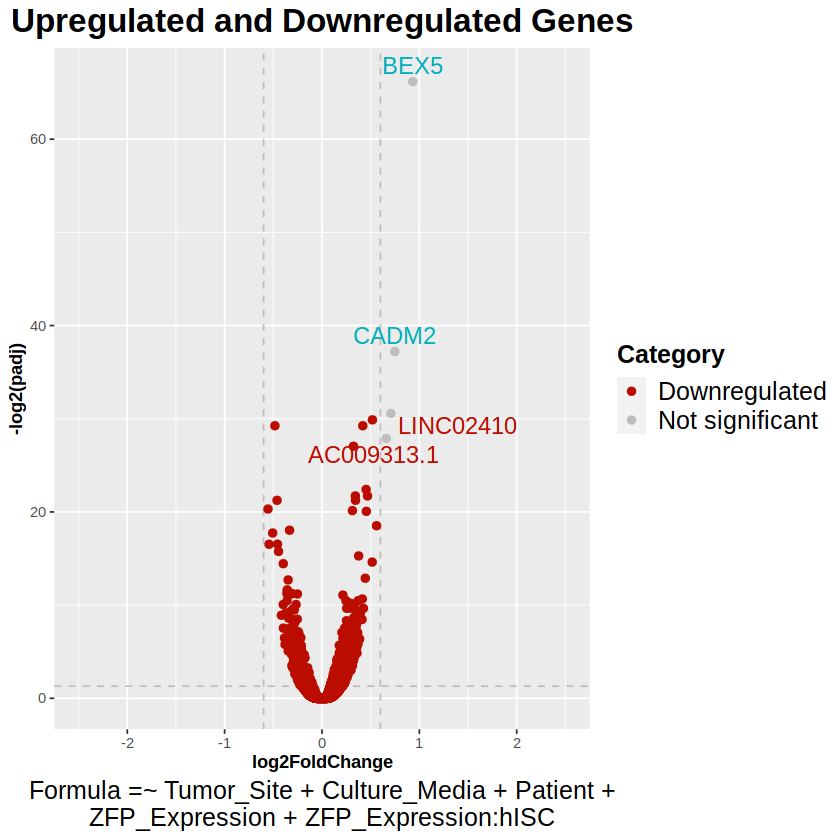

In [61]:
# Volcano plot
# Define significant genes based on the value of padj and log2FoldChange
res2_df$Category <- ifelse(res2_df$padj < 0.05 & abs(res2_df$log2FoldChange) > log2(1.5),
                            ifelse(res2_df$log2FoldChange > 0, "Upregulated", "Downregulated"),
                            "Not significant")

# Filter out rows with missing values
res2_df <- na.omit(res2_df)

# Customize the plot
custom_theme <- theme(
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold"),
    legend.text = element_text(size = 15),
    legend.title = element_text(size = 15, face = "bold"),
    axis.title.x = element_text(face="bold"),
    axis.title.y = element_text(face="bold"),
    plot.caption = element_text(hjust = 0.5, size = 15)
)

ggplot(data = res2_df, aes(x = log2FoldChange, y = -log2(padj), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.05), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-2.5, 2.5)) +
  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_2,
            aes(label = rownames(top_upregulated_genes_2)), 
            nudge_y = 0.3, color = "#00AFBB", size = 5) +
  
  geom_text_repel(data = top_downregulated_genes_2,
            aes(label = rownames(top_downregulated_genes_2)), 
            nudge_y = -0.3, color = "#bb0c00", size = 5) +

  labs(title = stringr::str_wrap("Significant Upregulated and Downregulated Genes", width = 50), 
      caption = stringr::str_wrap("Formula =~ Tumor_Site + Culture_Media + Patient + ZFP_Expression + ZFP_Expression:hISC", width = 50)) +

  ggtitle('Upregulated and Downregulated Genes') + 
  custom_theme 


### Patient 125: design = ~ Culture_Media + ZFP_Expression

In [14]:
# Load the DESeqResults object
dds_3 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/metacell_ptn125_zfpexp_dds.rds")
resultsNames(dds_3)

res_3 <- results(dds_3, contrast = c("ZFP_Expression", "ZFPKD", "CTRL"))
                                          
res3_df <- as.data.frame(res_3)

[1] "Intercept"                    "Culture_Media_HISC_vs_BASE"  
[3] "ZFP_Expression_ZFPKD_vs_CTRL"

In [15]:
# Define significant genes based on the value of padj and log2FoldChange
res3_df$Significant = res3_df$padj < 0.05 & abs(res3_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_3 = res3_df[res3_df$Significant, ]
significant_genes_df_3 <- significant_genes_df_3[complete.cases(significant_genes_df_3$padj), ]
significant_genes_df_3 <- na.omit(significant_genes_df_3)
significant_genes_df_3

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
ABHD12B,1.705084,-0.7836512,0.06419991,-12.206422,2.872446e-34,1.232942e-31,TRUE
AC004009.1,1.644823,0.9218858,0.07774804,11.857351,1.971139e-32,8.249217e-30,TRUE
AC007091.1,1.402249,-1.0230988,0.07093285,-14.423484,3.682730e-47,2.568704e-44,TRUE
AC019330.1,2.809658,-0.9176265,0.05010928,-18.312508,6.577012e-75,9.174932e-72,TRUE
AC024901.1,4.187725,0.5967418,0.04598036,12.978189,1.626808e-38,7.780789e-36,TRUE
AC092894.1,1.546868,-1.0019287,0.06754648,-14.833174,8.940323e-50,6.802773e-47,TRUE
AC105460.1,1.482286,-0.9115637,0.06887297,-13.235435,5.477889e-40,2.778784e-37,TRUE
AC105460.2,1.575386,-0.7914455,0.06679110,-11.849565,2.163097e-32,8.831769e-30,TRUE
AC136431.1,4.035173,0.7290558,0.04805250,15.172067,5.414469e-52,4.531911e-49,TRUE


In [16]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted_3 <- significant_genes_df_3[order(significant_genes_df_3$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes_3 <- head(significant_genes_sorted_3, 10)
top_upregulated_genes_3

# Top 10 downregulated genes
top_downregulated_genes_3 <- tail(significant_genes_sorted_3, 10)
top_downregulated_genes_3

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted_3, 10)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted_3, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
DIAPH2,4.301491,2.3268518,0.06672590,34.87179,1.990443e-266,3.332002e-262,TRUE
DIAPH2-AS1,2.353662,1.6088607,0.07475466,21.52188,9.714399e-103,4.065476e-99,TRUE
BEX5,2.454657,1.5726415,0.07365607,21.35115,3.804891e-101,1.273877e-97,TRUE
IGF2BP1,2.217791,1.5218517,0.07576955,20.08527,9.928738e-90,1.846745e-86,TRUE
MIR548XHG,3.690923,1.4526536,0.05792028,25.08022,8.174718e-139,4.561493e-135,TRUE
IGFBP2,2.099923,1.3492695,0.07546478,17.87946,1.704853e-71,2.038517e-68,TRUE
DANT2,2.834714,1.3088947,0.06400768,20.44902,6.128821e-93,1.465664e-89,TRUE
CNTNAP2,2.717072,1.2451280,0.06459184,19.27686,8.402177e-83,1.278659e-79,TRUE
LHFPL6,2.007560,1.1205087,0.07283008,15.38525,2.055904e-53,1.811360e-50,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC105460.1,1.482286,-0.9115637,0.06887297,-13.23543,5.477889e-40,2.778784e-37,TRUE
AC019330.1,2.809658,-0.9176265,0.05010928,-18.31251,6.577012e-75,9.174932e-72,TRUE
TMEM178B,2.822201,-0.9782399,0.04998575,-19.57038,2.766358e-85,4.630884e-82,TRUE
LINC02124,1.367648,-0.9925052,0.07174596,-13.83360,1.598073e-43,9.908051e-41,TRUE
AC092894.1,1.546868,-1.0019287,0.06754648,-14.83317,8.940323e-50,6.802773e-47,TRUE
AC007091.1,1.402249,-1.0230988,0.07093285,-14.42348,3.682730e-47,2.568704e-44,TRUE
CPNE4,1.836342,-1.0351537,0.06202711,-16.68873,1.583021e-62,1.472210e-59,TRUE
RORA,1.876108,-1.0989525,0.06148071,-17.87475,1.854951e-71,2.070126e-68,TRUE
AGMO,2.084602,-1.2156876,0.05866654,-20.72199,2.194157e-95,6.121697e-92,TRUE


Top 10 Upregulated Genes:
 [1] "DIAPH2"     "DIAPH2-AS1" "BEX5"       "IGF2BP1"    "MIR548XHG" 
 [6] "IGFBP2"     "DANT2"      "CNTNAP2"    "LHFPL6"     "TBC1D9"    

Top 10 Downregulated Genes:
 [1] "AC105460.1" "AC019330.1" "TMEM178B"   "LINC02124"  "AC092894.1"
 [6] "AC007091.1" "CPNE4"      "RORA"       "AGMO"       "MEIOB"     


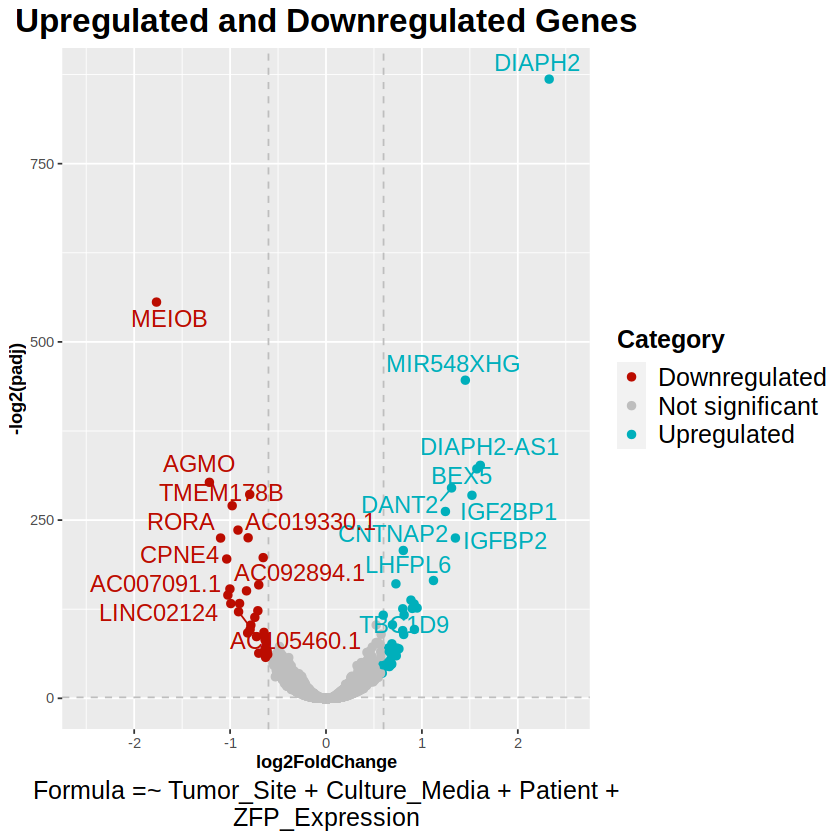

In [18]:
# Volcano plot
# Define significant genes based on the value of padj and log2FoldChange
res3_df$Category <- ifelse(res3_df$padj < 0.05 & abs(res3_df$log2FoldChange) > log2(1.5),
                            ifelse(res3_df$log2FoldChange > 0, "Upregulated", "Downregulated"),
                            "Not significant")

# Filter out rows with missing values
res3_df <- na.omit(res3_df)

# Customize the plot
custom_theme <- theme(
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold"),
    legend.text = element_text(size = 15),
    legend.title = element_text(size = 15, face = "bold"),
    axis.title.x = element_text(face="bold"),
    axis.title.y = element_text(face="bold"),
    plot.caption = element_text(hjust = 0.5, size = 15)
)

# Your existing ggplot code with modifications for theme settings
ggplot(data = res3_df, aes(x = log2FoldChange, y = -log2(padj), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.05), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-2.5, 2.5)) +

  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_3,
            aes(label = rownames(top_upregulated_genes_3)), 
            nudge_y = 0.3, color = "#00AFBB", size = 5) +
  
  geom_text_repel(data = top_downregulated_genes_3,
            aes(label = rownames(top_downregulated_genes_3)), 
            nudge_y = -0.3, color = "#bb0c00", size = 5) +

  labs(title = stringr::str_wrap("Significant Upregulated and Downregulated Genes", width = 50), 
      caption = stringr::str_wrap("Formula =~ Tumor_Site + Culture_Media + Patient + ZFP_Expression", width = 50)) +

  ggtitle('Upregulated and Downregulated Genes') + 
  custom_theme 

### Patient 125: design = ~ Culture_Media + ZFP_Expression + ZFP_Expression:Culture_Media

In [35]:
# Load the DESeqResults object
dds_4 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/metacell_ptn125_zfpexp_cmint_dds.rds")
resultsNames(dds_4)

res_4 <- results(dds_4, contrast = list(c("Culture_MediaHISC.ZFP_ExpressionZFPKD")))
                                          
res4_df <- as.data.frame(res_4)

[1] "Intercept"                            
[2] "Culture_Media_HISC_vs_BASE"           
[3] "ZFP_Expression_ZFPKD_vs_CTRL"         
[4] "Culture_MediaHISC.ZFP_ExpressionZFPKD"

In [37]:
# Define significant genes based on the value of padj and log2FoldChange
res4_df$Significant = res4_df$padj < 0.05 & abs(res4_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_4 = res4_df[res4_df$Significant, ]
significant_genes_df_4 <- significant_genes_df_4[complete.cases(significant_genes_df_4$padj), ]
significant_genes_df_4 <- na.omit(significant_genes_df_4)
significant_genes_df_4

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC007319.1,1.637350,-0.6345318,0.14369403,-4.415853,1.006123e-05,3.353558e-03,TRUE
AC009478.1,1.491505,0.6705203,0.14096485,4.756649,1.968330e-06,9.841103e-04,TRUE
AC010280.1,1.335175,0.7642609,0.15322275,4.987907,6.103682e-07,3.916972e-04,TRUE
AC068413.1,1.693151,-0.6568028,0.14665795,-4.478467,7.518101e-06,2.553175e-03,TRUE
AC103796.1,1.282372,0.6675218,0.15275349,4.369928,1.242873e-05,4.067359e-03,TRUE
AL031722.1,1.174591,0.6957547,0.16106864,4.319616,1.563010e-05,4.768239e-03,TRUE
AL355922.4,1.304952,0.5910292,0.14970847,3.947867,7.885055e-05,1.730770e-02,TRUE
AMIGO2,1.541664,0.5922937,0.14545612,4.071975,4.661617e-05,1.194514e-02,TRUE
ANXA1,2.278821,-0.6614606,0.11636681,-5.684272,1.313711e-08,1.313638e-05,TRUE


In [38]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted_4 <- significant_genes_df_4[order(significant_genes_df_4$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes_4 <- head(significant_genes_sorted_4, 10)
top_upregulated_genes_4

# Top 10 downregulated genes
top_downregulated_genes_4 <- tail(significant_genes_sorted_4, 10)
top_downregulated_genes_4

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted_4, 10)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted_4, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
BEX5,2.454657,1.6704176,0.1649028,10.129709,4.078609e-24,7.341089e-20,TRUE
IGFBP2,2.099923,1.0732585,0.1674265,6.410327,1.452081e-10,3.469604e-07,TRUE
ITGA1,1.684808,0.9335818,0.1469640,6.352452,2.119091e-10,3.814151e-07,TRUE
MYL3,1.859768,0.8953181,0.1282524,6.980908,2.932779e-12,1.319677e-08,TRUE
CYP4X1,2.119956,0.8683874,0.1357667,6.396174,1.593188e-10,3.469604e-07,TRUE
NAV3,1.713328,0.8470561,0.1324461,6.395479,1.600445e-10,3.469604e-07,TRUE
APOA2,1.406948,0.8431316,0.1786073,4.720588,2.351634e-06,1.143975e-03,TRUE
BDNF,1.679923,0.8317761,0.1389110,5.987836,2.126517e-09,3.189598e-06,TRUE
TLR4,1.767347,0.7997375,0.1431420,5.587022,2.309967e-08,2.078855e-05,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
HPGD,3.454293,-0.6623077,0.09213227,-7.188662,6.542946e-13,3.925549e-09,TRUE
VTN,1.196976,-0.6670237,0.16684772,-3.997799,6.393409e-05,1.475320e-02,TRUE
HSPB3,1.231245,-0.6706293,0.16376212,-4.095143,4.219082e-05,1.100569e-02,TRUE
IGFL2,1.507742,-0.7248184,0.14498147,-4.999386,5.751307e-07,3.916972e-04,TRUE
LBH,1.527343,-0.7541659,0.14775233,-5.104257,3.320964e-07,2.490585e-04,TRUE
PLXDC2,1.383700,-0.7604523,0.16144371,-4.710325,2.473223e-06,1.171462e-03,TRUE
LINC02331,2.272954,-0.8484022,0.11632230,-7.293548,3.018982e-13,2.716933e-09,TRUE
CYP26A1,1.499724,-0.8570780,0.15279172,-5.609453,2.029665e-08,1.922734e-05,TRUE
KCNMA1,1.331877,-0.9813996,0.16650573,-5.894089,3.767545e-09,4.843718e-06,TRUE


Top 10 Upregulated Genes:
 [1] "BEX5"       "IGFBP2"     "ITGA1"      "MYL3"       "CYP4X1"    
 [6] "NAV3"       "APOA2"      "BDNF"       "TLR4"       "AC010280.1"

Top 10 Downregulated Genes:
 [1] "HPGD"      "VTN"       "HSPB3"     "IGFL2"     "LBH"       "PLXDC2"   
 [7] "LINC02331" "CYP26A1"   "KCNMA1"    "SLC2A3"   


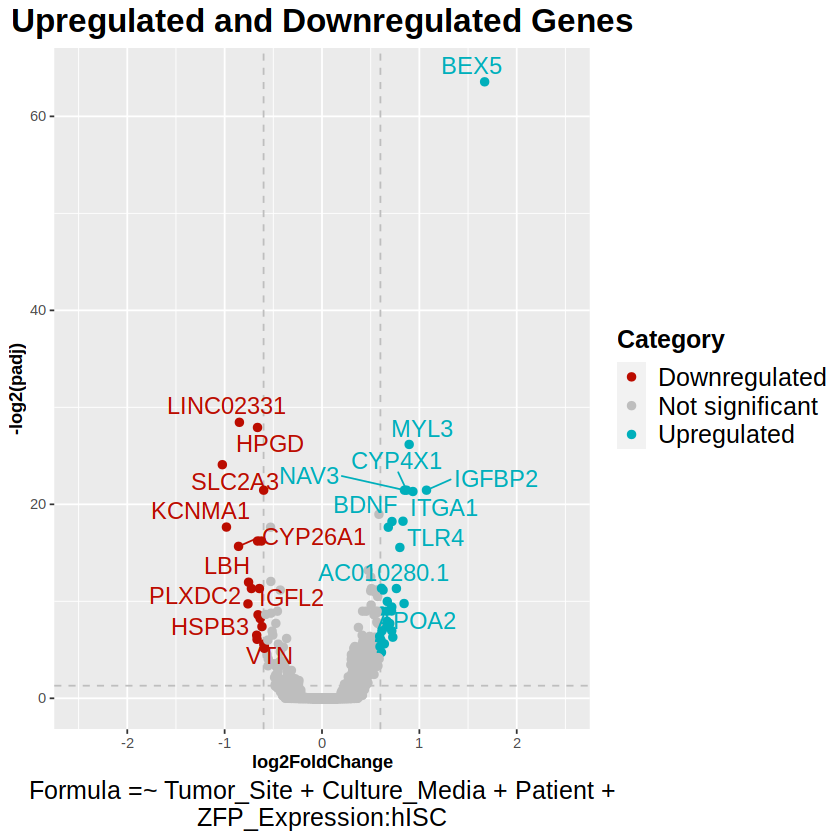

In [40]:
# Volcano plot
# Define significant genes based on the value of padj and log2FoldChange
res4_df$Category <- ifelse(res4_df$padj < 0.05 & abs(res4_df$log2FoldChange) > log2(1.5),
                            ifelse(res4_df$log2FoldChange > 0, "Upregulated", "Downregulated"),
                            "Not significant")

# Filter out rows with missing values
res4_df <- na.omit(res4_df)

# Customize the plot
custom_theme <- theme(
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold"),
    legend.text = element_text(size = 15),
    legend.title = element_text(size = 15, face = "bold"),
    axis.title.x = element_text(face="bold"),
    axis.title.y = element_text(face="bold"),
    plot.caption = element_text(hjust = 0.5, size = 15)
)

# Your existing ggplot code with modifications for theme settings
ggplot(data = res4_df, aes(x = log2FoldChange, y = -log2(padj), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.05), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-2.5, 2.5)) +
  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_4,
            aes(label = rownames(top_upregulated_genes_4)), 
            nudge_y = 0.3, color = "#00AFBB", size = 5) +
  
  geom_text_repel(data = top_downregulated_genes_4,
            aes(label = rownames(top_downregulated_genes_4)), 
            nudge_y = -0.3, color = "#bb0c00", size = 5) +

  labs(title = stringr::str_wrap("Significant Upregulated and Downregulated Genes", width = 50), 
      caption = stringr::str_wrap("Formula =~ Tumor_Site + Culture_Media + Patient + ZFP_Expression:hISC", width = 50)) +

  ggtitle('Upregulated and Downregulated Genes') + 
  custom_theme 

### Patient 146: design = ~ Tumor_Site + Culture_Media + ZFP_Expression

In [29]:
# Load the DESeqResults object
dds_5 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/metacell_ptn146_zfpexp_dds.rds")
resultsNames(dds_5)

res_5 <- results(dds_5, contrast = c("ZFP_Expression", "ZFPKD", "CTRL"))
                                          
res5_df <- as.data.frame(res_5)

[1] "Intercept"                             
[2] "Tumor_Site_Metastatic_vs_Primary"      
[3] "Culture_Media_Dedifferentiated_vs_BASE"
[4] "Culture_Media_HISC_vs_BASE"            
[5] "ZFP_Expression_ZFPKD_vs_CTRL"

In [30]:
# Define significant genes based on the value of padj and log2FoldChange
res5_df$Significant = res5_df$padj < 0.05 & abs(res5_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_5 = res5_df[res5_df$Significant, ]
significant_genes_df_5 <- significant_genes_df_5[complete.cases(significant_genes_df_5$padj), ]
significant_genes_df_5 <- na.omit(significant_genes_df_5)
significant_genes_df_5

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC009313.1,1.304581,-0.7730728,0.04876339,-15.85355,1.328637e-56,5.141827e-53,TRUE
AC099520.1,2.394244,0.6338964,0.04705881,13.47030,2.339110e-41,7.241884e-38,TRUE
ACOXL,1.372911,-0.5920448,0.04777086,-12.39343,2.836455e-35,4.878703e-32,TRUE
CADM2,1.389122,-0.8632239,0.04728521,-18.25568,1.864621e-74,2.886433e-70,TRUE
GPC5,1.480960,-0.7785182,0.04572617,-17.02566,5.299366e-65,2.734473e-61,TRUE
H19,2.489991,0.7134992,0.04091407,17.43897,4.175396e-68,3.231757e-64,TRUE
KEL,1.197610,-0.5878719,0.05116785,-11.48909,1.496833e-30,1.544731e-27,TRUE
LINC02410,1.232106,-0.6594027,0.05031705,-13.10496,3.084413e-39,6.820958e-36,TRUE
SCHLAP1,1.229562,-0.6702773,0.05031724,-13.32103,1.746891e-40,4.506979e-37,TRUE


In [31]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted_5 <- significant_genes_df_5[order(significant_genes_df_5$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes_5 <- head(significant_genes_sorted_5, 2)
top_upregulated_genes_5

# Top 10 downregulated genes
top_downregulated_genes_5 <- tail(significant_genes_sorted_5, 7)
top_downregulated_genes_5

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted_5, 2)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted_5, 7)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
H19,2.489991,0.7134992,0.04091407,17.43897,4.175396e-68,3.231757e-64,TRUE
AC099520.1,2.394244,0.6338964,0.04705881,13.47030,2.339110e-41,7.241884e-38,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
KEL,1.197610,-0.5878719,0.05116785,-11.48909,1.496833e-30,1.544731e-27,TRUE
ACOXL,1.372911,-0.5920448,0.04777086,-12.39343,2.836455e-35,4.878703e-32,TRUE
LINC02410,1.232106,-0.6594027,0.05031705,-13.10496,3.084413e-39,6.820958e-36,TRUE
SCHLAP1,1.229562,-0.6702773,0.05031724,-13.32103,1.746891e-40,4.506979e-37,TRUE
AC009313.1,1.304581,-0.7730728,0.04876339,-15.85355,1.328637e-56,5.141827e-53,TRUE
GPC5,1.480960,-0.7785182,0.04572617,-17.02566,5.299366e-65,2.734473e-61,TRUE
CADM2,1.389122,-0.8632239,0.04728521,-18.25568,1.864621e-74,2.886433e-70,TRUE


Top 10 Upregulated Genes:
[1] "H19"        "AC099520.1"

Top 10 Downregulated Genes:
[1] "KEL"        "ACOXL"      "LINC02410"  "SCHLAP1"    "AC009313.1"
[6] "GPC5"       "CADM2"     


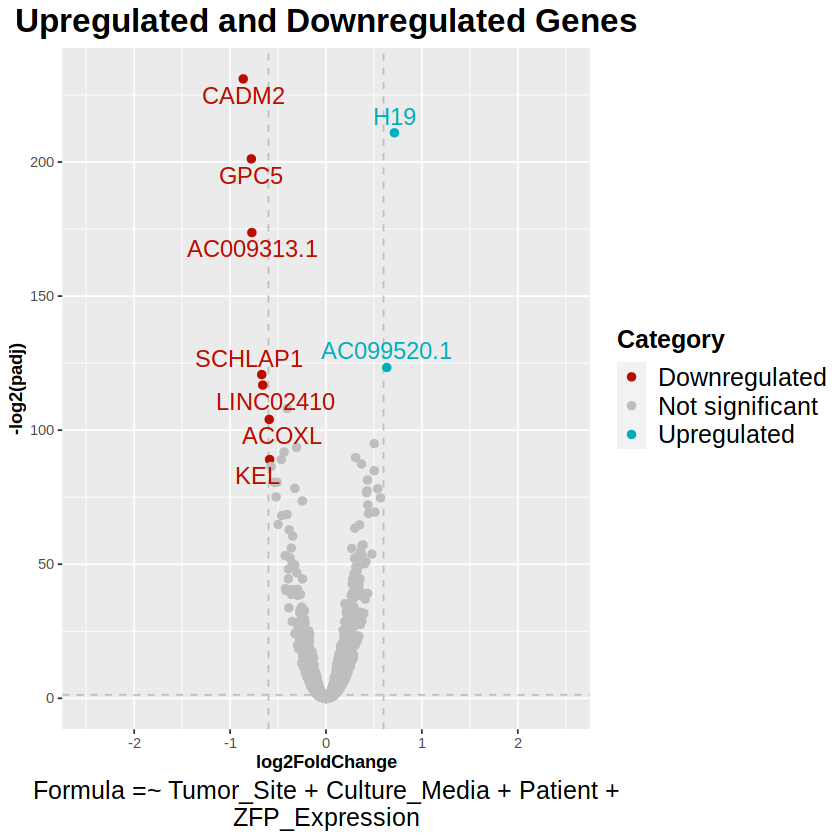

In [32]:
# Volcano plot
# Define significant genes based on the value of padj and log2FoldChange
res5_df$Category <- ifelse(res5_df$padj < 0.05 & abs(res5_df$log2FoldChange) > log2(1.5),
                            ifelse(res5_df$log2FoldChange > 0, "Upregulated", "Downregulated"),
                            "Not significant")

# Filter out rows with missing values
res5_df <- na.omit(res5_df)

# Customize the plot
custom_theme <- theme(
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold"),
    legend.text = element_text(size = 15),
    legend.title = element_text(size = 15, face = "bold"),
    axis.title.x = element_text(face="bold"),
    axis.title.y = element_text(face="bold"),
    plot.caption = element_text(hjust = 0.5, size = 15)
)

# Your existing ggplot code with modifications for theme settings
ggplot(data = res5_df, aes(x = log2FoldChange, y = -log2(padj), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.05), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-2.5, 2.5)) +

  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_5,
            aes(label = rownames(top_upregulated_genes_5)), 
            nudge_y = 0.3, color = "#00AFBB", size = 5) +
  
  geom_text_repel(data = top_downregulated_genes_5,
            aes(label = rownames(top_downregulated_genes_5)), 
            nudge_y = -0.3, color = "#bb0c00", size = 5) +

  labs(title = stringr::str_wrap("Significant Upregulated and Downregulated Genes", width = 50), 
      caption = stringr::str_wrap("Formula =~ Tumor_Site + Culture_Media + Patient + ZFP_Expression", width = 50)) +

  ggtitle('Upregulated and Downregulated Genes') + 
  custom_theme

### Patient 146: design = ~ Tumor_Site + Culture_Media + ZFP_Expression + ZFP_Expression:Culture_Media

In [49]:
# Load the DESeqResults object
dds_6 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/metacell_ptn146_zfpexp_cmint_dds.rds")
resultsNames(dds_6)

res_6 <- results(dds_6, contrast = list(c("Culture_MediaHISC.ZFP_ExpressionZFPKD")))
                                          
res6_df <- as.data.frame(res_6)

[1] "Intercept"                                        
[2] "Tumor_Site_Metastatic_vs_Primary"                 
[3] "Culture_Media_Dedifferentiated_vs_BASE"           
[4] "Culture_Media_HISC_vs_BASE"                       
[5] "ZFP_Expression_ZFPKD_vs_CTRL"                     
[6] "Culture_MediaDedifferentiated.ZFP_ExpressionZFPKD"
[7] "Culture_MediaHISC.ZFP_ExpressionZFPKD"

In [50]:
# Define significant genes based on the value of padj and log2FoldChange
res6_df$Significant = res6_df$padj < 0.05 & abs(res6_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_6 = res6_df[res6_df$Significant, ]
significant_genes_df_6 <- significant_genes_df_6[complete.cases(significant_genes_df_6$padj), ]
significant_genes_df_6 <- na.omit(significant_genes_df_6)
significant_genes_df_6

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC020637.1,1.369870,0.6083673,0.11546423,5.268881,1.372581e-07,5.289156e-05,TRUE
AL136456.1,1.541996,-0.5988154,0.10633133,-5.631598,1.785470e-08,9.572450e-06,TRUE
AL592429.2,1.381878,-0.8565761,0.11040077,-7.758787,8.574543e-15,2.167329e-11,TRUE
CA9,1.375177,0.6863177,0.11587239,5.923048,3.160289e-09,2.435596e-06,TRUE
CADM2,1.389122,0.9729988,0.11473377,8.480492,2.242444e-17,1.382579e-13,TRUE
LCN15,2.037876,0.6031184,0.09595430,6.285475,3.268520e-10,2.878865e-07,TRUE
MAGI2,1.460890,-0.8215092,0.10714983,-7.666920,1.761757e-14,3.620704e-11,TRUE
MT1G,2.509787,0.7618026,0.08405517,9.063126,1.267641e-19,1.563129e-15,TRUE
MT1H,1.380480,0.6438359,0.11014732,5.845225,5.058839e-09,3.119027e-06,TRUE


In [56]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted_6 <- significant_genes_df_6[order(significant_genes_df_6$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes_6 <- head(significant_genes_sorted_6, 6)
top_upregulated_genes_6

# Top 10 downregulated genes
top_downregulated_genes_6 <- tail(significant_genes_sorted_6, 4)
top_downregulated_genes_6

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted_6, 6)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted_6, 4)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
CADM2,1.389122,0.9729988,0.11473377,8.480492,2.242444e-17,1.382579e-13,TRUE
MT1G,2.509787,0.7618026,0.08405517,9.063126,1.267641e-19,1.563129e-15,TRUE
ROBO2,1.676536,0.7011889,0.10545473,6.649193,2.947034e-11,3.408445e-08,TRUE
CA9,1.375177,0.6863177,0.11587239,5.923048,3.160289e-09,2.435596e-06,TRUE
MT1H,1.380480,0.6438359,0.11014732,5.845225,5.058839e-09,3.119027e-06,TRUE
AC020637.1,1.369870,0.6083673,0.11546423,5.268881,1.372581e-07,5.289156e-05,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AL136456.1,1.541996,-0.5988154,0.10633133,-5.631598,1.785470e-08,9.572450e-06,TRUE
SKAP1,2.126172,-0.6292126,0.09734658,-6.463634,1.022182e-10,1.050377e-07,TRUE
MAGI2,1.460890,-0.8215092,0.10714983,-7.666920,1.761757e-14,3.620704e-11,TRUE
AL592429.2,1.381878,-0.8565761,0.11040077,-7.758787,8.574543e-15,2.167329e-11,TRUE


Top 10 Upregulated Genes:
[1] "CADM2"      "MT1G"       "ROBO2"      "CA9"        "MT1H"      
[6] "AC020637.1"

Top 10 Downregulated Genes:
[1] "AL136456.1" "SKAP1"      "MAGI2"      "AL592429.2"


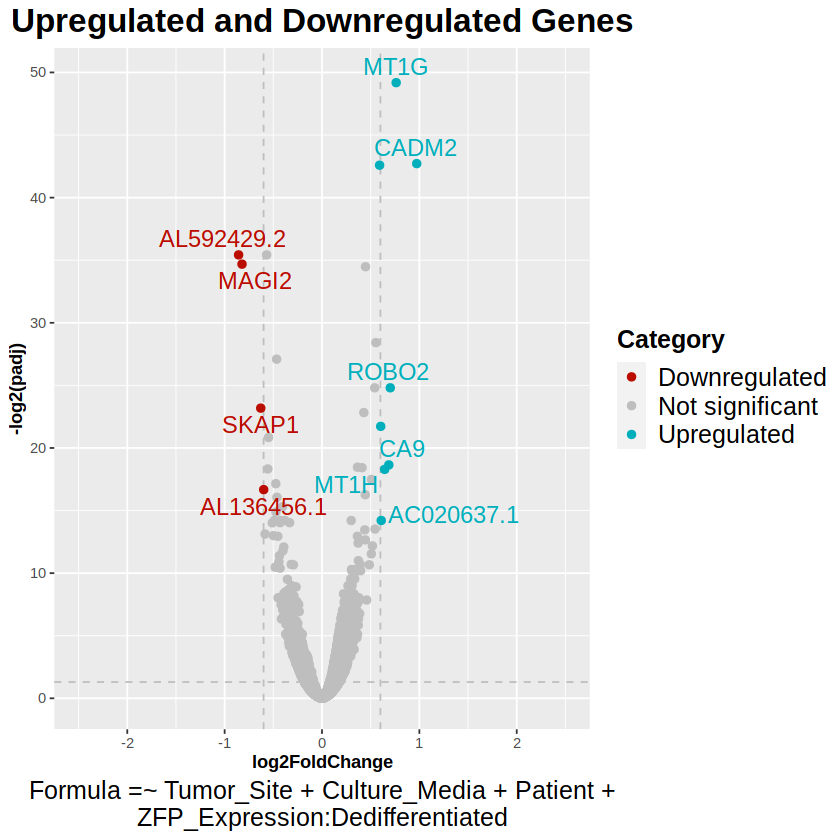

In [57]:
# Volcano plot
# Define significant genes based on the value of padj and log2FoldChange
res6_df$Category <- ifelse(res6_df$padj < 0.05 & abs(res6_df$log2FoldChange) > log2(1.5),
                            ifelse(res6_df$log2FoldChange > 0, "Upregulated", "Downregulated"),
                            "Not significant")

# Filter out rows with missing values
res6_df <- na.omit(res6_df)

# Customize the plot
custom_theme <- theme(
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold"),
    legend.text = element_text(size = 15),
    legend.title = element_text(size = 15, face = "bold"),
    axis.title.x = element_text(face="bold"),
    axis.title.y = element_text(face="bold"),
    plot.caption = element_text(hjust = 0.5, size = 15)
)

# Your existing ggplot code with modifications for theme settings
ggplot(data = res6_df, aes(x = log2FoldChange, y = -log2(padj), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.05), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-2.5, 2.5)) +
  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_6,
            aes(label = rownames(top_upregulated_genes_6)), 
            nudge_y = 0.3, color = "#00AFBB", size = 5) +
  
  geom_text_repel(data = top_downregulated_genes_6,
            aes(label = rownames(top_downregulated_genes_6)), 
            nudge_y = -0.3, color = "#bb0c00", size = 5) +

  labs(title = stringr::str_wrap("Significant Upregulated and Downregulated Genes", width = 50), 
      caption = stringr::str_wrap("Formula =~ Tumor_Site + Culture_Media + Patient + ZFP_Expression:Dedifferentiated", width = 50)) +

  ggtitle('Upregulated and Downregulated Genes') + 
  custom_theme 

### Patient 146: design = ~ Tumor_Site + Culture_Media + ZFP_Expression + ZFP_Expression:Tumor_Site

In [37]:
# Load the DESeqResults object
dds_7 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/metacell_ptn146_zfpexp_tsint_dds.rds")
resultsNames(dds_7)

res_7 <- results(dds_7, contrast = list(c("Tumor_SiteMetastatic.ZFP_ExpressionZFPKD")))
                                          
res7_df <- as.data.frame(res_7)

[1] "Intercept"                               
[2] "Tumor_Site_Metastatic_vs_Primary"        
[3] "Culture_Media_Dedifferentiated_vs_BASE"  
[4] "Culture_Media_HISC_vs_BASE"              
[5] "ZFP_Expression_ZFPKD_vs_CTRL"            
[6] "Tumor_SiteMetastatic.ZFP_ExpressionZFPKD"

In [38]:
# Define significant genes based on the value of padj and log2FoldChange
res7_df$Significant = res7_df$padj < 0.05 & abs(res7_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_7 = res7_df[res7_df$Significant, ]
significant_genes_df_7 <- significant_genes_df_7[complete.cases(significant_genes_df_7$padj), ]
significant_genes_df_7 <- na.omit(significant_genes_df_7)
significant_genes_df_7

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC003988.1,1.179759,0.6409042,0.11271993,5.685811,1.301934e-08,2.101491e-06,TRUE
AC005323.2,1.228696,0.7735116,0.11217437,6.895619,5.363091e-12,1.810043e-09,TRUE
AC005726.1,1.550830,0.6495640,0.09303815,6.981695,2.916392e-12,1.056303e-09,TRUE
AC008591.1,1.577963,0.9967355,0.10057513,9.910358,3.752997e-23,4.287077e-20,TRUE
AC009313.1,1.304581,-1.1739108,0.10158676,-11.555746,6.904543e-31,1.708874e-27,TRUE
AC018816.1,1.514613,-0.8952542,0.09330423,-9.595001,8.391613e-22,7.330321e-19,TRUE
AC020637.1,1.369870,0.9040032,0.10791333,8.377123,5.423710e-17,3.355921e-14,TRUE
AC090001.1,1.230319,-0.9780649,0.10427897,-9.379311,6.640526e-21,4.930590e-18,TRUE
AC093817.2,1.932477,-0.6258267,0.08888055,-7.041211,1.905764e-12,7.075148e-10,TRUE


In [39]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted_7 <- significant_genes_df_7[order(significant_genes_df_7$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes_7 <- head(significant_genes_sorted_7, 10)
top_upregulated_genes_7

# Top 10 downregulated genes
top_downregulated_genes_7 <- tail(significant_genes_sorted_7, 10)
top_downregulated_genes_7

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted_7, 10)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted_7, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC099520.1,2.394244,1.7560857,0.09330825,18.820262,5.152915e-79,7.652078e-75,TRUE
GPC5,1.480960,1.3236480,0.09723309,13.613144,3.345389e-42,1.655968e-38,TRUE
ACOXL,1.372911,1.3212872,0.09885521,13.365883,9.569249e-41,3.552584e-37,TRUE
SCHLAP1,1.229562,1.1140389,0.10460289,10.650174,1.740393e-26,3.230605e-23,TRUE
ADAMTS19,2.540769,1.0262701,0.07869604,13.040936,7.157273e-39,2.125710e-35,TRUE
AC008591.1,1.577963,0.9967355,0.10057513,9.910358,3.752997e-23,4.287077e-20,TRUE
UTS2B,1.221314,0.9617041,0.10478060,9.178265,4.380926e-20,3.097940e-17,TRUE
AC020637.1,1.369870,0.9040032,0.10791333,8.377123,5.423710e-17,3.355921e-14,TRUE
AL161725.1,1.301813,0.8655284,0.10089511,8.578497,9.612047e-18,6.206039e-15,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
MANEA,2.487309,-0.7690596,0.07800643,-9.858925,6.271699e-23,6.652480e-20,TRUE
SOX5,2.143420,-0.8900487,0.08561901,-10.395457,2.600373e-25,4.290616e-22,TRUE
AC018816.1,1.514613,-0.8952542,0.09330423,-9.595001,8.391613e-22,7.330321e-19,TRUE
AC090001.1,1.230319,-0.9780649,0.10427897,-9.379311,6.640526e-21,4.930590e-18,TRUE
PDZD7,1.296864,-0.9832523,0.10179447,-9.659192,4.493953e-22,4.170950e-19,TRUE
ROBO2,1.676536,-0.9924794,0.09650593,-10.284129,8.308998e-25,1.233886e-21,TRUE
KEL,1.197610,-1.0108542,0.10564966,-9.567984,1.090105e-21,8.993365e-19,TRUE
LINC02410,1.232106,-1.1603635,0.10481626,-11.070453,1.745158e-28,3.702227e-25,TRUE
AC009313.1,1.304581,-1.1739108,0.10158676,-11.555746,6.904543e-31,1.708874e-27,TRUE


Top 10 Upregulated Genes:
 [1] "AC099520.1" "GPC5"       "ACOXL"      "SCHLAP1"    "ADAMTS19"  
 [6] "AC008591.1" "UTS2B"      "AC020637.1" "AL161725.1" "IL1RAPL1"  

Top 10 Downregulated Genes:
 [1] "MANEA"      "SOX5"       "AC018816.1" "AC090001.1" "PDZD7"     
 [6] "ROBO2"      "KEL"        "LINC02410"  "AC009313.1" "CADM2"     


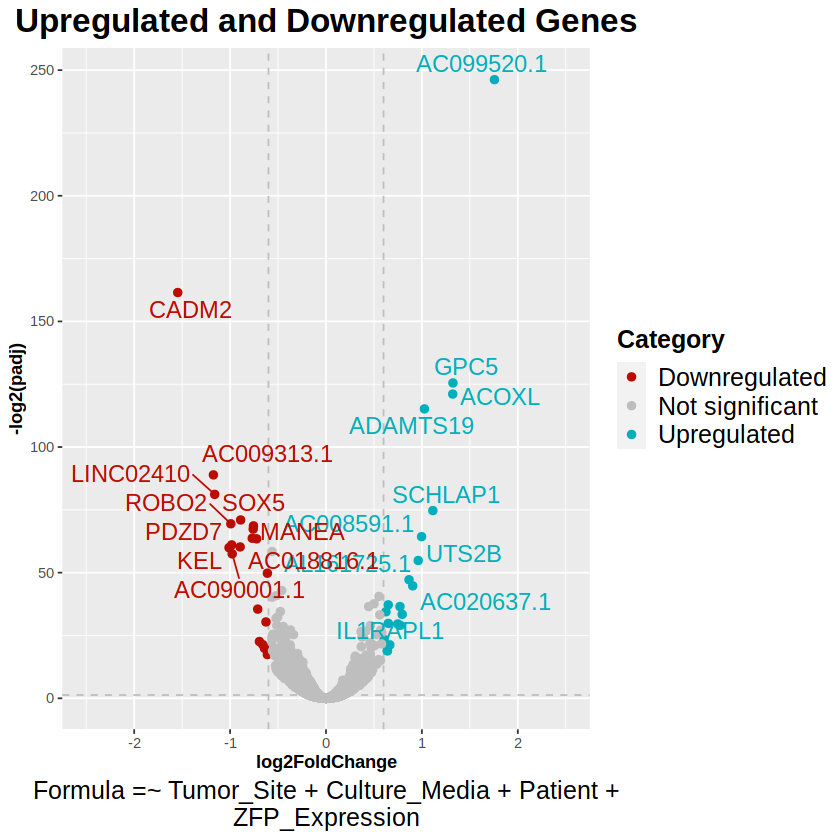

In [42]:
# Volcano plot
# Define significant genes based on the value of padj and log2FoldChange
res7_df$Category <- ifelse(res7_df$padj < 0.05 & abs(res7_df$log2FoldChange) > log2(1.5),
                            ifelse(res7_df$log2FoldChange > 0, "Upregulated", "Downregulated"),
                            "Not significant")

# Filter out rows with missing values
res7_df <- na.omit(res7_df)

# Customize the plot
custom_theme <- theme(
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold"),
    legend.text = element_text(size = 15),
    legend.title = element_text(size = 15, face = "bold"),
    axis.title.x = element_text(face="bold"),
    axis.title.y = element_text(face="bold"),
    plot.caption = element_text(hjust = 0.5, size = 15)
)

# Your existing ggplot code with modifications for theme settings
ggplot(data = res7_df, aes(x = log2FoldChange, y = -log2(padj), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.05), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-2.5, 2.5)) +

  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_7,
            aes(label = rownames(top_upregulated_genes_7)), 
            nudge_y = 0.3, color = "#00AFBB", size = 5, max.overlaps = Inf) +
  
  geom_text_repel(data = top_downregulated_genes_7,
            aes(label = rownames(top_downregulated_genes_7)), 
            nudge_y = -0.3, color = "#bb0c00", size = 5, max.overlaps = Inf) +

  labs(title = stringr::str_wrap("Significant Upregulated and Downregulated Genes", width = 50), 
      caption = stringr::str_wrap("Formula =~ Tumor_Site + Culture_Media + Patient + ZFP_Expression", width = 50)) +

  ggtitle('Upregulated and Downregulated Genes') + 
  custom_theme 

## Volcano Plot (Highlight Significant Interaction Genes) 

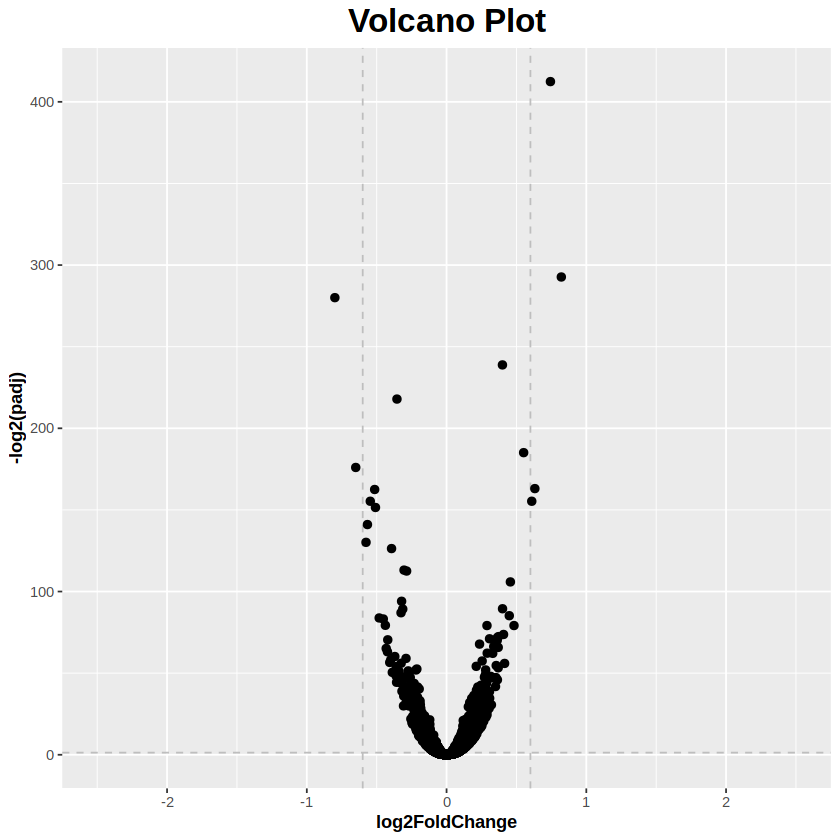

In [23]:
# Customize the plot
custom_theme <- theme(
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold"),
    legend.text = element_text(size = 15),
    legend.title = element_text(size = 15, face = "bold"),
    axis.title.x = element_text(face="bold"),
    axis.title.y = element_text(face="bold"),
    plot.caption = element_text(hjust = 0.5, size = 15)
)

# Create volcano plot
ggplot(data = res1_df, aes(x = log2FoldChange, y = -log2(padj))) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.05), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  coord_cartesian(xlim = c(-2.5, 2.5)) +
  labs(title = stringr::str_wrap("Volcano Plot", width = 50)) +
  ggtitle('Volcano Plot') + 
  custom_theme

# GSEA

In [46]:
# Define a function to run GSEA
gset = list()

for (i in c('small','large')) {
    if (i=='large')
        gmt_fn = sprintf('/data/chanjlab/CRC_ZFP36L2.092023/ref/pathways_for_gsea.curated.small.110123.gmt',i)
    else
        gmt_fn = '/data/chanjlab/CRC_ZFP36L2.092023/ref/pathways_for_gsea.curated.small.110123.gmt'
        
    gset[[i]] = gage::readList(gmt_fn)
}

RunGSEA <- function(deg_df, gset0) {
  min_fdr = sort(unique(deg_df$padj))[2]
  deg_df$padj[deg_df$padj==0] = min_fdr
  rnk = -log2(deg_df$padj) * (2*(deg_df$log2FoldChange > 0) - 1)

  names(rnk) = rownames(deg_df)
  score = rnk[!is.na(rnk)] 
  
  fgseaRes <- fgsea(pathways = gset0, 
              stats = score,
              minSize=10,
              maxSize=500)#,
              #nperm=10000)
  
  fgseaRes$leadingEdge = sapply(fgseaRes$leadingEdge, function(x) str_c(x,collapse=','))
  return(fgseaRes) 
}

Warning message in sprintf("/data/chanjlab/CRC_ZFP36L2.092023/ref/pathways_for_gsea.curated.small.110123.gmt", :
“one argument not used by format '/data/chanjlab/CRC_ZFP36L2.092023/ref/pathways_for_gsea.curated.small.110123.gmt'”


In [49]:
# Make output directory for GSEA
gsea_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/gsea/'
dir.create(gsea_dir)

Warning message in dir.create(gsea_dir):
“'/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/gsea' already exists”


In [56]:
# Set the mode to 'small' since there is only a 'small' gsea pathway list
mode = 'small'

for (i in 1:7) {
  df_name <- sprintf("res%d_df", i)
  fgseaRes = RunGSEA(get(df_name), gset[[mode]])

  ofile = sprintf('gsea.%s_%d.txt', mode, i)
  write.table(fgseaRes, sprintf('%s/%s', gsea_dir, ofile), sep = '\t', quote = F, row.names = F)

  pval_cutoff = 0.1
  ind1 = fgseaRes$padj < pval_cutoff
  ind2 = abs(fgseaRes$NES) > 1
  ind1[is.na(ind1)] = FALSE
  ind2[is.na(ind2)] = FALSE

  write.table(fgseaRes[ind1 & ind2, ],
              sprintf('%s/%s', gsea_dir, gsub('.txt', '.filtered.txt', ofile)), sep = '\t', quote = F, row.names = F)
}

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (42.83% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (49.13% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (62.37% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (97.46% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndSta

# Lollipop Plots

In [36]:
# This is a .txt file with interesting pathways
paths = readLines('/data/chanjlab/CRC_ZFP36L2.092023/Patients.HTAN/outcombined.10.06.2023/updated_analyses_adata/GSEA/GSEA.knnDremiDownstream.small.pathways_interest.txt')

In [37]:
# This is the GSEA output .txt file
gsea_df <- read.table('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/gsea/gsea.small_2.filtered.txt', header = TRUE, sep = "\t")

In [38]:
gsea_df

pathway,pval,padj,log2err,ES,NES,size,leadingEdge
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
BASAKI_YBX1_TARGETS_DN,8.605760e-04,0.047875018,0.4772708,0.6643310,1.660907,326,"H19,TFPI,CKB,ALDH1A2,BHLHE40,TSPAN1,ALDOC,ISG20,SYTL2,SCD,HECW2,DPP4,ADM,SEMA4B,MALL,NDRG1,NCALD,ARRB1,PNP,TMC5,RDH10,VEGFA,HK2,PITPNC1,DUSP5,FAM189A1,PDK1,P4HA1,PGK1,STOX1,TMEM47,PLEKHA1,PFKFB3,SMOC2,SEZ6L2,EEF2K,NT5E,MZF1,SERPINA1,NET1,FAM13A,PLOD2,SLC9A1,SH3PXD2A,NADSYN1,KDM4B,GDF15,MPZL2,LMBRD2,FAM162A,TM7SF2,ABCA5,SLC30A1,GAL3ST1,TMEM37"
BASAL_MONTORO,5.362108e-03,0.099735209,0.4070179,0.8333944,1.637886,36,"FXYD3,EPAS1,SDC1,OAT,S100A14,SGK1,TACSTD2,KRT15,F3,HSPB1,ID1,SFN"
CREIGHTON_ENDOCRINE_THERAPY_RESISTANCE_4,3.357801e-03,0.080295666,0.4317077,0.6654134,1.629400,232,"H19,ADAMTS19,BHLHE40,P4HA2,RGS22,DHCR7,IGF1R,ATP2B4,SEMA3F,PDLIM1,BAG3,AFAP1L2,PNPLA3,TTC39A,IL17RB,ZHX2,DLC1,SLC27A2,F12,TSKU"
GO_NEURONAL_ION_CHANNEL_CLUSTERING,1.032440e-03,0.048008445,0.4550599,0.9596571,1.593686,10,"NRCAM,NFASC,CNTNAP2,SCLT1"
GO_NEURON_PROJECTION_DEVELOPMENT,1.201958e-03,0.048904672,0.4550599,0.6356404,1.601381,342,"NRCAM,KLF7,LRP4,TUBB3,FMOD,TIAM1,UCHL1,NFASC,FGFR1,EPHB3,ADM,AREG,CNTNAP2,STX3,EHD1,DRD2,DNM2,MICALL2,TSPO,VEGFA,MATN2,SEMA5A,SLC11A2,SEMA3F,APOE,GBX2,EZR,SHH,SGK1,SS18L1,PTPRO,ROBO2,EFNB1,B3GNT2,DYNLT1,ZNF335,S100A6,CTTN,FLOT1,ARTN,KIF5C,TSKU,KIF20B,NRXN3,AURKA,SEMA3A,DAG1,BAIAP2,GDPD5,LYN,NBL1,PQBP1,EPHB1,UHMK1,HRAS,SHC1,EVL,CLMN"
GO_NEURON_PROJECTION_MORPHOGENESIS,4.803318e-03,0.094756359,0.4070179,0.6610889,1.628497,238,"NRCAM,KLF7,LRP4,TUBB3,FMOD,TIAM1,UCHL1,NFASC,EPHB3,DRD2,DNM2,VEGFA,MATN2,SLC11A2,SEMA3F,GBX2,EZR,SHH,SGK1,PTPRO,ROBO2,EFNB1,B3GNT2,DYNLT1,ZNF335,S100A6,CTTN,FLOT1,ARTN,KIF5C,TSKU,KIF20B,NRXN3,AURKA,SEMA3A,DAG1,BAIAP2,NBL1,EPHB1,HRAS,EVL"
GO_NEURON_RECOGNITION,2.938292e-03,0.077327510,0.4317077,0.9243134,1.672198,18,"NRCAM,CXCR4,EPHB3,CNTNAP2,SEMA5A,ROBO2,SEMA3A"
HALLMARK_HEDGEHOG_SIGNALING,1.728558e-03,0.066193619,0.4550599,0.9156652,1.699858,22,"NRCAM,VEGFA,SHH,AMOT,PTCH1"
HALLMARK_HYPOXIA,2.986237e-04,0.045152258,0.4984931,0.7618101,1.802527,156,"S100A4,KLF7,SLC2A1,BHLHE40,PGF,P4HA2,CXCR4,GPI,ALDOC,ISG20,AMPD3,PGM1,SULT2B1,GPC4,KDM3A,ADM,LDHA,NDRG1,TPST2,PCK1,VEGFA,HK2,PDK1,P4HA1,EGFR,PGK1,TGFBI,HMOX1,CDKN1A,SCARB1,ILVBL,XPNPEP1,PFKFB3,ALDOA,PPFIA4,ENO1,ANKZF1,GYS1,FOSL2,TPI1,PFKP,PIM1,PDGFB,SLC6A6,JMJD6,ANXA2,CDKN1C,F3,FAM162A,ADORA2B,UGP2,RRAGD,GBE1,NAGK,FOS,SERPINE1,ENO2,GALK1,ZFP36,AK4,GLRX,EFNA3"


In [43]:
# Filter out duplicate rows in the 'pathway' column from the GSEA dataframe
gsea_df = gsea_df[!duplicated(gsea_df$pathway),]

# Filter out the dataframe again, this time, keeping only rows where abs(NES) > 1 & padj < 0.05
gsea_df = gsea_df %>% dplyr::filter(abs(NES) > 1 & padj < 0.05)

In [44]:
gsea_df

pathway,pval,padj,log2err,ES,NES,size,leadingEdge
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
BASAKI_YBX1_TARGETS_DN,8.605760e-04,0.047875018,0.4772708,0.6643310,1.660907,326,"H19,TFPI,CKB,ALDH1A2,BHLHE40,TSPAN1,ALDOC,ISG20,SYTL2,SCD,HECW2,DPP4,ADM,SEMA4B,MALL,NDRG1,NCALD,ARRB1,PNP,TMC5,RDH10,VEGFA,HK2,PITPNC1,DUSP5,FAM189A1,PDK1,P4HA1,PGK1,STOX1,TMEM47,PLEKHA1,PFKFB3,SMOC2,SEZ6L2,EEF2K,NT5E,MZF1,SERPINA1,NET1,FAM13A,PLOD2,SLC9A1,SH3PXD2A,NADSYN1,KDM4B,GDF15,MPZL2,LMBRD2,FAM162A,TM7SF2,ABCA5,SLC30A1,GAL3ST1,TMEM37"
GO_NEURONAL_ION_CHANNEL_CLUSTERING,1.032440e-03,0.048008445,0.4550599,0.9596571,1.593686,10,"NRCAM,NFASC,CNTNAP2,SCLT1"
GO_NEURON_PROJECTION_DEVELOPMENT,1.201958e-03,0.048904672,0.4550599,0.6356404,1.601381,342,"NRCAM,KLF7,LRP4,TUBB3,FMOD,TIAM1,UCHL1,NFASC,FGFR1,EPHB3,ADM,AREG,CNTNAP2,STX3,EHD1,DRD2,DNM2,MICALL2,TSPO,VEGFA,MATN2,SEMA5A,SLC11A2,SEMA3F,APOE,GBX2,EZR,SHH,SGK1,SS18L1,PTPRO,ROBO2,EFNB1,B3GNT2,DYNLT1,ZNF335,S100A6,CTTN,FLOT1,ARTN,KIF5C,TSKU,KIF20B,NRXN3,AURKA,SEMA3A,DAG1,BAIAP2,GDPD5,LYN,NBL1,PQBP1,EPHB1,UHMK1,HRAS,SHC1,EVL,CLMN"
HALLMARK_HYPOXIA,2.986237e-04,0.045152258,0.4984931,0.7618101,1.802527,156,"S100A4,KLF7,SLC2A1,BHLHE40,PGF,P4HA2,CXCR4,GPI,ALDOC,ISG20,AMPD3,PGM1,SULT2B1,GPC4,KDM3A,ADM,LDHA,NDRG1,TPST2,PCK1,VEGFA,HK2,PDK1,P4HA1,EGFR,PGK1,TGFBI,HMOX1,CDKN1A,SCARB1,ILVBL,XPNPEP1,PFKFB3,ALDOA,PPFIA4,ENO1,ANKZF1,GYS1,FOSL2,TPI1,PFKP,PIM1,PDGFB,SLC6A6,JMJD6,ANXA2,CDKN1C,F3,FAM162A,ADORA2B,UGP2,RRAGD,GBE1,NAGK,FOS,SERPINE1,ENO2,GALK1,ZFP36,AK4,GLRX,EFNA3"
HALLMARK_MTORC1_SIGNALING,3.467915e-04,0.045152258,0.4984931,0.7240106,1.756640,189,"FADS2,SLC2A1,BHLHE40,FADS1,CXCR4,GPI,SYTL2,PGM1,SCD,TFRC,LDHA,PNP,EGLN3,INSIG1,DHCR7,HK2,PDK1,SERPINH1,RDH11,P4HA1,PGK1,SLC1A5,TUBA4A,CDKN1A,DDX39A,GOT1,IDI1,ALDOA,ENO1,LDLR,ACLY,TPI1,EBP,LGMN,SLC6A6,PLOD2,ADIPOR2,AURKA,TOMM40,TM7SF2,PSMD12,GLA,PLK1,TUBG1,MTHFD2,RRP9,SRD5A1,STIP1,ME1,GBE1,MAP2K3,DHCR24,AK4,GLRX,ACSL3,PSMC4,HSPA9"
HotSpotModule_19.EPI_STEM_CELLS,9.560296e-04,0.047875018,0.4772708,0.9056093,1.758239,31,"CKB,S100A4,FXYD3,SLC2A1,F10,IGF2BP1,FBXO2,DSCR8,FOXQ1"
LIAO_METASTASIS,8.433331e-04,0.047875018,0.4772708,0.6171968,1.582244,454,"NRCAM,ARHGEF2,FXYD3,SLC6A8,PFKFB4,SLC2A1,PGF,CD24,MIR210HG,HKDC1,KRT23,UCHL1,PTGES,HUNK,NPAS2,CKAP4,PAQR5,PDK1,MAP7D2,SPINK1,SERPINH1,BOP1,SEMA3F,PTP4A3,PWWP2B,ALDOA,DPP3,B3GAT3,SAC3D1,ATP13A2,KLHL29,NQO1,LASP1,SPAG4,E2F1,ALDH18A1,FOXQ1,ARG2,HES4,NOL3,TKT,CAPG,ANXA2,ZNF532,CDKN1C,SERINC2,PLD1,LRP11,PLP2,NETO2,ITPR3,MTHFD2,SLC39A4,IPPK,RRAS,RRAGD,SOAT1,HRAS,SHC1,SLC29A4,PTGFRN,SPINT1,FAM50A,LAMA5,CCDC97,TUBB2A,IGSF3,ENO2,IKZF4,ST14,SSBP4,SLC36A1,HYOU1,KCNQ1,ZDHHC24,SULT1C2,NEAT1,TCIRG1,CAPN10,SCRIB"
LIU_SOX4_TARGETS_DN,1.127751e-03,0.048904672,0.4550599,0.6677981,1.662265,278,"TFPI,CPT1A,GPI,BNIP3,FUT11,LDHA,LONP1,TCP1,VEGFA,PDK1,DLAT,SORBS3,ENO1,MKNK2,STAU1,MVK,ACY1,FAM13A,EHF,NOLC1,TRAF4,KIF5C,SMC3,EIF4E2,ATP6AP1,TMEM135,LRP5,ITPK1,ITPR3,TBC1D9B,PPFIA1,NFIX,STIP1,HMGCS2,RGS2,B4GALT6,MMS19,RPS6KB2,UBE2M,HSPA8,SLC25A16,AP2S1,ITGB1BP1,PAFAH1B1,SPATA5L1,WBP2"
LI_AMPLIFIED_IN_LUNG_CANCER,4.863978e-04,0.047875018,0.4984931,0.7698876,1.818291,150,"TFF1,IGFBP2,PHLDA2,GPI,UCHL1,LDHA,MALL,AKR1C1,CKAP4,VEGFA,SPINK1,CYCS,CEACAM5,ALDOA,ENO1,YIF1A,PLAU,PFKP,IDH2,NQO1,TFF3,LGALS3BP,CDK2AP2,P4HB,TRAF4,TKT,HSPB1,SFN,PLP2,CCT5,PGD,SLC22A18,SPINT1,SDHA,UBE2C,HYOU1,CALR,CEACAM6,FGB,SPINT2,TRIM28,HSPD1,JUP"


In [61]:
# Group the pathways by different categories
pathway_categories = data.frame(pathway = paths, category = '', row.names = paths)
pathway_categories$category[grepl('ASC_|ES_|STEM',pathway_categories$pathway)] = 'Stemness'
pathway_categories$category[grepl('MYC',pathway_categories$pathway)] = 'MYC'
pathway_categories$category[grepl('APOPTOSIS',pathway_categories$pathway)] = 'Apoptosis'
pathway_categories$category[grepl('PROLIFERATION',pathway_categories$pathway)] = 'Proliferation'
pathway_categories$category[grepl('AKT',pathway_categories$pathway)] = 'AKT/MTOR'
pathway_categories$category[grepl('STAT',pathway_categories$pathway)] = 'STAT'
pathway_categories$category[grepl('AXON|NEURO',pathway_categories$pathway)] = 'Neuronal'
pathway_categories$category[grepl('TGFB',pathway_categories$pathway)] = 'TGFB1'
pathway_categories$category[grepl('TERT',pathway_categories$pathway)] = 'TERT'
pathway_categories$category[grepl('IFN|INTERFERON|INFLAMM',pathway_categories$pathway)] = 'Inflammation'
pathway_categories$category[grepl('TCF|WNT|APC',pathway_categories$pathway)] = 'APC/WNT'
pathway_categories$category[grepl('E2F',pathway_categories$pathway)] = 'MAPK'
pathway_categories$category[grepl('COLON',pathway_categories$pathway)] = 'CRC'
pathway_categories$category[grepl('RESISTANCE',pathway_categories$pathway)] = 'Resistance'
pathway_categories$category[grepl('METABOLISM|OXIDATIVE_PHOSPHORYLATION|RESPIRATORY_ELECTRON',pathway_categories$pathway)] = 'Metabolism'
pathway_categories$category[grepl('AP1',pathway_categories$pathway)] = 'AP1'
pathway_categories$category[grepl('STRESS',pathway_categories$pathway)] = 'Stress'
pathway_categories$category[grepl('METASTASIS|DHESION|ADHERENS|HAPTOTAXIS|NVASIVEN',pathway_categories$pathway)] = 'Metastasis'
pathway_categories$category[grepl('SCLC-P|MUCINOUS|SQUAMOUS|BASAL|ENTEROCYTES|LEUKO',pathway_categories$pathway)] = 'Differentiated'
pathway_categories$category[grepl('BRCA|PRMT5|CAMP|ESRR',pathway_categories$pathway)] = 'Misc'
pathway_categories$category[grepl('_DN',pathway_categories$pathway)] = 'Down-Regulated'
pathway_categories$category[grepl('_SIGNALING',pathway_categories$pathway)] = 'Signaling'
pathway_categories$category = factor(pathway_categories$category)

In [62]:
pathway_categories

,pathway,category
,<chr>,<fct>
PID_IFNG_PATHWAY,PID_IFNG_PATHWAY,Inflammation
SHEN_SMARCA2_TARGETS_UP,SHEN_SMARCA2_TARGETS_UP,
CHANDRAN_METASTASIS_UP,CHANDRAN_METASTASIS_UP,Metastasis
HALLMARK_TGF_BETA_SIGNALING,HALLMARK_TGF_BETA_SIGNALING,Signaling
MILI_PSEUDOPODIA_CHEMOTAXIS_DN,MILI_PSEUDOPODIA_CHEMOTAXIS_DN,Down-Regulated
REACTOME_SIGNALING_BY_BMP,REACTOME_SIGNALING_BY_BMP,Signaling
KEGG_NOTCH_SIGNALING_PATHWAY,KEGG_NOTCH_SIGNALING_PATHWAY,Signaling
BIOCARTA_WNT_PATHWAY,BIOCARTA_WNT_PATHWAY,APC/WNT
PID_WNT_CANONICAL_PATHWAY,PID_WNT_CANONICAL_PATHWAY,APC/WNT


In [67]:
# Create a new dataframe to find corresponding paths in GSEA and pathways dataframe
plot_df = gsea_df %>% dplyr::filter(pathway %in% paths)

# Make a new column in the datagrame called category to place the pathway in the corresponding pathway category
plot_df$category = pathway_categories[plot_df$pathway, 'category']

# Order the pathway by NES value
plot_df = plot_df[order(plot_df$NES, plot_df$category),]

# Define other plotting parameters
plot_df$Significance = -log2(plot_df$padj)
up_df = plot_df[plot_df$NES > 0,]
ord1 = (up_df %>% group_by(category) %>% summarise(max = max(NES)) %>% arrange(max))$category
up_df$category = factor(up_df$category, levels=ord1)
up_df = up_df %>% dplyr::arrange(category, NES)
dn_df = plot_df[plot_df$NES < 0,]
ord2 = (dn_df %>% group_by(category) %>% summarise(min = min(NES)) %>% arrange(min))$category
dn_df$category = factor(dn_df$category, levels=ord2)
dn_df = dn_df %>% dplyr::arrange(category, NES)
plot_df2 = rbind(dn_df,up_df)
plot_df2$pathway = factor(plot_df2$pathway, levels = plot_df2$pathway)

In [68]:
plot_df

,pathway,pval,padj,log2err,ES,NES,size,leadingEdge,category,Significance
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<fct>,<dbl>
4,MILI_PSEUDOPODIA_CHEMOTAXIS_DN,0.0009387990,0.04787502,0.4772708,0.6196964,1.569597,392,"SLC2A1,P4HA2,LRP1,FOSB,PGM1,SCD,FGFR1,PVR,TIMP2,GMCL1,STT3A,EIF2AK3,CKAP4,CHUK,DNTTIP1,ZMIZ1,P4HA1,IGF1R,SYVN1,POR,MATN2,ABCA7,BOP1,SLC11A2,SEMA3F,PCDH1,PIM3,LRRC8C,LDLR,PLOD1,B3GAT3,ACLY,CHPF,NPC1,RRBP1,LGMN,ARFGAP3,SLC6A6,MED15,ATP13A1,SLC39A14,TXNIP,F3,NAGLU,ADORA2B,KDM6B,GLA,DAG1,CPSF7,BAIAP2,MFSD11,SLC39A7,DGAT1,METRNL,NAGK,FOS,SLC7A6,SERPINE1,TIMP3,GANAB,IGSF3,SLC20A1,RCN3,RGMB,TMED7,LHFPL2,ZFP36,SLC16A1,HSPA8,IGSF8,NEU1,NEAT1,ABCC1,AHCTF1,QSOX1,SNHG3,CALU,SBNO2,KLF6,RGS3,ELOVL1,RIOK1,PLXNA3,SLC19A1,NCEH1,BRMS1,PSAP,TMEM33,PFKL,UBE2B,ZDHHC5,CDS2,DUSP1,CNNM2,SLC29A1,DDR1",Down-Regulated,4.384583
1,BASAKI_YBX1_TARGETS_DN,0.0008605760,0.04787502,0.4772708,0.6643310,1.660907,326,"H19,TFPI,CKB,ALDH1A2,BHLHE40,TSPAN1,ALDOC,ISG20,SYTL2,SCD,HECW2,DPP4,ADM,SEMA4B,MALL,NDRG1,NCALD,ARRB1,PNP,TMC5,RDH10,VEGFA,HK2,PITPNC1,DUSP5,FAM189A1,PDK1,P4HA1,PGK1,STOX1,TMEM47,PLEKHA1,PFKFB3,SMOC2,SEZ6L2,EEF2K,NT5E,MZF1,SERPINA1,NET1,FAM13A,PLOD2,SLC9A1,SH3PXD2A,NADSYN1,KDM4B,GDF15,MPZL2,LMBRD2,FAM162A,TM7SF2,ABCA5,SLC30A1,GAL3ST1,TMEM37",Down-Regulated,4.384583
3,LIU_SOX4_TARGETS_DN,0.0011277508,0.04890467,0.4550599,0.6677981,1.662265,278,"TFPI,CPT1A,GPI,BNIP3,FUT11,LDHA,LONP1,TCP1,VEGFA,PDK1,DLAT,SORBS3,ENO1,MKNK2,STAU1,MVK,ACY1,FAM13A,EHF,NOLC1,TRAF4,KIF5C,SMC3,EIF4E2,ATP6AP1,TMEM135,LRP5,ITPK1,ITPR3,TBC1D9B,PPFIA1,NFIX,STIP1,HMGCS2,RGS2,B4GALT6,MMS19,RPS6KB2,UBE2M,HSPA8,SLC25A16,AP2S1,ITGB1BP1,PAFAH1B1,SPATA5L1,WBP2",Down-Regulated,4.353884
2,HALLMARK_MTORC1_SIGNALING,0.0003467915,0.04515226,0.4984931,0.7240106,1.756640,189,"FADS2,SLC2A1,BHLHE40,FADS1,CXCR4,GPI,SYTL2,PGM1,SCD,TFRC,LDHA,PNP,EGLN3,INSIG1,DHCR7,HK2,PDK1,SERPINH1,RDH11,P4HA1,PGK1,SLC1A5,TUBA4A,CDKN1A,DDX39A,GOT1,IDI1,ALDOA,ENO1,LDLR,ACLY,TPI1,EBP,LGMN,SLC6A6,PLOD2,ADIPOR2,AURKA,TOMM40,TM7SF2,PSMD12,GLA,PLK1,TUBG1,MTHFD2,RRP9,SRD5A1,STIP1,ME1,GBE1,MAP2K3,DHCR24,AK4,GLRX,ACSL3,PSMC4,HSPA9",Signaling,4.469058


In [24]:
plot_df = gsea_df %>% dplyr::filter(pathway %in% paths) 
plot_df$category = pathway_categories[plot_df$pathway, 'category']

plot_df = plot_df[order(plot_df$NES, plot_df$category),]
plot_df$Significance = -log2(plot_df$padj)
up_df = plot_df[plot_df$NES > 0,]
ord1 = (up_df %>% group_by(category) %>% summarise(max = max(NES)) %>% arrange(max))$category
up_df$category = factor(up_df$category, levels=ord1)
up_df = up_df %>% dplyr::arrange(category, NES)
dn_df = plot_df[plot_df$NES < 0,]
ord2 = (dn_df %>% group_by(category) %>% summarise(min = min(NES)) %>% arrange(min))$category
dn_df$category = factor(dn_df$category, levels=ord2)
dn_df = dn_df %>% dplyr::arrange(category, NES)
plot_df2 = rbind(dn_df,up_df)
plot_df2$pathway = factor(plot_df2$pathway, levels = plot_df2$pathway)

Warning message:
“There was 1 warning in `summarise()`.
ℹ In argument: `min = min(NES)`.
Caused by warning in `min()`:
! no non-missing arguments to min; returning Inf”


Warning message:
“Removed 4 rows containing missing values (`geom_point()`).”


NULL

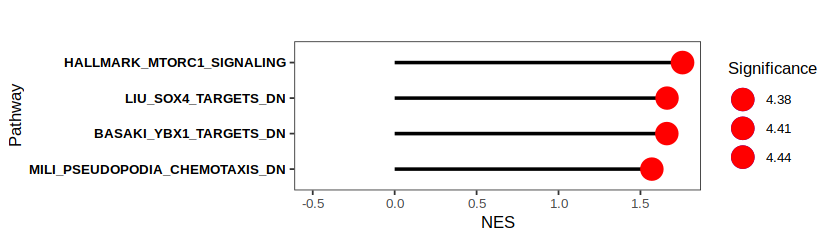

In [69]:
library(repr)
options(repr.plot.width=7, repr.plot.height=2)
plot_df2$category = factor(plot_df2$category, levels=sort(levels(plot_df2$category)))

ggplot() + 
geom_segment(data = plot_df2, aes(x=NES, y=pathway, xend=0, yend=pathway), size=1,color='black') +
geom_point(data = plot_df2[plot_df2$NES<0,],aes(x=NES, y=pathway, size=Significance),color='blue')+
geom_point(data = plot_df2[plot_df2$NES>0,],aes(x=NES, y=pathway, size=Significance),color='red')+
scale_size_area(max_size = 6)+ #scale_color_gradient(low="blue",high="red") +
theme_bw() + xlab('NES') + ylab('Pathway') + theme(text = element_text(size=10),
                                                   plot.title = element_text(hjust = 0.5,size=16),
                                                   panel.grid.minor = element_blank(),
                                                  panel.grid.major = element_blank(),
                                                  axis.text.y = element_text(color='black', face='bold')) +
geom_point(data = plot_df2, aes(x=-0.5, y = pathway), shape=NA, size=6) +
#scale_color_manual(name = "Pathways",values = myColors[names(myColors) %in% plot_df2$category]) +
ggtitle('')
guides(color=guide_legend(ncol=2)) +
xlim(-2,1.75)

In [19]:
plot_df

pathway,pval,padj,log2err,ES,NES,size,leadingEdge,category
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<fct>
BASAKI_YBX1_TARGETS_DN,0.0008605760,0.04787502,0.4772708,0.6643310,1.660907,326,"H19,TFPI,CKB,ALDH1A2,BHLHE40,TSPAN1,ALDOC,ISG20,SYTL2,SCD,HECW2,DPP4,ADM,SEMA4B,MALL,NDRG1,NCALD,ARRB1,PNP,TMC5,RDH10,VEGFA,HK2,PITPNC1,DUSP5,FAM189A1,PDK1,P4HA1,PGK1,STOX1,TMEM47,PLEKHA1,PFKFB3,SMOC2,SEZ6L2,EEF2K,NT5E,MZF1,SERPINA1,NET1,FAM13A,PLOD2,SLC9A1,SH3PXD2A,NADSYN1,KDM4B,GDF15,MPZL2,LMBRD2,FAM162A,TM7SF2,ABCA5,SLC30A1,GAL3ST1,TMEM37",
HALLMARK_MTORC1_SIGNALING,0.0003467915,0.04515226,0.4984931,0.7240106,1.756640,189,"FADS2,SLC2A1,BHLHE40,FADS1,CXCR4,GPI,SYTL2,PGM1,SCD,TFRC,LDHA,PNP,EGLN3,INSIG1,DHCR7,HK2,PDK1,SERPINH1,RDH11,P4HA1,PGK1,SLC1A5,TUBA4A,CDKN1A,DDX39A,GOT1,IDI1,ALDOA,ENO1,LDLR,ACLY,TPI1,EBP,LGMN,SLC6A6,PLOD2,ADIPOR2,AURKA,TOMM40,TM7SF2,PSMD12,GLA,PLK1,TUBG1,MTHFD2,RRP9,SRD5A1,STIP1,ME1,GBE1,MAP2K3,DHCR24,AK4,GLRX,ACSL3,PSMC4,HSPA9",
LIU_SOX4_TARGETS_DN,0.0011277508,0.04890467,0.4550599,0.6677981,1.662265,278,"TFPI,CPT1A,GPI,BNIP3,FUT11,LDHA,LONP1,TCP1,VEGFA,PDK1,DLAT,SORBS3,ENO1,MKNK2,STAU1,MVK,ACY1,FAM13A,EHF,NOLC1,TRAF4,KIF5C,SMC3,EIF4E2,ATP6AP1,TMEM135,LRP5,ITPK1,ITPR3,TBC1D9B,PPFIA1,NFIX,STIP1,HMGCS2,RGS2,B4GALT6,MMS19,RPS6KB2,UBE2M,HSPA8,SLC25A16,AP2S1,ITGB1BP1,PAFAH1B1,SPATA5L1,WBP2",
MILI_PSEUDOPODIA_CHEMOTAXIS_DN,0.0009387990,0.04787502,0.4772708,0.6196964,1.569597,392,"SLC2A1,P4HA2,LRP1,FOSB,PGM1,SCD,FGFR1,PVR,TIMP2,GMCL1,STT3A,EIF2AK3,CKAP4,CHUK,DNTTIP1,ZMIZ1,P4HA1,IGF1R,SYVN1,POR,MATN2,ABCA7,BOP1,SLC11A2,SEMA3F,PCDH1,PIM3,LRRC8C,LDLR,PLOD1,B3GAT3,ACLY,CHPF,NPC1,RRBP1,LGMN,ARFGAP3,SLC6A6,MED15,ATP13A1,SLC39A14,TXNIP,F3,NAGLU,ADORA2B,KDM6B,GLA,DAG1,CPSF7,BAIAP2,MFSD11,SLC39A7,DGAT1,METRNL,NAGK,FOS,SLC7A6,SERPINE1,TIMP3,GANAB,IGSF3,SLC20A1,RCN3,RGMB,TMED7,LHFPL2,ZFP36,SLC16A1,HSPA8,IGSF8,NEU1,NEAT1,ABCC1,AHCTF1,QSOX1,SNHG3,CALU,SBNO2,KLF6,RGS3,ELOVL1,RIOK1,PLXNA3,SLC19A1,NCEH1,BRMS1,PSAP,TMEM33,PFKL,UBE2B,ZDHHC5,CDS2,DUSP1,CNNM2,SLC29A1,DDR1",


In [13]:
gsea_df

,pathway,pval,padj,log2err,ES,NES,size,leadingEdge
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
1,BASAKI_YBX1_TARGETS_DN,8.605760e-04,0.047875018,0.4772708,0.6643310,1.660907,326,"H19,TFPI,CKB,ALDH1A2,BHLHE40,TSPAN1,ALDOC,ISG20,SYTL2,SCD,HECW2,DPP4,ADM,SEMA4B,MALL,NDRG1,NCALD,ARRB1,PNP,TMC5,RDH10,VEGFA,HK2,PITPNC1,DUSP5,FAM189A1,PDK1,P4HA1,PGK1,STOX1,TMEM47,PLEKHA1,PFKFB3,SMOC2,SEZ6L2,EEF2K,NT5E,MZF1,SERPINA1,NET1,FAM13A,PLOD2,SLC9A1,SH3PXD2A,NADSYN1,KDM4B,GDF15,MPZL2,LMBRD2,FAM162A,TM7SF2,ABCA5,SLC30A1,GAL3ST1,TMEM37"
2,BASAL_MONTORO,5.362108e-03,0.099735209,0.4070179,0.8333944,1.637886,36,"FXYD3,EPAS1,SDC1,OAT,S100A14,SGK1,TACSTD2,KRT15,F3,HSPB1,ID1,SFN"
3,CREIGHTON_ENDOCRINE_THERAPY_RESISTANCE_4,3.357801e-03,0.080295666,0.4317077,0.6654134,1.629400,232,"H19,ADAMTS19,BHLHE40,P4HA2,RGS22,DHCR7,IGF1R,ATP2B4,SEMA3F,PDLIM1,BAG3,AFAP1L2,PNPLA3,TTC39A,IL17RB,ZHX2,DLC1,SLC27A2,F12,TSKU"
4,GO_NEURONAL_ION_CHANNEL_CLUSTERING,1.032440e-03,0.048008445,0.4550599,0.9596571,1.593686,10,"NRCAM,NFASC,CNTNAP2,SCLT1"
5,GO_NEURON_PROJECTION_DEVELOPMENT,1.201958e-03,0.048904672,0.4550599,0.6356404,1.601381,342,"NRCAM,KLF7,LRP4,TUBB3,FMOD,TIAM1,UCHL1,NFASC,FGFR1,EPHB3,ADM,AREG,CNTNAP2,STX3,EHD1,DRD2,DNM2,MICALL2,TSPO,VEGFA,MATN2,SEMA5A,SLC11A2,SEMA3F,APOE,GBX2,EZR,SHH,SGK1,SS18L1,PTPRO,ROBO2,EFNB1,B3GNT2,DYNLT1,ZNF335,S100A6,CTTN,FLOT1,ARTN,KIF5C,TSKU,KIF20B,NRXN3,AURKA,SEMA3A,DAG1,BAIAP2,GDPD5,LYN,NBL1,PQBP1,EPHB1,UHMK1,HRAS,SHC1,EVL,CLMN"
6,GO_NEURON_PROJECTION_MORPHOGENESIS,4.803318e-03,0.094756359,0.4070179,0.6610889,1.628497,238,"NRCAM,KLF7,LRP4,TUBB3,FMOD,TIAM1,UCHL1,NFASC,EPHB3,DRD2,DNM2,VEGFA,MATN2,SLC11A2,SEMA3F,GBX2,EZR,SHH,SGK1,PTPRO,ROBO2,EFNB1,B3GNT2,DYNLT1,ZNF335,S100A6,CTTN,FLOT1,ARTN,KIF5C,TSKU,KIF20B,NRXN3,AURKA,SEMA3A,DAG1,BAIAP2,NBL1,EPHB1,HRAS,EVL"
7,GO_NEURON_RECOGNITION,2.938292e-03,0.077327510,0.4317077,0.9243134,1.672198,18,"NRCAM,CXCR4,EPHB3,CNTNAP2,SEMA5A,ROBO2,SEMA3A"
8,HALLMARK_HEDGEHOG_SIGNALING,1.728558e-03,0.066193619,0.4550599,0.9156652,1.699858,22,"NRCAM,VEGFA,SHH,AMOT,PTCH1"
9,HALLMARK_HYPOXIA,2.986237e-04,0.045152258,0.4984931,0.7618101,1.802527,156,"S100A4,KLF7,SLC2A1,BHLHE40,PGF,P4HA2,CXCR4,GPI,ALDOC,ISG20,AMPD3,PGM1,SULT2B1,GPC4,KDM3A,ADM,LDHA,NDRG1,TPST2,PCK1,VEGFA,HK2,PDK1,P4HA1,EGFR,PGK1,TGFBI,HMOX1,CDKN1A,SCARB1,ILVBL,XPNPEP1,PFKFB3,ALDOA,PPFIA4,ENO1,ANKZF1,GYS1,FOSL2,TPI1,PFKP,PIM1,PDGFB,SLC6A6,JMJD6,ANXA2,CDKN1C,F3,FAM162A,ADORA2B,UGP2,RRAGD,GBE1,NAGK,FOS,SERPINE1,ENO2,GALK1,ZFP36,AK4,GLRX,EFNA3"


In [8]:
gsea <- read.table('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/gsea/gsea.small_2.filtered.txt', header = TRUE, sep = "\t")

In [9]:
gsea

pathway,pval,padj,log2err,ES,NES,size,leadingEdge
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
BASAKI_YBX1_TARGETS_DN,8.605760e-04,0.047875018,0.4772708,0.6643310,1.660907,326,"H19,TFPI,CKB,ALDH1A2,BHLHE40,TSPAN1,ALDOC,ISG20,SYTL2,SCD,HECW2,DPP4,ADM,SEMA4B,MALL,NDRG1,NCALD,ARRB1,PNP,TMC5,RDH10,VEGFA,HK2,PITPNC1,DUSP5,FAM189A1,PDK1,P4HA1,PGK1,STOX1,TMEM47,PLEKHA1,PFKFB3,SMOC2,SEZ6L2,EEF2K,NT5E,MZF1,SERPINA1,NET1,FAM13A,PLOD2,SLC9A1,SH3PXD2A,NADSYN1,KDM4B,GDF15,MPZL2,LMBRD2,FAM162A,TM7SF2,ABCA5,SLC30A1,GAL3ST1,TMEM37"
BASAL_MONTORO,5.362108e-03,0.099735209,0.4070179,0.8333944,1.637886,36,"FXYD3,EPAS1,SDC1,OAT,S100A14,SGK1,TACSTD2,KRT15,F3,HSPB1,ID1,SFN"
CREIGHTON_ENDOCRINE_THERAPY_RESISTANCE_4,3.357801e-03,0.080295666,0.4317077,0.6654134,1.629400,232,"H19,ADAMTS19,BHLHE40,P4HA2,RGS22,DHCR7,IGF1R,ATP2B4,SEMA3F,PDLIM1,BAG3,AFAP1L2,PNPLA3,TTC39A,IL17RB,ZHX2,DLC1,SLC27A2,F12,TSKU"
GO_NEURONAL_ION_CHANNEL_CLUSTERING,1.032440e-03,0.048008445,0.4550599,0.9596571,1.593686,10,"NRCAM,NFASC,CNTNAP2,SCLT1"
GO_NEURON_PROJECTION_DEVELOPMENT,1.201958e-03,0.048904672,0.4550599,0.6356404,1.601381,342,"NRCAM,KLF7,LRP4,TUBB3,FMOD,TIAM1,UCHL1,NFASC,FGFR1,EPHB3,ADM,AREG,CNTNAP2,STX3,EHD1,DRD2,DNM2,MICALL2,TSPO,VEGFA,MATN2,SEMA5A,SLC11A2,SEMA3F,APOE,GBX2,EZR,SHH,SGK1,SS18L1,PTPRO,ROBO2,EFNB1,B3GNT2,DYNLT1,ZNF335,S100A6,CTTN,FLOT1,ARTN,KIF5C,TSKU,KIF20B,NRXN3,AURKA,SEMA3A,DAG1,BAIAP2,GDPD5,LYN,NBL1,PQBP1,EPHB1,UHMK1,HRAS,SHC1,EVL,CLMN"
GO_NEURON_PROJECTION_MORPHOGENESIS,4.803318e-03,0.094756359,0.4070179,0.6610889,1.628497,238,"NRCAM,KLF7,LRP4,TUBB3,FMOD,TIAM1,UCHL1,NFASC,EPHB3,DRD2,DNM2,VEGFA,MATN2,SLC11A2,SEMA3F,GBX2,EZR,SHH,SGK1,PTPRO,ROBO2,EFNB1,B3GNT2,DYNLT1,ZNF335,S100A6,CTTN,FLOT1,ARTN,KIF5C,TSKU,KIF20B,NRXN3,AURKA,SEMA3A,DAG1,BAIAP2,NBL1,EPHB1,HRAS,EVL"
GO_NEURON_RECOGNITION,2.938292e-03,0.077327510,0.4317077,0.9243134,1.672198,18,"NRCAM,CXCR4,EPHB3,CNTNAP2,SEMA5A,ROBO2,SEMA3A"
HALLMARK_HEDGEHOG_SIGNALING,1.728558e-03,0.066193619,0.4550599,0.9156652,1.699858,22,"NRCAM,VEGFA,SHH,AMOT,PTCH1"
HALLMARK_HYPOXIA,2.986237e-04,0.045152258,0.4984931,0.7618101,1.802527,156,"S100A4,KLF7,SLC2A1,BHLHE40,PGF,P4HA2,CXCR4,GPI,ALDOC,ISG20,AMPD3,PGM1,SULT2B1,GPC4,KDM3A,ADM,LDHA,NDRG1,TPST2,PCK1,VEGFA,HK2,PDK1,P4HA1,EGFR,PGK1,TGFBI,HMOX1,CDKN1A,SCARB1,ILVBL,XPNPEP1,PFKFB3,ALDOA,PPFIA4,ENO1,ANKZF1,GYS1,FOSL2,TPI1,PFKP,PIM1,PDGFB,SLC6A6,JMJD6,ANXA2,CDKN1C,F3,FAM162A,ADORA2B,UGP2,RRAGD,GBE1,NAGK,FOS,SERPINE1,ENO2,GALK1,ZFP36,AK4,GLRX,EFNA3"


In [23]:
gsea

pathway,pval,padj,log2err,ES,NES,size,leadingEdge
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
ABBUD_LIF_SIGNALING_1_UP,0.185321101,0.47890671,0.13649044,0.5631941,1.2041932,73,"CD24,ALDOC,AHNAK,FGFR1,HK2,EZR,DAB2,PFKP"
AGUIRRE_PANCREATIC_CANCER_COPY_NUMBER_DN,1.000000000,1.00000000,0.04074035,0.2741104,0.6679078,206,"SLC11A2,RNF19B,RPS6KA1,ORMDL2,SH3BP1,PDGFB,SLC48A1,PHF10,MAK16,DCTN6,SEC14L2,CARD10,PTTG1IP,LRP2BP,ATP6V1B2,MGAT3,TIMP3,GMEB1,YWHAH,C6orf120,JOSD1,TRNAU1AP,PRMT2,EXTL3,IER3IP1,CRYBA4,PDPK1,SMARCB1,MFNG,C12orf10,AK2,GALE,GSR,PISD,CCDC59,IL20RA,THOC5,VDR,GTPBP1,TWF1,CTDP1,LEPROTL1,SF3A1"
AGUIRRE_PANCREATIC_CANCER_COPY_NUMBER_UP,0.396768402,0.66400059,0.08578444,0.4133942,1.0219842,257,"DUSP3,NDRG1,MICALL2,SLC1A5,RIOK3,TAF4,SS18L1,GYS1,NOSIP,IRF3,RNF6,ACLY,NPC1,PAF1,C5AR1,PLOD3,LRRC59,BMP4,MBOAT7,OSBPL2,WDYHV1,MLX,ID1,PRKD2,HEXIM1,SLC39A4,ZNF787,OPA3,CYP3A5,DGAT1,EPN1,LAMA5,LIG1,RCN3,TSEN34,CYC1,SDHA,AP2S1,SPAG9,NUCB1,PSMA7,ZDHHC24,SCRIB,STRN4,RNF139"
AKT_UP_MTOR_DN.V1_DN,0.485915493,0.70926230,0.07399014,0.4222714,0.9784060,125,"PHLDA2,PDZRN3,PROM1,MERTK,NID1,ACY1,MRPS6,RAMP1,TULP3,AGPAT5,TNFRSF19,RPS6KB2,BLVRB,SASH1,PLEK2,FKBP10,PHGR1,ITGA6,CDC42BPA"
AKT_UP_MTOR_DN.V1_UP,0.015313179,0.15576374,0.38073040,0.6548573,1.5192505,133,"TESC,KRT23,ALDOC,DUSP8,MVP,DHCR7,GLDC,IGF1R,ABCA7,PTPRJ,RNF19B,TACSTD2,GIPC1,LGMN,SLC6A6,PARM1,KCNK5,TJP3,MPZL2,PFDN2,ADORA2B,BMP8B,SEC14L2,TMPRSS4,FBXL15,METRNL,VILL,CLMN,DHCR24,AK4,DUSP10,C3orf52,KCNQ1,NEU1,ELL,GAK,KLF6,KLF10,GCH1,CAMKK1,KCTD9,VAMP5,DUSP1,TPRN"
ALFANO_MYC_TARGETS,0.194945848,0.48948770,0.13145761,0.4741679,1.1541661,205,"TIMP2,ADM,SDC1,MME,MVP,EHD1,KIF3C,PNP,DHCR7,GLDC,DAB2,CSE1L,TTLL12,PLAU,NOP56,LASP1,CDK2AP2,SMTN,RBP1,FLOT1,FARSA,TACC2,CDKN1C,BMP4,PPIF,TOMM40,ACTR1A,NBL1,PICALM,KIAA0930,ASB13,PDLIM4,SLC20A1,DDX21,PTPRN2,IMPDH1,SLC16A1,AK4,STOM,SLC39A6,RASSF4,DNAJC11,TRAP1,CTSK,QSOX1,AGRN,ITGA6"
ALONSO_METASTASIS_UP,0.109909910,0.39099099,0.17978232,0.5261706,1.2522831,161,"ALDH1A2,TUBB3,SCD,CA9,TUBA4A,SEMA5A,CDKN1A,ENO1,MAPRE1,LRPAP1,SERINC2,HSPB1,AKT1S1,CKS1B,CCT5,FAM114A1,VDAC1,GGH,POLR3K,ATL3,LHFPL2,CYC1,AK4,HSPA8,NCOA4,ACSL3,GHITM,DHRS11,RABAC1,ATP6V0D1,COX6B1,COX8A,KLF10,IDE,TUBA1A,ANLN,TMEM9B,TIMM10,BCCIP,PMM1,APLP2,PRDX5,HMMR,PRKCA,PAICS,TDG,MDH1"
ASC_SMITH_CELL2018,0.506637168,0.72025559,0.08383611,-0.4699790,-0.9431129,44,"PKD2,DSE,CDCA7"
BACOLOD_RESISTANCE_TO_ALKYLATING_AGENTS_DN,0.128676471,0.40080566,0.16693385,0.6405158,1.3087114,49,"FADS1,CXCR4,CCT5,PTTG1IP,CAD,TRIM28,SMPDL3A"


In [10]:
# Assuming the file path is correct
file_path <- '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/gsea/gsea.small_.txt'

# Read the table
gsea <- read.table(file_path, header = TRUE, sep = "\t")

# Filter for the HotSpotModule_19.EPI_STEM_CELLS pathway
desired_pathway <- 'HotSpotModule_19.EPI_STEM_CELLS'
filtered_data <- gsea[gsea$pathway == desired_pathway, ]

# View the filtered data
print(filtered_data)


                            pathway        pval      padj   log2err        ES
325 HotSpotModule_19.EPI_STEM_CELLS 0.007471087 0.2566509 0.4070179 0.8846917
         NES size                                                  leadingEdge
325 1.778868   32 IGF2BP1,CKB,F10,SLC2A1,S100A4,DSCR8,FXYD3,FBXO2,LCP1,SLC26A2


In [59]:
categories_all = sort(unique(c(
'AP1','Differentiated','CRC','Inflammation','STAT','JUN/FOS','MYC','Metabolism','Metastasis','Neuronal','TERT','MAPK','Proliferation','Stemness','Stress','TGFB1','APC/WNT','Misc')))

In [60]:
length(categories_all)

[1] 18

In [ ]:
adata = sc.read

In [39]:
# Extract gene names from row names
gene_names <- rownames(res3_df)

# Find rows with gene names starting with 'ZFP'
zfp_rows_df <- as.data.frame(res3_df[grep("^ZFP", gene_names, ignore.case = TRUE), ])

# Print the rows
zfp_rows_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
ZFP1,1.546447,0.004615007,0.07017802,0.06576143,9.475678e-01,0.9992351114,FALSE
ZFP14,2.298968,-0.028953774,0.05735797,-0.50479079,6.137058e-01,0.9810384639,FALSE
ZFP2,1.118613,-0.010228243,0.08236032,-0.12418898,9.011657e-01,0.9992351114,FALSE
ZFP28,1.082618,0.064646230,0.08429575,0.76689786,4.431422e-01,NA,FALSE
ZFP3,1.250489,0.094333391,0.07863880,1.19957815,2.303032e-01,0.7454129652,FALSE
ZFP30,1.998489,-0.009185799,0.06165193,-0.14899451,8.815580e-01,0.9992351114,FALSE
ZFP36,3.188505,-0.037951691,0.04866482,-0.77985886,4.354740e-01,0.9205855757,FALSE
ZFP36L1,4.764199,0.173268957,0.04066252,4.26114694,2.033805e-05,0.0004576060,FALSE
ZFP36L2,3.817028,-0.222899482,0.04382131,-5.08655433,3.646273e-07,0.0000125336,FALSE


ERROR: Error in eval(expr, envir, enclos): attempt to apply non-function


In [5]:
# Load the DESeqResults object
dds_1 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/zfpexp_dds.rds")
resultsNames(dds_1)

res_1 <- results(dds_1, contrast = c("ZFP_Expression", "ZFPKD", "CTRL"))
                                          
res1_df <- as.data.frame(res_1)

[1] "Intercept"                             
[2] "Tumor_Site_Primary_vs_Metastatic"      
[3] "Culture_Media_Dedifferentiated_vs_BASE"
[4] "Culture_Media_HISC_vs_BASE"            
[5] "Patient_146_vs_125"                    
[6] "ZFP_Expression_ZFPKD_vs_CTRL"

In [6]:
# Define significant genes based on the value of padj and log2FoldChange
res1_df$Significant = res1_df$padj < 0.05 & abs(res1_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_1 = res1_df[res1_df$Significant, ]
significant_genes_df_1 <- significant_genes_df_1[complete.cases(significant_genes_df_1$padj), ]
significant_genes_df_1 <- na.omit(significant_genes_df_1)
significant_genes_df_1

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC003988.1,1.955810,0.9360343,0.05939035,15.76071,5.797469e-56,1.184662e-53,TRUE
AC004009.1,3.593820,0.9945866,0.04615464,21.54901,5.409682e-103,3.758431e-100,TRUE
AC004917.1,2.649018,0.9386989,0.05741882,16.34828,4.474370e-60,1.079380e-57,TRUE
AC005323.2,5.133696,1.4099151,0.07084828,19.90049,4.030082e-88,2.333283e-85,TRUE
AC007091.1,1.421405,-0.9696074,0.04428644,-21.89400,2.963233e-106,2.237756e-103,TRUE
AC007906.2,2.195962,-0.6448032,0.04052180,-15.91250,5.189949e-57,1.126803e-54,TRUE
AC008591.1,2.503807,0.6753927,0.05005331,13.49347,1.708689e-41,2.265513e-39,TRUE
AC009313.1,2.269280,-1.5431990,0.05047686,-30.57241,2.849097e-205,6.185745e-202,TRUE
AC011773.3,1.575103,0.5857515,0.04673200,12.53427,4.847978e-36,5.012174e-34,TRUE


In [16]:
significant_genes_df_1['ZFP36L2',]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
ZFP36L2,21.13463,-0.997356,0.03838564,-25.98253,7.803706e-149,9.036171e-146,TRUE


In [9]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted_1 <- significant_genes_df_1[order(significant_genes_df_1$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes_1 <- head(significant_genes_sorted_1, 10)
top_upregulated_genes_1

# Top 10 downregulated genes
top_downregulated_genes_1 <- tail(significant_genes_sorted_1, 10)
top_downregulated_genes_1

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted_1, 10)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted_1, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
MIR548XHG,6.537023,1.789754,0.04542790,39.39769,0.000000e+00,0.000000e+00,TRUE
H19,14.085598,1.772429,0.05050879,35.09150,9.087479e-270,3.946011e-266,TRUE
AC005323.2,5.133696,1.409915,0.07084828,19.90049,4.030082e-88,2.333283e-85,TRUE
IL1RAPL1,6.770188,1.346993,0.07189100,18.73660,2.490387e-78,1.005943e-75,TRUE
BEX5,4.701694,1.303491,0.05174193,25.19216,4.882226e-140,4.463125e-137,TRUE
AC020637.1,5.411538,1.289118,0.06760927,19.06718,4.731320e-81,2.107136e-78,TRUE
AC136431.1,6.195488,1.258955,0.04374576,28.77890,3.941039e-182,6.845190e-179,TRUE
CST1,5.015009,1.247968,0.06577077,18.97450,2.771171e-80,1.173963e-77,TRUE
DANT2,3.043723,1.230543,0.04299869,28.61815,3.995318e-180,6.308607e-177,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
TMEM178B,2.978240,-1.187095,0.03899233,-30.44432,1.424369e-203,2.748874e-200,TRUE
LINC02410,1.659011,-1.221269,0.04723662,-25.85429,2.177168e-147,2.363452e-144,TRUE
PIK3R3,21.375533,-1.299680,0.04208363,-30.88327,2.004020e-209,4.972547e-206,TRUE
AL365295.1,9.619564,-1.366265,0.04863338,-28.09315,1.187825e-173,1.719278e-170,TRUE
AL031599.1,2.343110,-1.367147,0.05376661,-25.42743,1.254480e-142,1.281709e-139,TRUE
AC009313.1,2.269280,-1.543199,0.05047686,-30.57241,2.849097e-205,6.185745e-202,TRUE
MEIOB,2.151237,-1.635671,0.04001676,-40.87465,0.000000e+00,0.000000e+00,TRUE
GPC5,5.703841,-1.932090,0.05936045,-32.54845,2.202552e-232,6.376021e-229,TRUE
CADM2,6.698058,-2.025299,0.06027005,-33.60374,1.479424e-247,5.139224e-244,TRUE


Top 10 Upregulated Genes:
 [1] "MIR548XHG"  "H19"        "AC005323.2" "IL1RAPL1"   "BEX5"      
 [6] "AC020637.1" "AC136431.1" "CST1"       "DANT2"      "LINC00499" 

Top 10 Downregulated Genes:
 [1] "TMEM178B"   "LINC02410"  "PIK3R3"     "AL365295.1" "AL031599.1"
 [6] "AC009313.1" "MEIOB"      "GPC5"       "CADM2"      "LINC00472" 


In [41]:
# Increase plot size
options(repr.plot.width=10, repr.plot.height=8)

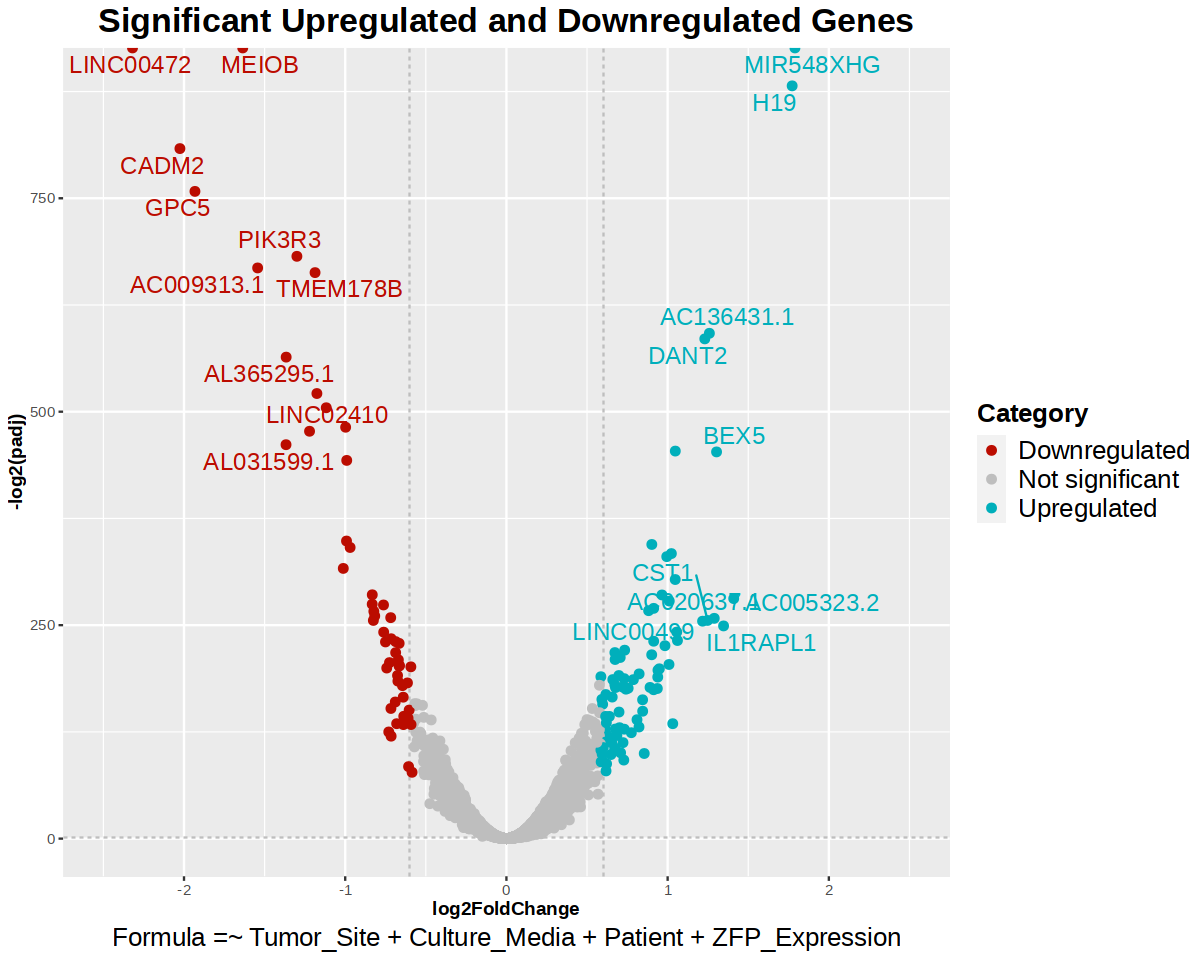

In [53]:
# Volcano plot
# Define significant genes based on the value of padj and log2FoldChange
res1_df$Category <- ifelse(res1_df$padj < 0.05 & abs(res1_df$log2FoldChange) > log2(1.5),
                            ifelse(res1_df$log2FoldChange > 0, "Upregulated", "Downregulated"),
                            "Not significant")

# Filter out rows with missing values
res1_df <- na.omit(res1_df)

# Customize the plot
custom_theme <- theme(
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold"),
    legend.text = element_text(size = 15),
    legend.title = element_text(size = 15, face = "bold"),
    axis.title.x = element_text(face="bold"),
    axis.title.y = element_text(face="bold"),
    plot.caption = element_text(hjust = 0.5, size = 15)
)

# Your existing ggplot code with modifications for theme settings
ggplot(data = res1_df, aes(x = log2FoldChange, y = -log2(padj), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.05), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-2.5, 2.5)) +
  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_1,
            aes(label = rownames(top_upregulated_genes_1)), 
            nudge_y = 0.3, color = "#00AFBB", size = 5) +
  
  geom_text_repel(data = top_downregulated_genes_1,
            aes(label = rownames(top_downregulated_genes_1)), 
            nudge_y = -0.3, color = "#bb0c00", size = 5) +

  labs(title = stringr::str_wrap("Significant Upregulated and Downregulated Genes", width=50), 
      caption = "Formula =~ Tumor_Site + Culture_Media + Patient + ZFP_Expression") +

  #ggtitle('Significant Upregulated and Downregulated Genes') + 
  custom_theme 

### Formula =~ Tumor_Site + Culture_Media + Patient + ZFP_Expression + ZFP_Expression:Culture_Media

In [74]:
# Load the DESeqResults object
dds_2 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/zfpexp_cmint_dds.rds")
resultsNames(dds_2)

dds_2$Tumor_Site<-relevel(dds_2$Tumor_Site,ref="Primary")

res_2 <- results(dds_2, list(c("Culture_MediaBASE.ZFP_ExpressionZFPKD", "Culture_MediaDedifferentiated.ZFP_ExpressionZFPKD", "Culture_MediaHISC.ZFP_ExpressionZFPKD")))     
                                          
res2_df <- as.data.frame(res_2)

[1] "Intercept"                                        
[2] "Tumor_Site_Primary_vs_Metastatic"                 
[3] "Culture_Media_Dedifferentiated_vs_BASE"           
[4] "Culture_Media_HISC_vs_BASE"                       
[5] "Patient_146_vs_125"                               
[6] "Culture_MediaBASE.ZFP_ExpressionZFPKD"            
[7] "Culture_MediaDedifferentiated.ZFP_ExpressionZFPKD"
[8] "Culture_MediaHISC.ZFP_ExpressionZFPKD"

In [87]:
res_2 <- results(dds_2, list(c("Culture_MediaHISC.ZFP_ExpressionZFPKD")))
res_2 <- results(dds_2, list(c("Culture_MediaBASE.ZFP_ExpressionZFPKD", "Culture_MediaDedifferentiated.ZFP_ExpressionZFPKD", "Culture_MediaHISC.ZFP_ExpressionZFPKD")))
res2_df <- as.data.frame(res_2)

In [88]:
levels(dds_2$ZFP_Expression) 
levels(dds_2$Culture_Media) 
levels(dds_2$Tumor_Site)

[1] "CTRL"  "ZFPKD"

[1] "BASE"             "Dedifferentiated" "HISC"

[1] "Primary"    "Metastatic"

In [89]:
# Define significant genes based on the value of padj and log2FoldChange
res2_df$Significant = res2_df$padj < 0.05 & abs(res2_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_2 = res2_df[res2_df$Significant, ]
significant_genes_df_2 <- significant_genes_df_2[complete.cases(significant_genes_df_2$padj), ]
significant_genes_df_2 <- na.omit(significant_genes_df_2)
significant_genes_df_2

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
ABHD12B,4.601475,-0.6136206,0.07042134,-8.713560,2.944783e-18,2.191598e-16,TRUE
AC003988.1,1.955810,0.6278229,0.08742950,7.180905,6.925137e-13,2.843531e-11,TRUE
AC004009.1,3.593820,0.8578675,0.06475676,13.247535,4.662649e-40,1.415251e-37,TRUE
AC004593.1,1.424957,-0.8959557,0.06013939,-14.897985,3.396675e-50,1.643141e-47,TRUE
AC004917.1,2.649018,1.0542576,0.08389058,12.567055,3.204395e-36,7.873656e-34,TRUE
AC005323.2,5.133696,0.9220485,0.10297007,8.954530,3.411871e-19,2.736568e-17,TRUE
AC007091.1,1.421405,-0.9229933,0.06542465,-14.107729,3.403635e-45,1.463563e-42,TRUE
AC019330.1,7.965680,-0.6912687,0.07369638,-9.379954,6.600139e-21,6.154828e-19,TRUE
AC020637.1,5.411538,1.5920753,0.09871314,16.128301,1.613996e-58,1.041028e-55,TRUE


In [90]:
# Find rows where row names start with "ZFP"
zfp_rows <- rownames(significant_genes_df_2)[grep("^ZFP", rownames(significant_genes_df_2))]

# Subset the significant_genes_df_2 based on the selected rows
zfp_genes_df <- significant_genes_df_2[zfp_rows, ]

# Print the resulting dataframe
zfp_genes_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
ZFP36L2,21.13463,-0.8252454,0.05695956,-14.48827,1.437214e-47,6.543549e-45,TRUE


In [46]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted_2 <- significant_genes_df_2[order(significant_genes_df_2$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes_2 <- head(significant_genes_sorted_2, 10)
top_upregulated_genes_2

# Top 10 downregulated genes
top_downregulated_genes_2 <- tail(significant_genes_sorted_2, 10)
top_downregulated_genes_2

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted_2, 10)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted_2, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC099520.1,120.945693,10.142891,0.2807066,36.13342,6.776501e-286,2.622506e-282,TRUE
IL1RAPL1,6.770188,7.192975,0.2660360,27.03760,5.344171e-161,9.191974e-158,TRUE
AC005323.2,5.133696,6.882562,0.2549998,26.99046,1.912548e-160,2.960624e-157,TRUE
H19,14.085598,5.709778,0.1915282,29.81169,2.756463e-195,7.111675e-192,TRUE
AC019117.1,4.631319,5.531053,0.2340112,23.63584,1.650455e-123,1.596815e-120,TRUE
ADAMTS19,13.739108,5.445188,0.2213861,24.59589,1.397936e-133,1.545718e-130,TRUE
LINC00499,2.740846,5.226316,0.2330606,22.42470,2.259977e-111,1.841287e-108,TRUE
MAGI2,10.919876,5.099681,0.2648931,19.25185,1.362141e-82,7.028646e-80,TRUE
TFPI,7.492686,4.974826,0.2015281,24.68551,1.530347e-134,1.822290e-131,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
PDZD7,1.523524,-3.463555,0.1386205,-24.98589,8.703694e-138,1.122776e-134,TRUE
MEIOB,2.151237,-3.532416,0.1743208,-20.26388,2.680068e-91,1.595671e-88,TRUE
GPC5,5.703841,-3.887742,0.2369098,-16.41022,1.616186e-60,5.686035e-58,TRUE
AL031599.1,2.343110,-4.041990,0.1890461,-21.38098,2.008761e-101,1.554781e-98,TRUE
KEL,1.474849,-4.079112,0.1461548,-27.90953,2.044501e-171,3.956109e-168,TRUE
LINC02410,1.659011,-4.571383,0.1587740,-28.79177,2.719667e-182,6.014349e-179,TRUE
AL365295.1,9.619564,-5.516712,0.1693209,-32.58139,7.525375e-233,2.329856e-229,TRUE
AC009313.1,2.269280,-5.996811,0.1654847,-36.23784,1.544320e-287,7.968693e-284,TRUE
LINC00472,67.601127,-6.402203,0.1517114,-42.19988,0.000000e+00,0.000000e+00,TRUE


Top 10 Upregulated Genes:
 [1] "AC099520.1" "IL1RAPL1"   "AC005323.2" "H19"        "AC019117.1"
 [6] "ADAMTS19"   "LINC00499"  "MAGI2"      "TFPI"       "AL592429.2"

Top 10 Downregulated Genes:
 [1] "PDZD7"      "MEIOB"      "GPC5"       "AL031599.1" "KEL"       
 [6] "LINC02410"  "AL365295.1" "AC009313.1" "LINC00472"  "CADM2"     


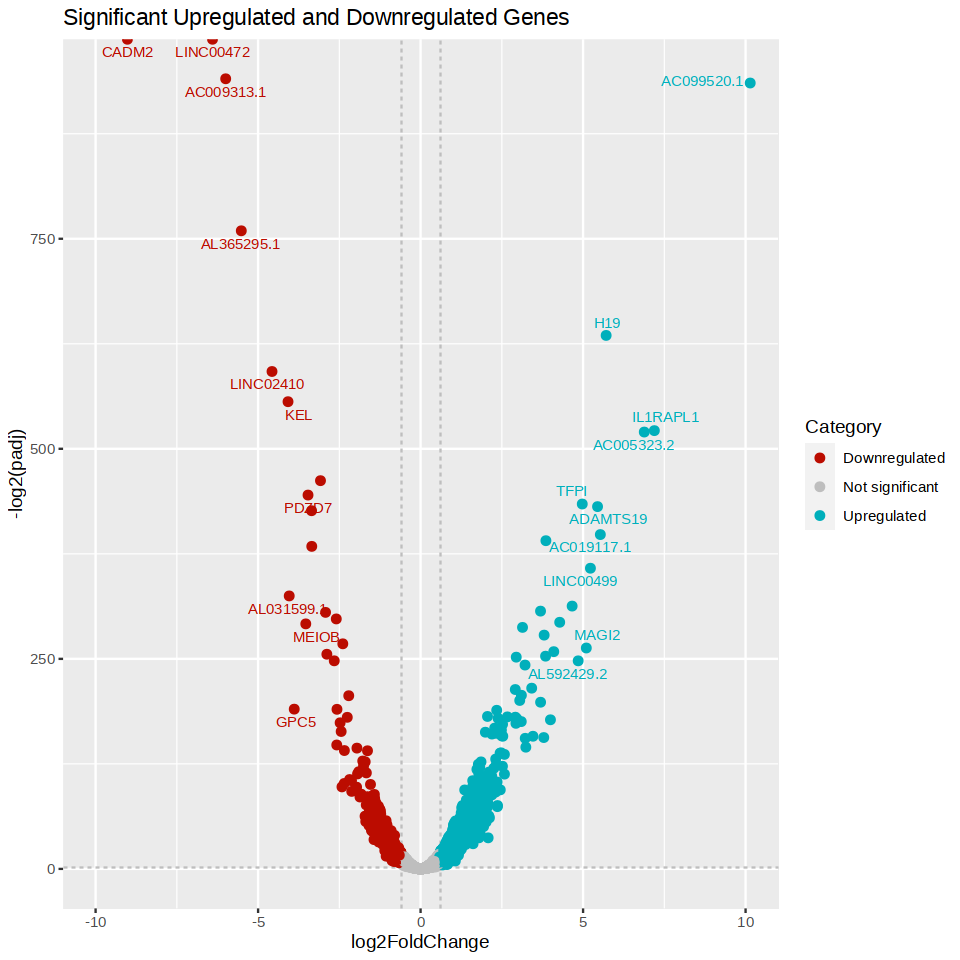

In [137]:
# Volcano plot
# Define significant genes based on the value of padj and log2FoldChange
res2_df$Category <- ifelse(res2_df$padj < 0.05 & abs(res2_df$log2FoldChange) > log2(1.5),
                            ifelse(res2_df$log2FoldChange > 0, "Upregulated", "Downregulated"),
                            "Not significant")

# Filter out rows with missing values
res2_df <- na.omit(res2_df)

# Your existing ggplot code with some modifications based on the categories
ggplot(data = res2_df, aes(x = log2FoldChange, y = -log2(padj), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.05), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-10, 10)) +
  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_2,
            aes(label = rownames(top_upregulated_genes_2)), 
            nudge_y = 0.3, color = "#00AFBB", size = 3) +
  
  geom_text_repel(data = top_downregulated_genes_2,
            aes(label = rownames(top_downregulated_genes_2)), 
            nudge_y = -0.3, color = "#bb0c00", size = 3) +
  ggtitle('Significant Upregulated and Downregulated Genes')

### Subset Patient 125: Formula =~ Culture_Media + ZFP_Expression

In [51]:
# Load the DESeqResults object
dds_3 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/ptn125_zfpexp_dds.rds")
resultsNames(dds_3)

res_3 <- results(dds_3, contrast = c("ZFP_Expression", "CTRL", "ZFPKD"))        
                                          
res3_df <- as.data.frame(res_3)

[1] "Intercept"                    "Culture_Media_HISC_vs_BASE"  
[3] "ZFP_Expression_ZFPKD_vs_CTRL"

In [65]:
# Define significant genes based on the value of padj and log2FoldChange
res3_df$Significant = res3_df$padj < 0.05 & abs(res3_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_3 = res3_df[res3_df$Significant, ]
significant_genes_df_3 <- significant_genes_df_3[complete.cases(significant_genes_df_3$padj), ]
significant_genes_df_3 <- na.omit(significant_genes_df_3)
significant_genes_df_3

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
ABCG2,1.498959,-0.6188404,0.08501432,-7.279249,3.356825e-13,6.127944e-12,TRUE
ABHD12B,2.329032,1.2953971,0.06168553,21.000016,6.556327e-98,2.494384e-95,TRUE
ABHD17B,24.725334,-0.9274506,0.05240907,-17.696375,4.471787e-70,1.169652e-67,TRUE
ABHD3,25.499823,-0.7749880,0.06224382,-12.450843,1.383753e-35,1.072409e-33,TRUE
AC000061.1,1.999029,0.6484655,0.06458284,10.040833,1.008195e-23,3.989878e-22,TRUE
AC002069.2,2.323563,0.6153499,0.07711257,7.979891,1.464630e-15,3.264700e-14,TRUE
AC002463.1,4.421971,0.5945155,0.05246440,11.331789,9.132038e-30,5.147149e-28,TRUE
AC004009.1,2.129469,-1.3511361,0.07779489,-17.367930,1.443407e-67,3.465782e-65,TRUE
AC007091.1,2.336121,2.0733715,0.08162999,25.399631,2.545679e-142,2.029270e-139,TRUE


In [66]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted_3 <- significant_genes_df_3[order(significant_genes_df_3$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes_3 <- head(significant_genes_sorted_3, 10)
top_upregulated_genes_3

# Top 10 downregulated genes
top_downregulated_genes_3 <- tail(significant_genes_sorted_3, 10)
top_downregulated_genes_3

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted_3, 10)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted_3, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
PIK3R3,51.659137,3.456775,0.06370131,54.26538,0.000000e+00,0.000000e+00,TRUE
MEIOB,4.635988,3.179291,0.06556790,48.48853,0.000000e+00,0.000000e+00,TRUE
LINC00472,51.250676,2.893676,0.07527944,38.43913,0.000000e+00,0.000000e+00,TRUE
AGMO,6.244595,2.446865,0.07310931,33.46858,1.381363e-245,2.569335e-242,TRUE
AC019330.1,12.486783,2.235609,0.08164024,27.38366,4.292805e-165,3.782187e-162,TRUE
AC007091.1,2.336121,2.073372,0.08162999,25.39963,2.545679e-142,2.029270e-139,TRUE
TMEM178B,7.251892,2.000342,0.06449176,31.01702,3.178280e-211,4.836764e-208,TRUE
CPNE4,3.211124,1.922275,0.06667636,28.82994,9.043206e-183,8.904899e-180,TRUE
FAHD1,12.289641,1.838245,0.06236593,29.47515,5.996436e-191,6.692023e-188,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC136431.1,17.996820,-2.072126,0.06806902,-30.44155,1.549852e-203,1.995732e-200,TRUE
CNTNAP2,6.266555,-2.360834,0.07708116,-30.62790,5.205517e-206,7.261697e-203,TRUE
IGFBP2,4.110280,-2.378172,0.08698281,-27.34072,1.392390e-164,1.165430e-161,TRUE
DANT2,7.286243,-2.408326,0.07126141,-33.79565,2.284541e-250,4.780401e-247,TRUE
IGF2BP1,4.063310,-2.496233,0.08259626,-30.22210,1.213809e-200,1.451368e-197,TRUE
H19,33.242470,-2.575591,0.08294952,-31.05010,1.137325e-211,1.903883e-208,TRUE
DIAPH2-AS1,6.950827,-3.082895,0.08974774,-34.35067,1.376114e-258,3.290877e-255,TRUE
MIR548XHG,19.153689,-3.165617,0.07142465,-44.32107,0.000000e+00,0.000000e+00,TRUE
BEX5,12.152372,-3.462249,0.09633108,-35.94113,6.962549e-283,1.942551e-279,TRUE


Top 10 Upregulated Genes:
 [1] "PIK3R3"     "MEIOB"      "LINC00472"  "AGMO"       "AC019330.1"
 [6] "AC007091.1" "TMEM178B"   "CPNE4"      "FAHD1"      "AC092894.1"

Top 10 Downregulated Genes:
 [1] "AC136431.1" "CNTNAP2"    "IGFBP2"     "DANT2"      "IGF2BP1"   
 [6] "H19"        "DIAPH2-AS1" "MIR548XHG"  "BEX5"       "DIAPH2"    


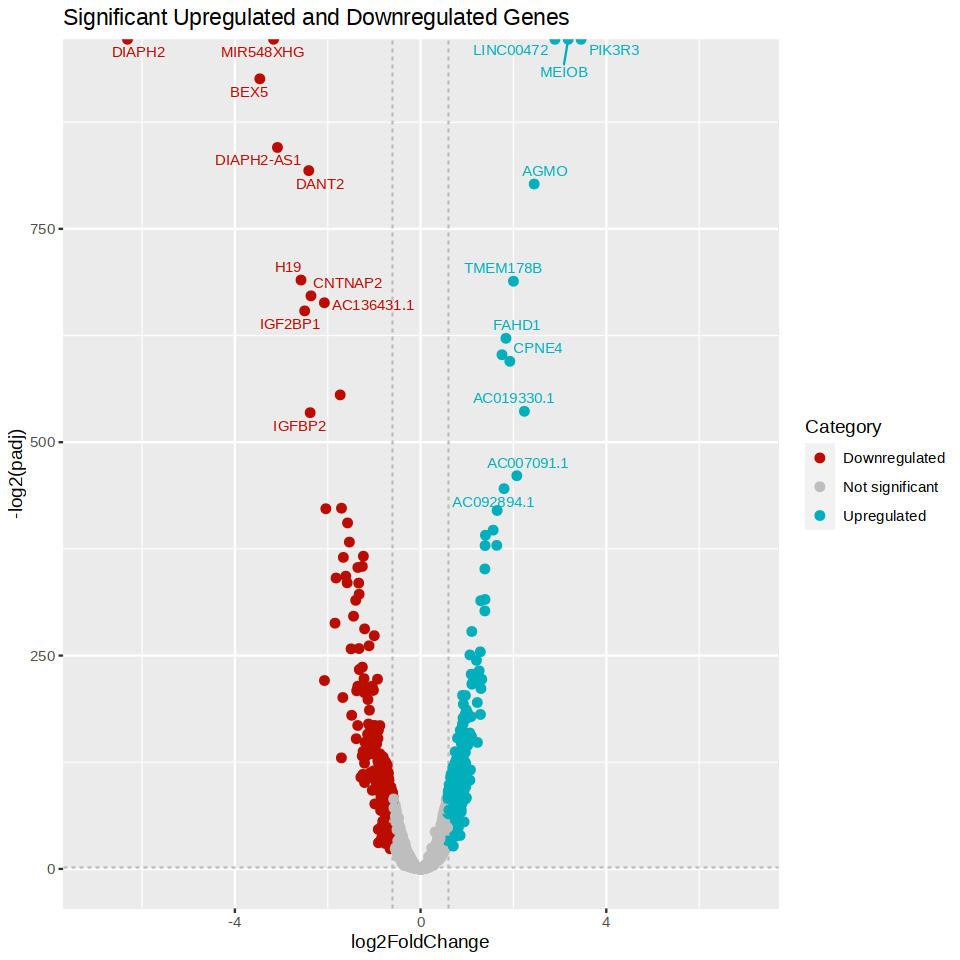

In [145]:
# Volcano plot
# Define significant genes based on the value of padj and log2FoldChange
res3_df$Category <- ifelse(res3_df$padj < 0.05 & abs(res3_df$log2FoldChange) > log2(1.5),
                            ifelse(res3_df$log2FoldChange > 0, "Upregulated", "Downregulated"),
                            "Not significant")

# Filter out rows with missing values
res3_df <- na.omit(res3_df)

# Your existing ggplot code with some modifications based on the categories
ggplot(data = res3_df, aes(x = log2FoldChange, y = -log2(padj), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.05), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-7, 7)) +
  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_3,
            aes(label = rownames(top_upregulated_genes_3)), 
            nudge_y = 0.3, color = "#00AFBB", size = 3) +
  
  geom_text_repel(data = top_downregulated_genes_3,
            aes(label = rownames(top_downregulated_genes_3)), 
            nudge_y = -0.3, color = "#bb0c00", size = 3) +
  ggtitle('Significant Upregulated and Downregulated Genes')

### Subset Patient 125: Formula =~ Culture_Media + ZFP_Expression + ZFP_Expression:Culture_Media

In [77]:
# Load the DESeqResults object
dds_4 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/ptn125_zfpexp_cmint_dds.rds")
resultsNames(dds_4)

res_4 <- results(dds_4, contrast = list(c("Culture_MediaHISC.ZFP_ExpressionZFPKD")))     
                                          
res4_df <- as.data.frame(res_4)

[1] "Intercept"                            
[2] "Culture_Media_HISC_vs_BASE"           
[3] "ZFP_Expression_ZFPKD_vs_CTRL"         
[4] "Culture_MediaHISC.ZFP_ExpressionZFPKD"

In [78]:
# Define significant genes based on the value of padj and log2FoldChange
res4_df$Significant = res4_df$padj < 0.05 & abs(res4_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_4 = res4_df[res4_df$Significant, ]
significant_genes_df_4 <- significant_genes_df_4[complete.cases(significant_genes_df_4$padj), ]
significant_genes_df_4 <- na.omit(significant_genes_df_4)
significant_genes_df_4

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
A1CF,2.450738,0.8618364,0.1434971,6.005949,1.902154e-09,6.856065e-08,TRUE
ABAT,8.558131,1.5579798,0.1416620,10.997864,3.912891e-28,2.003670e-25,TRUE
ABCA1,8.002145,1.2141057,0.1556083,7.802321,6.077879e-15,6.098412e-13,TRUE
ABCB1,41.586433,-0.7375948,0.1267751,-5.818136,5.950763e-09,1.892266e-07,TRUE
ABCC1,17.332071,0.5962195,0.1113054,5.356609,8.479817e-08,1.973751e-06,TRUE
ABCG1,1.910331,0.5969970,0.1390149,4.294483,1.751007e-05,1.880149e-04,TRUE
ABCG2,1.498959,-0.8209735,0.1716824,-4.781931,1.736190e-06,2.699729e-05,TRUE
ABHD12B,2.329032,0.6707073,0.1276754,5.253224,1.494596e-07,3.170678e-06,TRUE
ABR,19.665870,0.7874365,0.1148613,6.855544,7.104148e-12,4.341424e-10,TRUE


In [79]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted_4 <- significant_genes_df_4[order(significant_genes_df_4$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes_4 <- head(significant_genes_sorted_4, 10)
top_upregulated_genes_4

# Top 10 downregulated genes
top_downregulated_genes_4 <- tail(significant_genes_sorted_4, 10)
top_downregulated_genes_4

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted_4, 10)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted_4, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
BEX5,12.152372,4.088282,0.2075598,19.696882,2.293139e-86,3.405311e-82,TRUE
NAV3,4.540679,2.568375,0.1866840,13.757871,4.567842e-43,1.695811e-39,TRUE
FAM155A,4.914981,2.040832,0.2305400,8.852399,8.565819e-19,1.610157e-16,TRUE
CLSTN2,10.586627,2.030567,0.2134245,9.514217,1.830863e-21,4.855058e-19,TRUE
AC092894.1,2.580422,1.940853,0.1446568,13.416947,4.811263e-41,1.190788e-37,TRUE
DKK4,4.601294,1.913335,0.2494567,7.670009,1.719842e-14,1.596229e-12,TRUE
SLC26A3,21.590620,1.899595,0.2299628,8.260443,1.451328e-16,1.766576e-14,TRUE
MYL3,5.529473,1.889118,0.1673402,11.289087,1.485722e-29,9.592596e-27,TRUE
GNG4,13.344152,1.865860,0.1617160,11.537883,8.499167e-31,6.642770e-28,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
LINC02331,6.698295,-1.676897,0.1615139,-10.382371,2.982728e-25,1.165619e-22,TRUE
SLC1A3,2.442812,-1.688330,0.1889207,-8.936711,4.009268e-19,8.045626e-17,TRUE
AC068413.1,4.270658,-1.953172,0.1978198,-9.873493,5.424232e-23,1.789997e-20,TRUE
CYP26A1,3.131689,-1.982826,0.1658841,-11.953082,6.256121e-33,6.193560e-30,TRUE
MALRD1,6.007849,-1.984039,0.1741808,-11.390685,4.653166e-30,3.140887e-27,TRUE
PLXDC2,2.369460,-2.102642,0.1757970,-11.960626,5.712958e-33,6.059816e-30,TRUE
KCNMA1,1.966257,-2.169355,0.1788353,-12.130459,7.284015e-34,9.013969e-31,TRUE
DIAPH2-AS1,6.950827,-2.294520,0.1810966,-12.670147,8.655252e-37,1.285305e-33,TRUE
OAT,47.225774,-2.305365,0.1575168,-14.635675,1.663162e-48,1.234898e-44,TRUE


Top 10 Upregulated Genes:
 [1] "BEX5"       "NAV3"       "FAM155A"    "CLSTN2"     "AC092894.1"
 [6] "DKK4"       "SLC26A3"    "MYL3"       "GNG4"       "AGMO"      

Top 10 Downregulated Genes:
 [1] "LINC02331"  "SLC1A3"     "AC068413.1" "CYP26A1"    "MALRD1"    
 [6] "PLXDC2"     "KCNMA1"     "DIAPH2-AS1" "OAT"        "SLC2A3"    


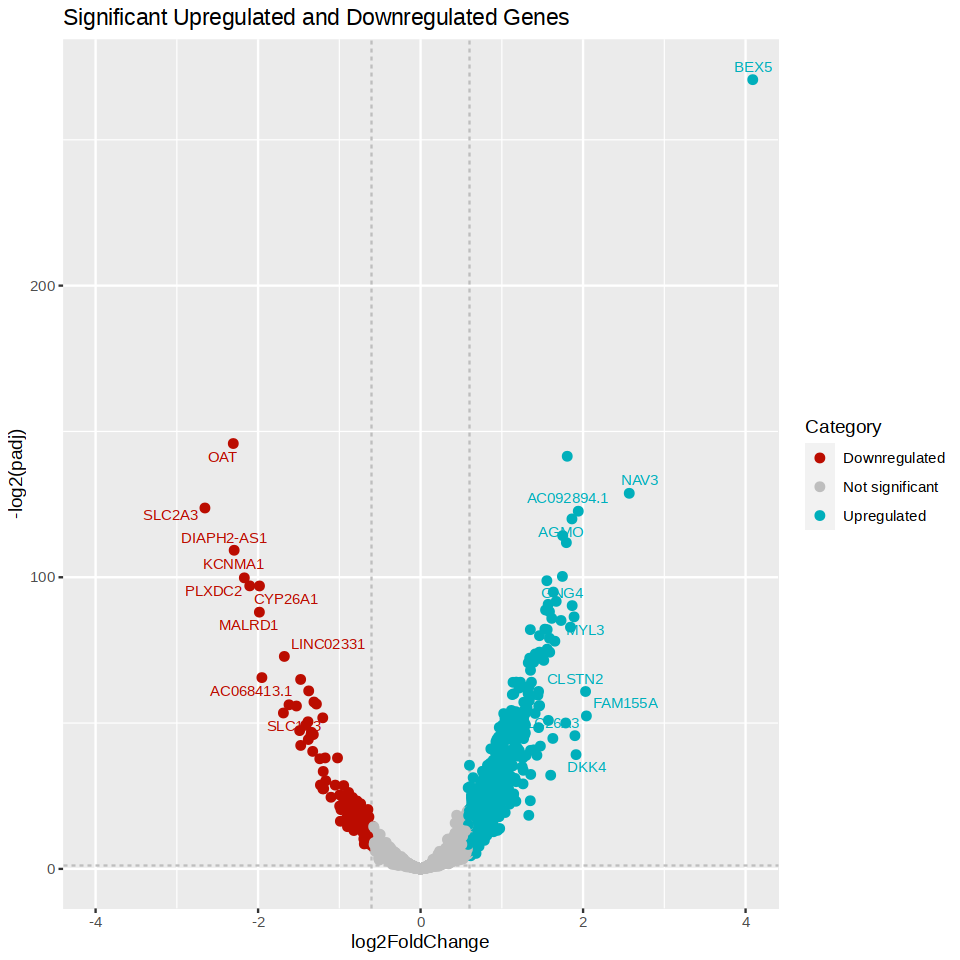

In [147]:
# Volcano plot
# Define significant genes based on the value of padj and log2FoldChange
res4_df$Category <- ifelse(res4_df$padj < 0.05 & abs(res4_df$log2FoldChange) > log2(1.5),
                            ifelse(res4_df$log2FoldChange > 0, "Upregulated", "Downregulated"),
                            "Not significant")

# Filter out rows with missing values
res4_df <- na.omit(res4_df)

# Your existing ggplot code with some modifications based on the categories
ggplot(data = res4_df, aes(x = log2FoldChange, y = -log2(padj), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.05), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-4, 4)) +
  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_4,
            aes(label = rownames(top_upregulated_genes_4)), 
            nudge_y = 0.3, color = "#00AFBB", size = 3) +
  
  geom_text_repel(data = top_downregulated_genes_4,
            aes(label = rownames(top_downregulated_genes_4)), 
            nudge_y = -0.3, color = "#bb0c00", size = 3) +
  ggtitle('Significant Upregulated and Downregulated Genes')

### Subset Patient 146: Formula =~ Tumor_Site + Culture_Media + ZFP_Expression

In [5]:
# Load the DESeqResults object
dds_5 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/ptn146_zfpexp_dds.rds")
resultsNames(dds_5)

#res_5 <- results(dds_5, contrast = c("ZFP_Expression", "CTRL", "ZFPKD"))        
                                          
#res5_df <- as.data.frame(res_5)

Warning message in gzfile(file, "rb"):
“cannot open compressed file '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/ptn146_zfpexp_dds.rds', probable reason 'No such file or directory'”


ERROR: Error in gzfile(file, "rb"): cannot open the connection


In [83]:
# Define significant genes based on the value of padj and log2FoldChange
res5_df$Significant = res5_df$padj < 0.05 & abs(res5_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_5 = res5_df[res5_df$Significant, ]
significant_genes_df_5 <- significant_genes_df_5[complete.cases(significant_genes_df_5$padj), ]
significant_genes_df_5 <- na.omit(significant_genes_df_5)
significant_genes_df_5

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC003988.1,2.360688,-1.2743531,0.07567982,-16.83874,1.269048e-63,4.259242e-61,TRUE
AC004009.1,4.227672,-0.8720195,0.05665118,-15.39279,1.829823e-53,4.754589e-51,TRUE
AC004594.1,1.584166,0.6240527,0.04514107,13.82450,1.813678e-43,3.075616e-41,TRUE
AC004917.1,3.222626,-1.5699174,0.07472689,-21.00873,5.456966e-98,4.395586e-95,TRUE
AC005323.1,1.425174,-0.6467063,0.06369340,-10.15343,3.199256e-24,2.053387e-22,TRUE
AC005323.2,6.899057,-2.1028568,0.09042617,-23.25496,1.267325e-119,1.361107e-116,TRUE
AC007100.1,2.174188,-0.7382328,0.05877433,-12.56046,3.482842e-36,3.951309e-34,TRUE
AC008591.1,2.872957,-1.1600158,0.06474888,-17.91561,8.908233e-72,3.986434e-69,TRUE
AC009313.1,2.782408,2.0078889,0.06196668,32.40272,2.513102e-230,1.012152e-226,TRUE


In [85]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted_5 <- significant_genes_df_5[order(significant_genes_df_5$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes_5 <- head(significant_genes_sorted_5, 10)
top_upregulated_genes_5

# Top 10 downregulated genes
top_downregulated_genes_5 <- tail(significant_genes_sorted_5, 10)
top_downregulated_genes_5

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted_5, 10)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted_5, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
CADM2,9.131687,2.820971,0.07540088,37.41298,2.404052e-306,1.936464e-302,TRUE
GPC5,7.636580,2.665976,0.07432955,35.86697,1.000297e-281,5.371594e-278,TRUE
LINC00472,74.634123,2.043120,0.04793285,42.62464,0.000000e+00,0.000000e+00,TRUE
AC009313.1,2.782408,2.007889,0.06196668,32.40272,2.513102e-230,1.012152e-226,TRUE
AL365295.1,11.310205,1.952905,0.06030485,32.38387,4.629717e-230,1.491695e-226,TRUE
AL031599.1,2.863034,1.795682,0.06693881,26.82573,1.619530e-158,3.261328e-155,TRUE
LINC02410,1.934890,1.572234,0.05751780,27.33473,1.640252e-164,3.774922e-161,TRUE
ACOXL,2.139464,1.548953,0.05338579,29.01433,4.339737e-185,1.165220e-181,TRUE
KEL,1.663395,1.274005,0.05407255,23.56103,9.675810e-123,1.113409e-119,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
S100A4,17.526847,-1.475128,0.06107820,-24.15146,7.206970e-129,1.055494e-125,TRUE
CKB,120.075658,-1.537995,0.07017553,-21.91640,1.812381e-106,1.717497e-103,TRUE
AC004917.1,3.222626,-1.569917,0.07472689,-21.00873,5.456966e-98,4.395586e-95,TRUE
LINC00499,3.441273,-1.643969,0.08202423,-20.04248,2.347522e-89,1.575774e-86,TRUE
PIK3C2G,3.942682,-1.650408,0.07643421,-21.59252,2.111627e-103,1.790437e-100,TRUE
ADAMTS19,17.038550,-1.662118,0.08015896,-20.73527,1.665123e-95,1.277387e-92,TRUE
AC020637.1,7.292114,-1.915161,0.08636093,-22.17625,5.823499e-109,5.863536e-106,TRUE
AC099520.1,121.192528,-2.065599,0.10316135,-20.02299,3.472188e-89,2.237478e-86,TRUE
AC005323.2,6.899057,-2.102857,0.09042617,-23.25496,1.267325e-119,1.361107e-116,TRUE


Top 10 Upregulated Genes:
 [1] "CADM2"      "GPC5"       "LINC00472"  "AC009313.1" "AL365295.1"
 [6] "AL031599.1" "LINC02410"  "ACOXL"      "KEL"        "SCHLAP1"   

Top 10 Downregulated Genes:
 [1] "S100A4"     "CKB"        "AC004917.1" "LINC00499"  "PIK3C2G"   
 [6] "ADAMTS19"   "AC020637.1" "AC099520.1" "AC005323.2" "IL1RAPL1"  


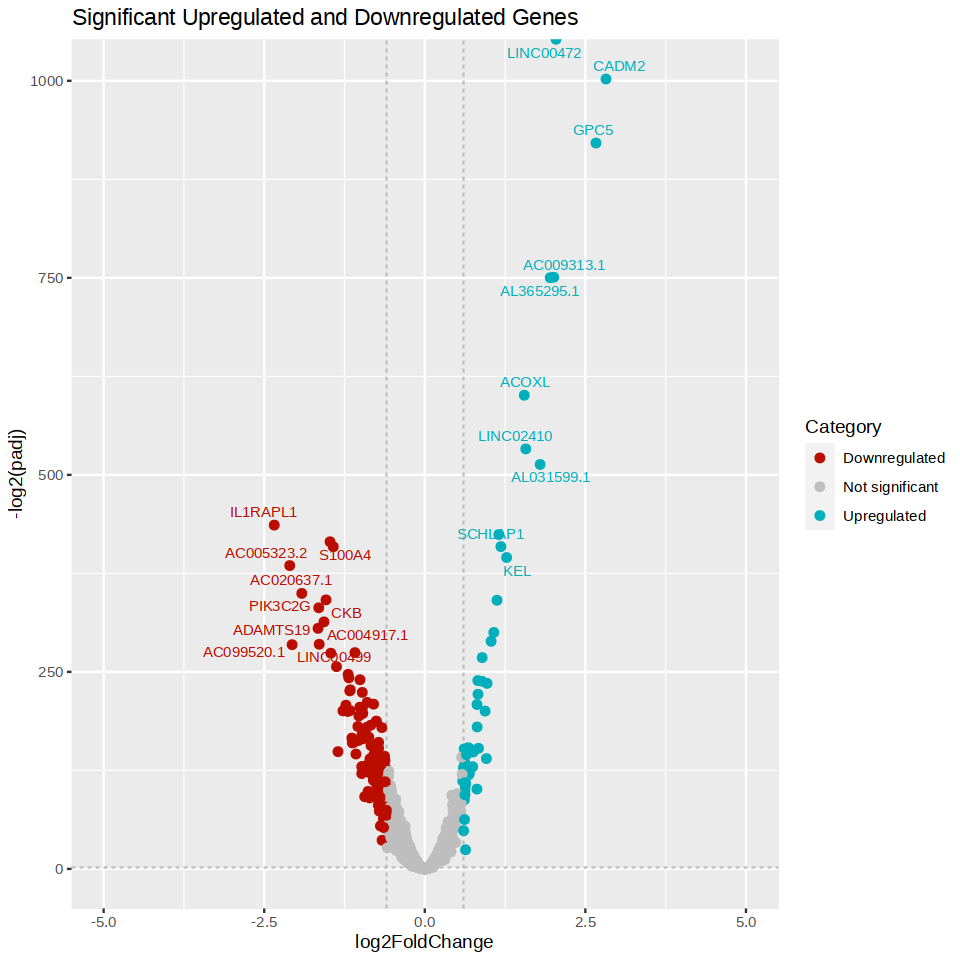

In [149]:
# Volcano plot
# Define significant genes based on the value of padj and log2FoldChange
res5_df$Category <- ifelse(res5_df$padj < 0.05 & abs(res5_df$log2FoldChange) > log2(1.5),
                            ifelse(res5_df$log2FoldChange > 0, "Upregulated", "Downregulated"),
                            "Not significant")

# Filter out rows with missing values
res5_df <- na.omit(res5_df)

# Your existing ggplot code with some modifications based on the categories
ggplot(data = res5_df, aes(x = log2FoldChange, y = -log2(padj), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.05), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-5, 5)) +
  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_5,
            aes(label = rownames(top_upregulated_genes_5)), 
            nudge_y = 0.3, color = "#00AFBB", size = 3) +
  
  geom_text_repel(data = top_downregulated_genes_5,
            aes(label = rownames(top_downregulated_genes_5)), 
            nudge_y = -0.3, color = "#bb0c00", size = 3) +
  ggtitle('Significant Upregulated and Downregulated Genes')

### Subset Patient 146: Formula =~ Tumor_Site + Culture_Media + ZFP_Expression:Culture_Media

In [8]:
# Load the DESeqResults object
dds_6 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/ptn146_zfpexp_cmint_dds.rds")
resultsNames(dds_6)

res_6 <- results(dds_6, contrast = list(c("Culture_MediaDedifferentiated.ZFP_ExpressionZFPKD", "Culture_MediaHISC.ZFP_ExpressionZFPKD")))      
                                          
res6_df <- as.data.frame(res_6)

Warning message in gzfile(file, "rb"):
“cannot open compressed file '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/ptn146_zfpexp_cmint_dds.rds', probable reason 'No such file or directory'”


ERROR: Error in gzfile(file, "rb"): cannot open the connection


In [98]:
# Define significant genes based on the value of padj and log2FoldChange
res6_df$Significant = res6_df$padj < 0.05 & abs(res6_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_6 = res6_df[res6_df$Significant, ]
significant_genes_df_6 <- significant_genes_df_6[complete.cases(significant_genes_df_6$padj), ]
significant_genes_df_6 <- na.omit(significant_genes_df_6)
significant_genes_df_6

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AADACL2-AS1,1.516697,-1.4953816,0.2286396,-6.540343,6.137785e-11,7.796135e-09,TRUE
AAMDC,6.592812,0.9386606,0.1668323,5.626373,1.840377e-08,1.432738e-06,TRUE
ABCA13,1.630048,-0.9084026,0.2860634,-3.175529,1.495635e-03,1.721184e-02,TRUE
ABCA5,2.923863,0.8044780,0.1804786,4.457470,8.293262e-06,2.817843e-04,TRUE
ABCB8,2.451867,-0.6908876,0.1760149,-3.925166,8.667013e-05,1.999887e-03,TRUE
ABCC1,12.074163,-0.6692961,0.1736401,-3.854502,1.159654e-04,2.513354e-03,TRUE
ABCF2,4.547884,-0.6467052,0.2089230,-3.095424,1.965319e-03,2.104858e-02,TRUE
ABL2,11.773969,-0.6872948,0.1706763,-4.026889,5.651961e-05,1.424408e-03,TRUE
ABTB2,3.449643,0.6093195,0.2019989,3.016449,2.557541e-03,2.520968e-02,TRUE


In [99]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted_6 <- significant_genes_df_6[order(significant_genes_df_6$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes_6 <- head(significant_genes_sorted_6, 10)
top_upregulated_genes_6

# Top 10 downregulated genes
top_downregulated_genes_6 <- tail(significant_genes_sorted_6, 10)
top_downregulated_genes_6

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted_6, 10)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted_6, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC099520.1,121.192528,7.766647,0.4237384,18.328874,4.868842e-75,6.617243e-71,TRUE
AL031599.1,2.863034,4.449598,0.2692729,16.524493,2.444882e-61,1.661420e-57,TRUE
WFDC2,13.827473,4.316291,0.3213635,13.431179,3.970382e-41,1.798715e-37,TRUE
IL1RAPL1,9.120773,3.514761,0.3933097,8.936369,4.021678e-19,2.351923e-16,TRUE
AC005323.2,6.899057,3.304970,0.3783866,8.734372,2.450125e-18,1.040614e-15,TRUE
BMX,1.451617,3.135795,0.2385378,13.145905,1.796438e-39,6.103847e-36,TRUE
TFF3,85.505529,3.119411,0.3244956,9.613106,7.039271e-22,5.979421e-19,TRUE
TFPI,4.452323,2.837166,0.2540224,11.168959,5.785470e-29,7.863033e-26,TRUE
NR3C1,1.516325,2.585333,0.2299070,11.245124,2.447514e-29,3.696018e-26,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
TTC29,1.374515,-2.234832,0.2274208,-9.826857,8.626889e-23,9.019081e-20,TRUE
AC108734.4,2.962382,-2.355955,0.3018726,-7.804469,5.975254e-15,1.503883e-12,TRUE
KCNH7,3.128646,-2.377330,0.3183421,-7.467847,8.151749e-14,1.678643e-11,TRUE
PKN2-AS1,4.301070,-2.473221,0.3007043,-8.224761,1.955807e-16,6.645344e-14,TRUE
LRRTM4,4.426093,-2.529354,0.2898587,-8.726163,2.634587e-18,1.085051e-15,TRUE
CXXC4,2.061225,-2.537028,0.2200189,-11.530953,9.211863e-31,1.564980e-27,TRUE
AL136456.1,2.740535,-2.564457,0.2870829,-8.932811,4.153201e-19,2.351923e-16,TRUE
SKAP1,4.279660,-3.306867,0.2667511,-12.396827,2.718791e-35,7.390219e-32,TRUE
APOA2,128.538622,-3.354994,0.2773335,-12.097325,1.091083e-33,2.471486e-30,TRUE


Top 10 Upregulated Genes:
 [1] "AC099520.1" "AL031599.1" "WFDC2"      "IL1RAPL1"   "AC005323.2"
 [6] "BMX"        "TFF3"       "TFPI"       "NR3C1"      "LTB"       

Top 10 Downregulated Genes:
 [1] "TTC29"      "AC108734.4" "KCNH7"      "PKN2-AS1"   "LRRTM4"    
 [6] "CXXC4"      "AL136456.1" "SKAP1"      "APOA2"      "SMOC2"     


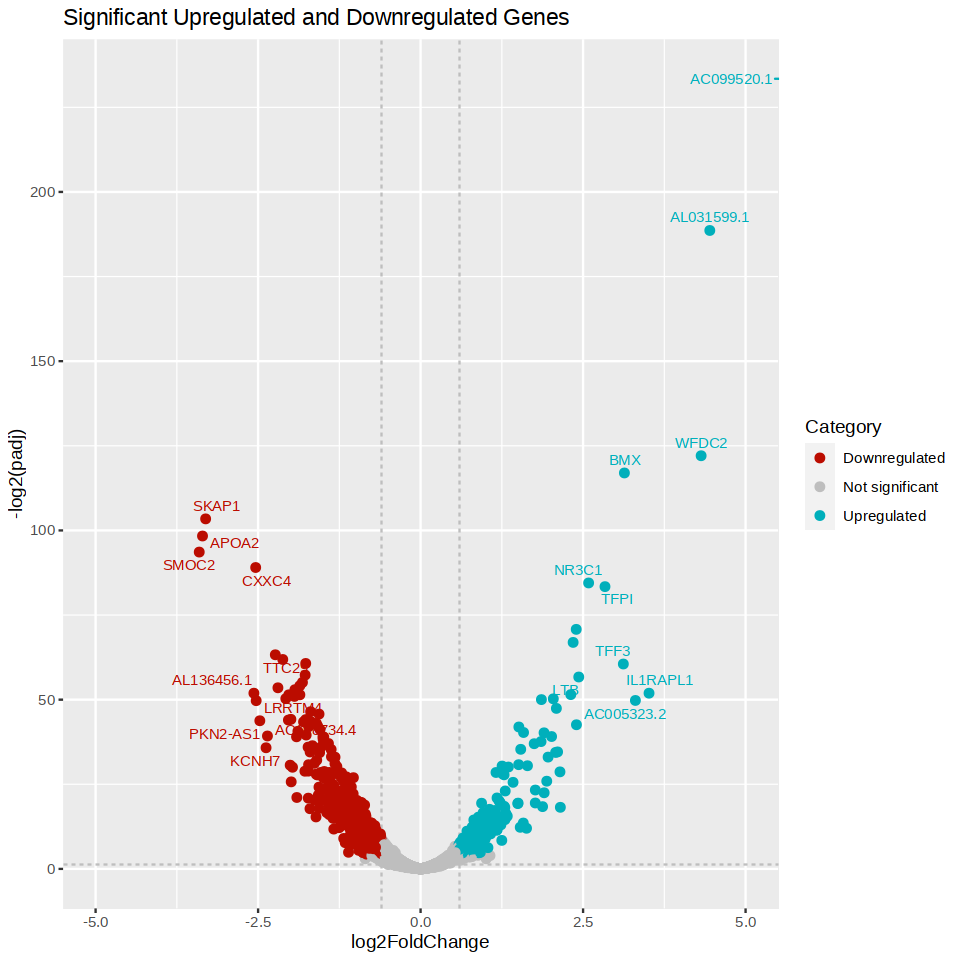

In [151]:
# Volcano plot
# Define significant genes based on the value of padj and log2FoldChange
res6_df$Category <- ifelse(res6_df$padj < 0.05 & abs(res6_df$log2FoldChange) > log2(1.5),
                            ifelse(res6_df$log2FoldChange > 0, "Upregulated", "Downregulated"),
                            "Not significant")

# Filter out rows with missing values
res6_df <- na.omit(res6_df)

# Your existing ggplot code with some modifications based on the categories
ggplot(data = res6_df, aes(x = log2FoldChange, y = -log2(padj), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.05), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-5, 5)) +
  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_6,
            aes(label = rownames(top_upregulated_genes_6)), 
            nudge_y = 0.3, color = "#00AFBB", size = 3) +
  
  geom_text_repel(data = top_downregulated_genes_6,
            aes(label = rownames(top_downregulated_genes_6)), 
            nudge_y = -0.3, color = "#bb0c00", size = 3) +
  ggtitle('Significant Upregulated and Downregulated Genes')

### Subset Patient 146: Formula =~ Tumor_Site + Culture_Media + ZFP_Expression:Tumor_Site

In [100]:
# Load the DESeqResults object
dds_7 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/ptn146_zfpexp_tsint_dds.rds")
resultsNames(dds_7)

res_7 <- results(dds_7)#, contrast = list(c("Culture_MediaDedifferentiated.ZFP_ExpressionZFPKD", "Culture_MediaHISC.ZFP_ExpressionZFPKD")))      
                                          
res7_df <- as.data.frame(res_7)

[1] "Intercept"                             
[2] "Tumor_Site_Primary_vs_Metastatic"      
[3] "Culture_Media_Dedifferentiated_vs_BASE"
[4] "Culture_Media_HISC_vs_BASE"            
[5] "ZFP_Expression_ZFPKD_vs_CTRL"          
[6] "Tumor_SitePrimary.ZFP_ExpressionZFPKD"

In [101]:
# Define significant genes based on the value of padj and log2FoldChange
res7_df$Significant = res7_df$padj < 0.05 & abs(res7_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_7 = res7_df[res7_df$Significant, ]
significant_genes_df_7 <- significant_genes_df_7[complete.cases(significant_genes_df_7$padj), ]
significant_genes_df_7 <- na.omit(significant_genes_df_7)
significant_genes_df_7

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AADACL2-AS1,1.516697,0.7811692,0.10428173,7.490950,6.837672e-14,4.565555e-12,TRUE
ABHD12B,5.591493,-0.7081784,0.10992104,-6.442611,1.174357e-10,5.496759e-09,TRUE
AC002069.2,2.410758,0.6217205,0.11265333,5.518882,3.411628e-08,1.118930e-06,TRUE
AC003988.1,2.360688,-2.3663301,0.15013681,-15.761158,5.756812e-56,2.822201e-53,TRUE
AC004009.1,4.227672,0.8261151,0.11714303,7.052192,1.761205e-12,1.022103e-10,TRUE
AC004593.1,1.508370,0.8643873,0.10955334,7.890104,3.019342e-15,2.373305e-13,TRUE
AC004594.1,1.584166,-0.8859509,0.09318572,-9.507368,1.955477e-21,2.698414e-19,TRUE
AC004917.1,3.222626,2.7826814,0.14915779,18.655957,1.129613e-77,9.565259e-75,TRUE
AC005050.3,1.274497,0.8056911,0.11327981,7.112398,1.140437e-12,6.765989e-11,TRUE


In [102]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted_7 <- significant_genes_df_7[order(significant_genes_df_7$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes_7 <- head(significant_genes_sorted_7, 10)
top_upregulated_genes_7

# Top 10 downregulated genes
top_downregulated_genes_7 <- tail(significant_genes_sorted_7, 10)
top_downregulated_genes_7

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted_7, 10)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted_7, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
ROBO2,26.160043,5.706916,0.1712675,33.32165,1.875634e-243,1.164706e-239,TRUE
CADM2,9.131687,5.104741,0.1426761,35.77853,2.382675e-280,2.219343e-276,TRUE
SOX5,8.437233,3.561414,0.1429905,24.90666,6.302151e-137,1.467535e-133,TRUE
PIK3C2G,3.942682,3.146796,0.1515893,20.75869,1.023107e-95,1.058859e-92,TRUE
AC009313.1,2.782408,3.095968,0.1242161,24.92405,4.083180e-137,1.086651e-133,TRUE
AL031599.1,2.863034,3.062418,0.1356786,22.57111,8.332409e-113,1.194034e-109,TRUE
AC004917.1,3.222626,2.782681,0.1491578,18.65596,1.129613e-77,9.565259e-75,TRUE
AL365295.1,11.310205,2.664605,0.1129806,23.58462,5.544205e-123,1.032830e-119,TRUE
KCNH7,3.128646,2.663495,0.1485898,17.92516,7.503826e-72,5.376491e-69,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
CNOT6L,20.414284,-2.476157,0.1118259,-22.14296,1.219641e-108,1.514713e-105,TRUE
SEMA3A,28.821103,-2.796607,0.1229977,-22.73706,1.927103e-114,2.991667e-111,TRUE
ACOXL,2.139464,-2.830688,0.1091333,-25.93790,2.489739e-148,7.730225e-145,TRUE
LINC00499,3.441273,-2.964252,0.1614550,-18.35962,2.765358e-75,2.146494e-72,TRUE
AC020637.1,7.292114,-3.570323,0.1664507,-21.44974,4.592376e-102,5.032434e-99,TRUE
IL1RAPL1,9.120773,-4.094149,0.1823415,-22.45320,1.190921e-111,1.584690e-108,TRUE
AC005323.2,6.899057,-4.185147,0.1768088,-23.67047,7.266603e-124,1.504106e-120,TRUE
ADAMTS19,17.038550,-4.491913,0.1479508,-30.36086,1.806021e-202,6.728871e-199,TRUE
GPC5,7.636580,-4.494976,0.1398256,-32.14702,9.720013e-227,4.526853e-223,TRUE


Top 10 Upregulated Genes:
 [1] "ROBO2"      "CADM2"      "SOX5"       "PIK3C2G"    "AC009313.1"
 [6] "AL031599.1" "AC004917.1" "AL365295.1" "KCNH7"      "LINC02410" 

Top 10 Downregulated Genes:
 [1] "CNOT6L"     "SEMA3A"     "ACOXL"      "LINC00499"  "AC020637.1"
 [6] "IL1RAPL1"   "AC005323.2" "ADAMTS19"   "GPC5"       "AC099520.1"


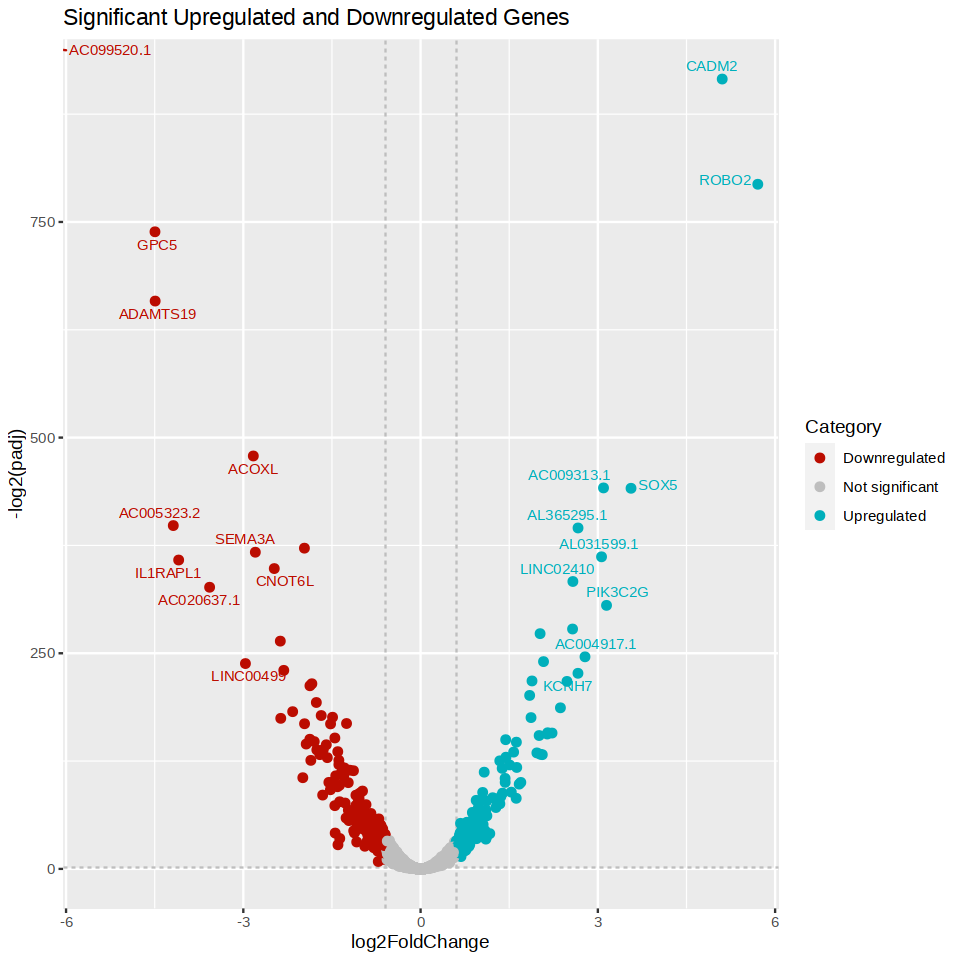

In [153]:
# Volcano plot
# Define significant genes based on the value of padj and log2FoldChange
res7_df$Category <- ifelse(res7_df$padj < 0.05 & abs(res7_df$log2FoldChange) > log2(1.5),
                            ifelse(res7_df$log2FoldChange > 0, "Upregulated", "Downregulated"),
                            "Not significant")

# Filter out rows with missing values
res7_df <- na.omit(res7_df)

# Your existing ggplot code with some modifications based on the categories
ggplot(data = res7_df, aes(x = log2FoldChange, y = -log2(padj), col = Category)) +
  geom_vline(xintercept = c(-0.6, 0.6), col = "gray", linetype = 'dashed') +
  geom_hline(yintercept = -log10(0.05), col = "gray", linetype = 'dashed') + 
  geom_point(size = 2) + 
  scale_color_manual(values = c("#bb0c00", "grey", "#00AFBB"),
                     labels = c("Downregulated", "Not significant", "Upregulated")) +
  coord_cartesian(xlim = c(-5.5, 5.5)) +
  # Highlight the top 10 upregulated and downregulated genes
  geom_text_repel(data = top_upregulated_genes_7,
            aes(label = rownames(top_upregulated_genes_7)), 
            nudge_y = 0.3, color = "#00AFBB", size = 3) +
  
  geom_text_repel(data = top_downregulated_genes_7,
            aes(label = rownames(top_downregulated_genes_7)), 
            nudge_y = -0.3, color = "#bb0c00", size = 3) +
  ggtitle('Significant Upregulated and Downregulated Genes')

### Are there any common top upregulated genes and common top downregulated genes?

In [155]:
all_top_upregulated <- list(row.names(top_upregulated_genes_1), 
                            row.names(top_upregulated_genes_2), 
                            row.names(top_upregulated_genes_3), 
                            row.names(top_upregulated_genes_4), 
                            row.names(top_upregulated_genes_5),
                            row.names(top_upregulated_genes_6), 
                            row.names(top_upregulated_genes_7))

# Find the common genes across all lists
common_upregulated_genes <- Reduce(intersect, all_top_upregulated)

# Print or use common_genes as needed
print(common_upregulated_genes)

character(0)


In [159]:
# Sort each vector of gene names
all_top_upregulated_sorted <- lapply(all_top_upregulated, function(gene_vector) {
  sort(gene_vector)
})

# Print or use all_top_upregulated_sorted as needed
print(all_top_upregulated_sorted)

[[1]]
 [1] "AC009313.1" "AL031599.1" "AL365295.1" "CADM2"      "GPC5"      
 [6] "LINC00472"  "LINC02410"  "MEIOB"      "PIK3R3"     "TMEM178B"  

[[2]]
 [1] "AC005323.2" "AC019117.1" "AC099520.1" "ADAMTS19"   "AL592429.2"
 [6] "H19"        "IL1RAPL1"   "LINC00499"  "MAGI2"      "TFPI"      

[[3]]
 [1] "AC007091.1" "AC019330.1" "AC092894.1" "AGMO"       "CPNE4"     
 [6] "FAHD1"      "LINC00472"  "MEIOB"      "PIK3R3"     "TMEM178B"  

[[4]]
 [1] "AC092894.1" "AGMO"       "BEX5"       "CLSTN2"     "DKK4"      
 [6] "FAM155A"    "GNG4"       "MYL3"       "NAV3"       "SLC26A3"   

[[5]]
 [1] "AC009313.1" "ACOXL"      "AL031599.1" "AL365295.1" "CADM2"     
 [6] "GPC5"       "KEL"        "LINC00472"  "LINC02410"  "SCHLAP1"   

[[6]]
 [1] "AC005323.2" "AC099520.1" "AL031599.1" "BMX"        "IL1RAPL1"  
 [6] "LTB"        "NR3C1"      "TFF3"       "TFPI"       "WFDC2"     

[[7]]
 [1] "AC004917.1" "AC009313.1" "AL031599.1" "AL365295.1" "CADM2"     
 [6] "KCNH7"      "LINC02410"  "PIK3C2G"  

In [164]:
# Flatten the list into a single vector
all_top_upregulated_flattened <- unlist(all_top_upregulated_sorted)

# Check for duplicated gene names
duplicated_genes <- all_top_upregulated_flattened[duplicated(all_top_upregulated_flattened)]

# Print or use duplicated_genes as needed
cat("Common Upregulated Genes:\n")
print(duplicated_genes)

Common Upregulated Genes:
 [1] "LINC00472"  "MEIOB"      "PIK3R3"     "TMEM178B"   "AC092894.1"
 [6] "AGMO"       "AC009313.1" "AL031599.1" "AL365295.1" "CADM2"     
[11] "GPC5"       "LINC00472"  "LINC02410"  "AC005323.2" "AC099520.1"
[16] "AL031599.1" "IL1RAPL1"   "TFPI"       "AC009313.1" "AL031599.1"
[21] "AL365295.1" "CADM2"      "LINC02410" 


In [157]:
all_top_downregulated <- list(row.names(top_downregulated_genes_1), 
                            row.names(top_downregulated_genes_2), 
                            row.names(top_downregulated_genes_3), 
                            row.names(top_downregulated_genes_4), 
                            row.names(top_downregulated_genes_5),
                            row.names(top_downregulated_genes_6), 
                            row.names(top_downregulated_genes_7))

# Find the common genes across all lists
common_downregulated_genes <- Reduce(intersect, all_top_downregulated)

# Print or use common_genes as needed
print(common_downregulated_genes)

character(0)


In [160]:
# Sort each vector of gene names
all_top_downregulated_sorted <- lapply(all_top_downregulated, function(gene_vector) {
  sort(gene_vector)
})

# Print or use all_top_upregulated_sorted as needed
print(all_top_downregulated_sorted)

[[1]]
 [1] "AC005323.2" "AC020637.1" "AC136431.1" "BEX5"       "CST1"      
 [6] "DANT2"      "H19"        "IL1RAPL1"   "LINC00499"  "MIR548XHG" 

[[2]]
 [1] "AC009313.1" "AL031599.1" "AL365295.1" "CADM2"      "GPC5"      
 [6] "KEL"        "LINC00472"  "LINC02410"  "MEIOB"      "PDZD7"     

[[3]]
 [1] "AC136431.1" "BEX5"       "CNTNAP2"    "DANT2"      "DIAPH2"    
 [6] "DIAPH2-AS1" "H19"        "IGF2BP1"    "IGFBP2"     "MIR548XHG" 

[[4]]
 [1] "AC068413.1" "CYP26A1"    "DIAPH2-AS1" "KCNMA1"     "LINC02331" 
 [6] "MALRD1"     "OAT"        "PLXDC2"     "SLC1A3"     "SLC2A3"    

[[5]]
 [1] "AC004917.1" "AC005323.2" "AC020637.1" "AC099520.1" "ADAMTS19"  
 [6] "CKB"        "IL1RAPL1"   "LINC00499"  "PIK3C2G"    "S100A4"    

[[6]]
 [1] "AC108734.4" "AL136456.1" "APOA2"      "CXXC4"      "KCNH7"     
 [6] "LRRTM4"     "PKN2-AS1"   "SKAP1"      "SMOC2"      "TTC29"     

[[7]]
 [1] "AC005323.2" "AC020637.1" "AC099520.1" "ACOXL"      "ADAMTS19"  
 [6] "CNOT6L"     "GPC5"       "IL1RAPL1" 

In [163]:
# Flatten the list into a single vector
all_top_downregulated_flattened <- unlist(all_top_downregulated_sorted)

# Check for duplicated gene names
duplicated_genes <- all_top_downregulated_flattened[duplicated(all_top_downregulated_flattened)]

# Print or use duplicated_genes as needed
cat("Common Downregulated Genes:\n")
print(duplicated_genes)

Common Downregulated Genes:
 [1] "AC136431.1" "BEX5"       "DANT2"      "H19"        "MIR548XHG" 
 [6] "DIAPH2-AS1" "AC005323.2" "AC020637.1" "IL1RAPL1"   "LINC00499" 
[11] "AC005323.2" "AC020637.1" "AC099520.1" "ADAMTS19"   "GPC5"      
[16] "IL1RAPL1"   "LINC00499" 


### Are any of these genes in ISC Modele 29?

In [166]:
ISC_module29 = c(
'AREG',
'EREG',
'DPEP1',
'ASCL2',
'GZMB',
'KRT23',
'IGF2',
'CCND1',
'CTNNBL1',
'PTPRO',
'APOLD1',
'SMOC2',
'LGR5',
'RGMB',
'HES1',
'ZFP36L2',
'SOX9',
'ZFP36L1',
'ERBB3',
'KDM5A',
'CDH1',
'REST',
'SLC11A2',
'GRB7',
'PGAP3',
'ERBB2',
'STARD3',
'MED1',
'FBXL20',
'CDK12',
'MIEN1',
'SLC38A11',
'COL2A1',
'LINC00950',
'NRN1',
'MROH8',
'CNNM1',
'RP11-25E2.1',
'RP1-23E21.2',
'NBAS',
'PIGN',
'TANGO6',
'AGER',
'LA16C-431H6.6',
'RP11-473M20.16',
'TYW5',
'FLT3LG',
'PABPN1',
'ATF2',
'CCDC27',
'FRRS1L',
'LA16C-380H5.6',
'LINC01521',
'RP4-550H1.5')

In [173]:
# Check if the common upregulated or common downregulated genes are part of ISC Module 29
common_upregulated_in_module29 <- all_top_upregulated_flattened[all_top_upregulated_flattened %in% ISC_module29]
common_downregulated_in_module29 <- all_top_downregulated_flattened[all_top_downregulated_flattened %in% ISC_module29]

# Print the names of common upregulated genes in Module 29
cat("Common Upregulated Genes in Module 29:", "\n")
print(common_upregulated_in_module29)

# Print the names of common downregulated genes in Module 29
cat("\nCommon Downregulated Genes in Module 29:", "\n")
print(common_downregulated_in_module29)

Common Upregulated Genes in Module 29: 
character(0)

Common Downregulated Genes in Module 29: 
[1] "SMOC2"


### 

In [94]:
# Load the DESeqResults object
dds <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq_old/ptn146_zfpexp_tumorint_dds.rds")
resultsNames(dds)

# res_1 <- results(dds_1)#, contrast = c("ZFP_Expression", "CTRL", "ZFPKD"))
                                          
# res1_df <- as.data.frame(res_1)

[1] "Intercept"                             
[2] "Tumor_Site_Primary_vs_Metastatic"      
[3] "Culture_Media_Dedifferentiated_vs_BASE"
[4] "Culture_Media_HISC_vs_BASE"            
[5] "ZFP_Expression_ZFPKD_vs_CTRL"          
[6] "Tumor_SitePrimary.ZFP_ExpressionZFPKD"

In [95]:
# Extract gene names from the row names of the results object
gene_names <- rownames(dds)

# Identify indices of genes starting with "HTO" or "TSB0"
indices_to_remove <- grep("^HTO|^TSB0", gene_names)

# Remove genes from DESeqResults object
dds_filtered <- dds[-indices_to_remove, ]

In [96]:
# Save the DESeqDataSet object
saveRDS(dds_filtered, file = "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/ptn146_zfpexp_tsint_dds.rds")

In [15]:
# Define significant genes based on the value of padj and log2FoldChange
res1_df$Significant = res1_df$padj < 0.05 & abs(res1_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_1 = res1_df[res1_df$Significant, ]
significant_genes_df_1

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC020637.1,1.270468,0.6161983,0.06542783,9.417986,4.598249e-21,3.346726e-18,TRUE
AGMO,1.924954,-0.6454152,0.05201087,-12.409238,2.328582e-35,4.331162e-32,TRUE
BEX5,1.642277,1.0247889,0.05536671,18.509115,1.743410e-76,1.459234e-72,TRUE
CPNE4,1.310354,-0.5884370,0.05744368,-10.243721,1.262839e-24,1.243525e-21,TRUE
DANT2,1.661956,0.8366889,0.05736793,14.584610,3.519271e-48,9.818767e-45,TRUE
DIAPH2,5.581721,0.6207424,0.03363400,18.455802,4.683605e-76,2.613451e-72,TRUE
GPC5,1.379900,-0.6261084,0.05810073,-10.776256,4.456566e-27,4.973527e-24,TRUE
H19,3.056642,0.7176780,0.04003232,17.927466,7.198703e-72,3.012657e-68,TRUE
LHFPL6,1.336057,0.5879880,0.06475220,9.080588,1.079902e-19,6.695393e-17,TRUE


In [ ]:
# Generate a volcano plot of the data

### Patient 125 Formula = ~ Culture_Media + ZFP_Expression

In [6]:
# Load the DESeqResults object
dds_2 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/ptn125_zfpexp_dds.rds")
resultsNames(dds_2)

res_2 <- results(dds_2, contrast = c("ZFP_Expression", "CTRL", "ZFPKD"))

res2_df <- as.data.frame(res_2)

[1] "Intercept"                    "Culture_Media_HISC_vs_BASE"  
[3] "ZFP_Expression_ZFPKD_vs_CTRL"

In [7]:
# Define significant genes based on the value of padj and log2FoldChange
res2_df$Significant = res2_df$padj < 0.05 & abs(res2_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df_2 = res2_df[res2_df$Significant, ]
significant_genes_df_2

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
ABHD12B,1.705084,0.7836515,0.06420487,12.205484,2.905761e-34,1.328162e-31,TRUE
AC004009.1,1.644823,-0.9218898,0.07773069,-11.860049,1.908639e-32,8.099912e-30,TRUE
AC007091.1,1.402249,1.0231006,0.07078056,14.454543,2.346808e-47,1.698404e-44,TRUE
AC019330.1,2.809658,0.9176168,0.05036120,18.220709,3.535413e-74,5.117215e-71,TRUE
AC024901.1,4.187725,-0.5967133,0.04587611,-13.007059,1.115528e-38,5.698709e-36,TRUE
AC092894.1,1.546868,1.0020077,0.06748004,14.848949,7.066780e-50,5.579223e-47,TRUE
AC105460.1,1.482286,0.9116737,0.06877524,13.255841,4.174111e-40,2.196974e-37,TRUE
AC105460.2,1.575386,0.7914713,0.06673507,11.859901,1.912006e-32,8.099912e-30,TRUE
AC136431.1,4.035173,-0.7290498,0.04798387,-15.193642,3.896544e-52,3.383954e-49,TRUE


### This section looks at the results for design formula design = ~ Tumor_Site + Culture_Media + Patient + ZFP_Expression:Tumor_Site.

In [113]:
# Load the DESeqResults object
dds_2 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/zfpexp_inttumor_zfpkd_vs_ctrl_dds.rds")
resultsNames(dds_2)

# Extract gene names from the row names of the results object
gene_names <- rownames(dds_2)

# Identify indices of genes starting with "HTO" or "TSB0"
indices_to_remove <- grep("^HTO|^TSB0", gene_names)

# Remove genes from DESeqResults object
dds_2_filtered <- dds_2[-indices_to_remove, ]


res_2 <- results(dds_2, contrast = list(c("Tumor_SiteMetastatic.ZFP_ExpressionZFPKD", "Tumor_SitePrimary.ZFP_ExpressionZFPKD")))
                                          
res2_df <- as.data.frame(res_2)

[1] "Intercept"                               
[2] "Tumor_Site_Primary_vs_Metastatic"        
[3] "Culture_Media_Dedifferentiated_vs_BASE"  
[4] "Culture_Media_HISC_vs_BASE"              
[5] "Patient_146_vs_125"                      
[6] "Tumor_SiteMetastatic.ZFP_ExpressionZFPKD"
[7] "Tumor_SitePrimary.ZFP_ExpressionZFPKD"

In [121]:
# Define significant genes based on the value of padj and log2FoldChange
res2_df$Significant = res2_df$padj < 0.05 & abs(res2_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df = res2_df[res2_df$Significant, ]

significant_genes_df <- significant_genes_df[complete.cases(significant_genes_df$padj), ]
significant_genes_df <- na.omit(significant_genes_df)

significant_genes_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
ABCC2,1.498854,0.6759557,0.08795403,7.685330,1.526033e-14,4.237208e-13,TRUE
ABHD17B,15.320500,0.6255481,0.06821703,9.169969,4.731555e-20,2.531004e-18,TRUE
ABHD3,16.214174,0.6703785,0.07633175,8.782434,1.599740e-18,7.399018e-17,TRUE
AC002069.2,2.390161,-0.8264193,0.09932788,-8.320114,8.787851e-17,3.233736e-15,TRUE
AC002451.1,1.503637,-0.5927904,0.08325463,-7.120210,1.077630e-12,2.334122e-11,TRUE
AC002463.1,3.188800,-0.6175159,0.07388935,-8.357306,6.416694e-17,2.430650e-15,TRUE
AC003988.1,1.955810,2.3456508,0.12120121,19.353361,1.909720e-83,7.612961e-81,TRUE
AC004009.1,3.593820,1.5424969,0.10500681,14.689494,7.527325e-49,1.536951e-46,TRUE
AC004593.1,1.424957,-0.9566327,0.08785751,-10.888456,1.308391e-27,1.106383e-25,TRUE


In [122]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted <- significant_genes_df[order(significant_genes_df$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes <- head(significant_genes_sorted, 10)
top_upregulated_genes

# Top 10 downregulated genes
top_downregulated_genes <- tail(significant_genes_sorted, 10)
top_downregulated_genes

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted, 10)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
HTO-3,2939.547301,8.454194,0.1363417,62.00740,0.000000e+00,0.000000e+00,TRUE
TSB0253,3342.390408,7.734855,0.1668325,46.36299,0.000000e+00,0.000000e+00,TRUE
AC099520.1,120.945693,7.477998,0.1420540,52.64193,0.000000e+00,0.000000e+00,TRUE
TSB0252,5348.507332,7.267206,0.1587788,45.76937,0.000000e+00,0.000000e+00,TRUE
IL1RAPL1,6.770188,4.630959,0.1449203,31.95522,4.571832e-224,5.888167e-221,TRUE
AC005323.2,5.133696,4.213860,0.1407275,29.94340,5.362655e-197,6.413352e-194,TRUE
ADAMTS19,13.739108,4.052686,0.1174028,34.51951,4.088491e-261,6.845360e-258,TRUE
AC020637.1,5.411538,3.967859,0.1330966,29.81186,2.742094e-195,3.060726e-192,TRUE
H19,14.085598,3.502353,0.1072283,32.66258,5.310830e-234,7.409936e-231,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
MEIOB,2.151237,-2.224550,0.09656837,-23.03601,2.031432e-117,1.478794e-114,TRUE
LINC02410,1.659011,-2.559390,0.09589405,-26.68977,6.187200e-157,5.755128e-154,TRUE
GPC5,5.703841,-2.574103,0.12791358,-20.12377,4.569960e-90,2.067969e-87,TRUE
AL031599.1,2.343110,-3.067733,0.10711896,-28.63856,2.225281e-180,2.328617e-177,TRUE
AC009313.1,2.269280,-3.316295,0.09992257,-33.18865,1.569758e-241,2.389314e-238,TRUE
AL365295.1,9.619564,-3.347775,0.09422712,-35.52879,1.766985e-276,3.287181e-273,TRUE
LINC00472,67.601127,-4.129784,0.08389271,-49.22697,0.000000e+00,0.000000e+00,TRUE
CADM2,6.698058,-4.774359,0.11336380,-42.11537,0.000000e+00,0.000000e+00,TRUE
HTO-1,3441.483323,-7.953301,0.11311133,-70.31392,0.000000e+00,0.000000e+00,TRUE


Top 10 Upregulated Genes:
 [1] "HTO-3"      "TSB0253"    "AC099520.1" "TSB0252"    "IL1RAPL1"  
 [6] "AC005323.2" "ADAMTS19"   "AC020637.1" "H19"        "LINC00499" 

Top 10 Downregulated Genes:
 [1] "MEIOB"      "LINC02410"  "GPC5"       "AL031599.1" "AC009313.1"
 [6] "AL365295.1" "LINC00472"  "CADM2"      "HTO-1"      "TSB0251"   


### This section looks at the results for design formula design =~ Tumor_Site + Culture_Media + Patient + ZFP_Expression:Culture_Media.

In [117]:
# Load the DESeqResults object
dds_3 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/zfpexp_intmedia_zfpkd_vs_ctrl_dds.rds")
resultsNames(dds_3)

#res_3 <- results(dds_3, contrast = list(c("Culture_MediaBASE.ZFP_ExpressionZFPKD", "Culture_MediaDedifferentiated.ZFP_ExpressionZFPKD", "Culture_MediaHISC.ZFP_ExpressionZFPKD")))
                                          
res3_df <- as.data.frame(res_3)

[1] "Intercept"                                        
[2] "Tumor_Site_Primary_vs_Metastatic"                 
[3] "Culture_Media_Dedifferentiated_vs_BASE"           
[4] "Culture_Media_HISC_vs_BASE"                       
[5] "Patient_146_vs_125"                               
[6] "Culture_MediaBASE.ZFP_ExpressionZFPKD"            
[7] "Culture_MediaDedifferentiated.ZFP_ExpressionZFPKD"
[8] "Culture_MediaHISC.ZFP_ExpressionZFPKD"

In [123]:
# Define significant genes based on the value of padj and log2FoldChange
res3_df$Significant = res3_df$padj < 0.05 & abs(res3_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df = res3_df[res3_df$Significant, ]
significant_genes_df <- significant_genes_df[complete.cases(significant_genes_df$padj), ]
significant_genes_df <- na.omit(significant_genes_df)
significant_genes_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AAMDC,7.236428,0.7403181,0.1330346,5.564853,2.623736e-08,3.730330e-07,TRUE
ABCA13,1.549722,1.3907457,0.1965426,7.076051,1.483205e-12,4.349329e-11,TRUE
ABCA7,2.025917,0.6326096,0.1322392,4.783828,1.719875e-06,1.629671e-05,TRUE
ABCB1,26.229600,0.6886775,0.1326583,5.191363,2.087599e-07,2.489722e-06,TRUE
ABCB6,2.428011,0.8402808,0.1282196,6.553451,5.622255e-11,1.312962e-09,TRUE
ABCC1,13.690460,0.7352119,0.1239173,5.933083,2.972988e-09,5.242685e-08,TRUE
ABCC2,1.498854,0.8631414,0.1559530,5.534627,3.118921e-08,4.358326e-07,TRUE
ABCD3,15.820256,0.7866517,0.1220648,6.444540,1.159519e-10,2.553746e-09,TRUE
ABCG2,1.253614,0.6128868,0.1729632,3.543453,3.949241e-04,1.851229e-03,TRUE


In [124]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted <- significant_genes_df[order(significant_genes_df$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes <- head(significant_genes_sorted, 10)
top_upregulated_genes

# Top 10 downregulated genes
top_downregulated_genes <- tail(significant_genes_sorted, 10)
top_downregulated_genes

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted, 10)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
TSB0253,3342.390408,12.491517,0.3083935,40.50512,0.000000e+00,0.000000e+00,TRUE
TSB0252,5348.507332,11.867430,0.2940023,40.36509,0.000000e+00,0.000000e+00,TRUE
HTO-3,2939.547301,10.699811,0.2673877,40.01609,0.000000e+00,0.000000e+00,TRUE
AC099520.1,120.945693,10.142891,0.2807066,36.13342,6.776501e-286,1.165784e-282,TRUE
HTO-2,4852.938485,8.515799,0.2445473,34.82270,1.102906e-265,1.707629e-262,TRUE
IL1RAPL1,6.770188,7.192975,0.2660360,27.03760,5.344171e-161,5.516253e-158,TRUE
AC005323.2,5.133696,6.882562,0.2549998,26.99046,1.912548e-160,1.850748e-157,TRUE
H19,14.085598,5.709778,0.1915282,29.81169,2.756463e-195,3.556526e-192,TRUE
AC019117.1,4.631319,5.531053,0.2340112,23.63584,1.650455e-123,1.161545e-120,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
GPC5,5.703841,-3.887742,0.2369098,-16.41022,1.616186e-60,5.004680e-58,TRUE
AL031599.1,2.343110,-4.041990,0.1890461,-21.38098,2.008761e-101,1.196217e-98,TRUE
KEL,1.474849,-4.079112,0.1461548,-27.90953,2.044501e-171,2.261072e-168,TRUE
LINC02410,1.659011,-4.571383,0.1587740,-28.79177,2.719667e-182,3.239123e-179,TRUE
AL365295.1,9.619564,-5.516712,0.1693209,-32.58139,7.525375e-233,1.059231e-229,TRUE
AC009313.1,2.269280,-5.996811,0.1654847,-36.23784,1.544320e-287,2.988839e-284,TRUE
LINC00472,67.601127,-6.402203,0.1517114,-42.19988,0.000000e+00,0.000000e+00,TRUE
CADM2,6.698058,-9.020684,0.1928152,-46.78408,0.000000e+00,0.000000e+00,TRUE
HTO-1,3441.483323,-15.041715,0.1610162,-93.41741,0.000000e+00,0.000000e+00,TRUE


Top 10 Upregulated Genes:
 [1] "TSB0253"    "TSB0252"    "HTO-3"      "AC099520.1" "HTO-2"     
 [6] "IL1RAPL1"   "AC005323.2" "H19"        "AC019117.1" "ADAMTS19"  

Top 10 Downregulated Genes:
 [1] "GPC5"       "AL031599.1" "KEL"        "LINC02410"  "AL365295.1"
 [6] "AC009313.1" "LINC00472"  "CADM2"      "HTO-1"      "TSB0251"   


### This section looks at the results for formula = ~ design = ~ Culture_Media + ZFP_Expression while subsetting Patient 125. 

In [127]:
# Load the DESeqResults object
dds_4 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/ptn125_zfpexp_zfpkd_vs_ctrl_dds.rds")
resultsNames(dds_4)

res_4 <- results(dds_4, contrast = c("ZFP_Expression", "CTRL", "ZFPKD"))
                                          
res4_df <- as.data.frame(res_4)

[1] "Intercept"                    "Culture_Media_HISC_vs_BASE"  
[3] "ZFP_Expression_ZFPKD_vs_CTRL"

In [129]:
# Define significant genes based on the value of padj and log2FoldChange
res4_df$Significant = res4_df$padj < 0.05 & abs(res4_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df = res4_df[res4_df$Significant, ]
significant_genes_df <- significant_genes_df[complete.cases(significant_genes_df$padj), ]
significant_genes_df <- na.omit(significant_genes_df)
significant_genes_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
ABCG2,1.498959,-0.6188404,0.08501432,-7.279249,3.356825e-13,6.109056e-12,TRUE
ABHD12B,2.329032,1.2953971,0.06168553,21.000016,6.556327e-98,2.335587e-95,TRUE
ABHD17B,24.725334,-0.9274506,0.05240907,-17.696375,4.471787e-70,1.117480e-67,TRUE
ABHD3,25.499823,-0.7749880,0.06224382,-12.450843,1.383753e-35,1.057908e-33,TRUE
AC000061.1,1.999029,0.6484655,0.06458284,10.040833,1.008195e-23,3.962490e-22,TRUE
AC002069.2,2.323563,0.6153499,0.07711257,7.979891,1.464630e-15,3.252293e-14,TRUE
AC002463.1,4.421971,0.5945155,0.05246440,11.331789,9.132038e-30,5.096590e-28,TRUE
AC004009.1,2.129469,-1.3511361,0.07779489,-17.367930,1.443407e-67,3.323948e-65,TRUE
AC007091.1,2.336121,2.0733715,0.08162999,25.399631,2.545679e-142,1.775930e-139,TRUE


In [130]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted <- significant_genes_df[order(significant_genes_df$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes <- head(significant_genes_sorted, 10)
top_upregulated_genes

# Top 10 downregulated genes
top_downregulated_genes <- tail(significant_genes_sorted, 10)
top_downregulated_genes

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted, 10)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
TSB0251,15474.144002,9.906869,0.08781876,112.81040,0.000000e+00,0.000000e+00,TRUE
PIK3R3,51.659137,3.456775,0.06370131,54.26538,0.000000e+00,0.000000e+00,TRUE
MEIOB,4.635988,3.179291,0.06556790,48.48853,0.000000e+00,0.000000e+00,TRUE
LINC00472,51.250676,2.893676,0.07527944,38.43913,0.000000e+00,0.000000e+00,TRUE
AGMO,6.244595,2.446865,0.07310931,33.46858,1.381363e-245,1.927347e-242,TRUE
AC019330.1,12.486783,2.235609,0.08164024,27.38366,4.292805e-165,3.267020e-162,TRUE
AC007091.1,2.336121,2.073372,0.08162999,25.39963,2.545679e-142,1.775930e-139,TRUE
TMEM178B,7.251892,2.000342,0.06449176,31.01702,3.178280e-211,3.800996e-208,TRUE
CPNE4,3.211124,1.922275,0.06667636,28.82994,9.043206e-183,7.570520e-180,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
IGFBP2,4.110280,-2.378172,0.08698281,-27.34072,1.392390e-164,1.013599e-161,TRUE
DANT2,7.286243,-2.408326,0.07126141,-33.79565,2.284541e-250,3.477278e-247,TRUE
IGF2BP1,4.063310,-2.496233,0.08259626,-30.22210,1.213809e-200,1.195459e-197,TRUE
H19,33.242470,-2.575591,0.08294952,-31.05010,1.137325e-211,1.464788e-208,TRUE
DIAPH2-AS1,6.950827,-3.082895,0.08974774,-34.35067,1.376114e-258,2.304027e-255,TRUE
MIR548XHG,19.153689,-3.165617,0.07142465,-44.32107,0.000000e+00,0.000000e+00,TRUE
BEX5,12.152372,-3.462249,0.09633108,-35.94113,6.962549e-283,1.295266e-279,TRUE
DIAPH2,80.817272,-6.312854,0.08726137,-72.34420,0.000000e+00,0.000000e+00,TRUE
TSB0252,9368.367270,-7.825205,0.13113284,-59.67388,0.000000e+00,0.000000e+00,TRUE


Top 10 Upregulated Genes:
 [1] "TSB0251"    "PIK3R3"     "MEIOB"      "LINC00472"  "AGMO"      
 [6] "AC019330.1" "AC007091.1" "TMEM178B"   "CPNE4"      "FAHD1"     

Top 10 Downregulated Genes:
 [1] "IGFBP2"     "DANT2"      "IGF2BP1"    "H19"        "DIAPH2-AS1"
 [6] "MIR548XHG"  "BEX5"       "DIAPH2"     "TSB0252"    "TSB0253"   


### This section looks at the results for design formula  = ~ Culture_Media + ZFP_Expression + ZFP_Expression:Culture_Media and subsetting for Patient 125. 

In [135]:
# Load the DESeqResults object
dds_5 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/ptn125_zfpexp_cultureint_dds.rds")
resultsNames(dds_5)

res_5 <- results(dds_5, contrast = list(c("Culture_MediaHISC.ZFP_ExpressionZFPKD")))
                                          
res5_df <- as.data.frame(res_5)

[1] "Intercept"                            
[2] "Culture_Media_HISC_vs_BASE"           
[3] "ZFP_Expression_ZFPKD_vs_CTRL"         
[4] "Culture_MediaHISC.ZFP_ExpressionZFPKD"

In [136]:
# Define significant genes based on the value of padj and log2FoldChange
res5_df$Significant = res5_df$padj < 0.05 & abs(res5_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df = res5_df[res5_df$Significant, ]
significant_genes_df <- significant_genes_df[complete.cases(significant_genes_df$padj), ]
significant_genes_df <- na.omit(significant_genes_df)
significant_genes_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
A1CF,2.450738,0.8618364,0.1434971,6.005949,1.902154e-09,6.857450e-08,TRUE
ABAT,8.558131,1.5579798,0.1416620,10.997864,3.912891e-28,2.004075e-25,TRUE
ABCA1,8.002145,1.2141057,0.1556083,7.802321,6.077879e-15,6.099644e-13,TRUE
ABCB1,41.586433,-0.7375948,0.1267751,-5.818136,5.950763e-09,1.892648e-07,TRUE
ABCC1,17.332071,0.5962195,0.1113054,5.356609,8.479817e-08,1.974149e-06,TRUE
ABCG1,1.910331,0.5969970,0.1390149,4.294483,1.751007e-05,1.879170e-04,TRUE
ABCG2,1.498959,-0.8209735,0.1716824,-4.781931,1.736190e-06,2.700275e-05,TRUE
ABHD12B,2.329032,0.6707073,0.1276754,5.253224,1.494596e-07,3.171318e-06,TRUE
ABR,19.665870,0.7874365,0.1148613,6.855544,7.104148e-12,4.342301e-10,TRUE


In [137]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted <- significant_genes_df[order(significant_genes_df$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes <- head(significant_genes_sorted, 10)
top_upregulated_genes

# Top 10 downregulated genes
top_downregulated_genes <- tail(significant_genes_sorted, 10)
top_downregulated_genes

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted, 10)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
BEX5,12.152372,4.088282,0.2075598,19.696882,2.293139e-86,3.405999e-82,TRUE
NAV3,4.540679,2.568375,0.1866840,13.757871,4.567842e-43,1.696154e-39,TRUE
FAM155A,4.914981,2.040832,0.2305400,8.852399,8.565819e-19,1.610482e-16,TRUE
CLSTN2,10.586627,2.030567,0.2134245,9.514217,1.830863e-21,4.856038e-19,TRUE
AC092894.1,2.580422,1.940853,0.1446568,13.416947,4.811263e-41,1.191028e-37,TRUE
DKK4,4.601294,1.913335,0.2494567,7.670009,1.719842e-14,1.596551e-12,TRUE
SLC26A3,21.590620,1.899595,0.2299628,8.260443,1.451328e-16,1.766933e-14,TRUE
MYL3,5.529473,1.889118,0.1673402,11.289087,1.485722e-29,9.594534e-27,TRUE
GNG4,13.344152,1.865860,0.1617160,11.537883,8.499167e-31,6.644112e-28,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
LINC02331,6.698295,-1.676897,0.1615139,-10.382371,2.982728e-25,1.165854e-22,TRUE
SLC1A3,2.442812,-1.688330,0.1889207,-8.936711,4.009268e-19,8.047252e-17,TRUE
AC068413.1,4.270658,-1.953172,0.1978198,-9.873493,5.424232e-23,1.790358e-20,TRUE
CYP26A1,3.131689,-1.982826,0.1658841,-11.953082,6.256121e-33,6.194811e-30,TRUE
MALRD1,6.007849,-1.984039,0.1741808,-11.390685,4.653166e-30,3.141522e-27,TRUE
PLXDC2,2.369460,-2.102642,0.1757970,-11.960626,5.712958e-33,6.061041e-30,TRUE
KCNMA1,1.966257,-2.169355,0.1788353,-12.130459,7.284015e-34,9.015790e-31,TRUE
DIAPH2-AS1,6.950827,-2.294520,0.1810966,-12.670147,8.655252e-37,1.285565e-33,TRUE
OAT,47.225774,-2.305365,0.1575168,-14.635675,1.663162e-48,1.235147e-44,TRUE


Top 10 Upregulated Genes:
 [1] "BEX5"       "NAV3"       "FAM155A"    "CLSTN2"     "AC092894.1"
 [6] "DKK4"       "SLC26A3"    "MYL3"       "GNG4"       "AGMO"      

Top 10 Downregulated Genes:
 [1] "LINC02331"  "SLC1A3"     "AC068413.1" "CYP26A1"    "MALRD1"    
 [6] "PLXDC2"     "KCNMA1"     "DIAPH2-AS1" "OAT"        "SLC2A3"    


### This section looks at the results for design formula  = ~ Tumor_Site + Culture_Media + ZFP_Expression and subsetting for Patient 146. 

In [1]:
# Load the DESeqResults object
dds_6 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/ptn146_zfpexp_zfpkd_vs_ctrl_dds.rds")
resultsNames(dds_6)

res_6 <- results(dds_6, contrast = c("ZFP_Expression", "CTRL", "ZFPKD"))
                                          
res6_df <- as.data.frame(res_6)

Warning message in gzfile(file, "rb"):
“cannot open compressed file '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/ptn146_zfpexp_zfpkd_vs_ctrl_dds.rds', probable reason 'No such file or directory'”


ERROR: Error in gzfile(file, "rb"): cannot open the connection


In [140]:
# Define significant genes based on the value of padj and log2FoldChange
res6_df$Significant = res6_df$padj < 0.05 & abs(res6_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df = res6_df[res6_df$Significant, ]
significant_genes_df <- significant_genes_df[complete.cases(significant_genes_df$padj), ]
significant_genes_df <- na.omit(significant_genes_df)
significant_genes_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC003988.1,2.360688,-1.2743531,0.07567982,-16.83874,1.269048e-63,3.858145e-61,TRUE
AC004009.1,4.227672,-0.8720195,0.05665118,-15.39279,1.829823e-53,4.400588e-51,TRUE
AC004594.1,1.584166,0.6240527,0.04514107,13.82450,1.813678e-43,2.922379e-41,TRUE
AC004917.1,3.222626,-1.5699174,0.07472689,-21.00873,5.456966e-98,3.517124e-95,TRUE
AC005323.1,1.425174,-0.6467063,0.06369340,-10.15343,3.199256e-24,2.013657e-22,TRUE
AC005323.2,6.899057,-2.1028568,0.09042617,-23.25496,1.267325e-119,1.021020e-116,TRUE
AC007100.1,2.174188,-0.7382328,0.05877433,-12.56046,3.482842e-36,3.817622e-34,TRUE
AC008591.1,2.872957,-1.1600158,0.06474888,-17.91561,8.908233e-72,3.500936e-69,TRUE
AC009313.1,2.782408,2.0078889,0.06196668,32.40272,2.513102e-230,4.499291e-227,TRUE


In [141]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted <- significant_genes_df[order(significant_genes_df$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes <- head(significant_genes_sorted, 10)
top_upregulated_genes

# Top 10 downregulated genes
top_downregulated_genes <- tail(significant_genes_sorted, 10)
top_downregulated_genes

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted, 10)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
TSB0251,4821.858028,6.647825,0.06304730,105.44187,0.000000e+00,0.000000e+00,TRUE
HTO-1,4939.887767,5.522172,0.08448142,65.36552,0.000000e+00,0.000000e+00,TRUE
CADM2,9.131687,2.820971,0.07540088,37.41298,2.404052e-306,8.110848e-303,TRUE
GPC5,7.636580,2.665976,0.07432955,35.86697,1.000297e-281,2.302540e-278,TRUE
LINC00472,74.634123,2.043120,0.04793285,42.62464,0.000000e+00,0.000000e+00,TRUE
AC009313.1,2.782408,2.007889,0.06196668,32.40272,2.513102e-230,4.499291e-227,TRUE
AL365295.1,11.310205,1.952905,0.06030485,32.38387,4.629717e-230,7.459863e-227,TRUE
AL031599.1,2.863034,1.795682,0.06693881,26.82573,1.619530e-158,2.007345e-155,TRUE
LINC02410,1.934890,1.572234,0.05751780,27.33473,1.640252e-164,2.202448e-161,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
LINC00499,3.441273,-1.643969,0.08202423,-20.04248,2.347522e-89,1.304332e-86,TRUE
PIK3C2G,3.942682,-1.650408,0.07643421,-21.59252,2.111627e-103,1.417693e-100,TRUE
ADAMTS19,17.038550,-1.662118,0.08015896,-20.73527,1.665123e-95,1.031928e-92,TRUE
AC020637.1,7.292114,-1.915161,0.08636093,-22.17625,5.823499e-109,4.468288e-106,TRUE
AC099520.1,121.192528,-2.065599,0.10316135,-20.02299,3.472188e-89,1.864912e-86,TRUE
AC005323.2,6.899057,-2.102857,0.09042617,-23.25496,1.267325e-119,1.021020e-116,TRUE
IL1RAPL1,9.120773,-2.343639,0.09466656,-24.75678,2.620484e-135,3.015990e-132,TRUE
TSB0252,3585.392481,-3.362486,0.09038005,-37.20385,5.912936e-303,1.587919e-299,TRUE
HTO-3,4216.200551,-3.445866,0.09786259,-35.21127,1.344475e-271,2.707940e-268,TRUE


Top 10 Upregulated Genes:
 [1] "TSB0251"    "HTO-1"      "CADM2"      "GPC5"       "LINC00472" 
 [6] "AC009313.1" "AL365295.1" "AL031599.1" "LINC02410"  "ACOXL"     

Top 10 Downregulated Genes:
 [1] "LINC00499"  "PIK3C2G"    "ADAMTS19"   "AC020637.1" "AC099520.1"
 [6] "AC005323.2" "IL1RAPL1"   "TSB0252"    "HTO-3"      "TSB0253"   


### This section looks at the results for design formula = ~ Tumor_Site + Culture_Media + ZFP_Expression + ZFP_Expression:Culture_Media and subsetting for Patient 146.

In [144]:
# Load the DESeqResults object
dds_7 <- readRDS("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/deseq/ptn146_zfpexp_cultureint_dds.rds")
resultsNames(dds_7)

res_7 <- results(dds_7, contrast = list(c("Culture_MediaDedifferentiated.ZFP_ExpressionZFPKD", "Culture_MediaHISC.ZFP_ExpressionZFPKD")))
                                          
res7_df <- as.data.frame(res_7)

[1] "Intercept"                                        
[2] "Tumor_Site_Primary_vs_Metastatic"                 
[3] "Culture_Media_Dedifferentiated_vs_BASE"           
[4] "Culture_Media_HISC_vs_BASE"                       
[5] "ZFP_Expression_ZFPKD_vs_CTRL"                     
[6] "Culture_MediaDedifferentiated.ZFP_ExpressionZFPKD"
[7] "Culture_MediaHISC.ZFP_ExpressionZFPKD"

In [145]:
# Define significant genes based on the value of padj and log2FoldChange
res7_df$Significant = res7_df$padj < 0.05 & abs(res7_df$log2FoldChange) > log2(1.5)

# Filter out non-significant genes
significant_genes_df = res7_df[res7_df$Significant, ]
significant_genes_df <- significant_genes_df[complete.cases(significant_genes_df$padj), ]
significant_genes_df <- na.omit(significant_genes_df)
significant_genes_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AADACL2-AS1,1.516697,-1.4953816,0.2286396,-6.540343,6.137785e-11,7.449189e-09,TRUE
AAMDC,6.592812,0.9386606,0.1668323,5.626373,1.840377e-08,1.393145e-06,TRUE
ABCA13,1.630048,-0.9084026,0.2860634,-3.175529,1.495635e-03,1.712736e-02,TRUE
ABCA5,2.923863,0.8044780,0.1804786,4.457470,8.293262e-06,2.776609e-04,TRUE
ABCB8,2.451867,-0.6908876,0.1760149,-3.925166,8.667013e-05,1.980012e-03,TRUE
ABCC1,12.074163,-0.6692961,0.1736401,-3.854502,1.159654e-04,2.489935e-03,TRUE
ABCF2,4.547884,-0.6467052,0.2089230,-3.095424,1.965319e-03,2.095261e-02,TRUE
ABL2,11.773969,-0.6872948,0.1706763,-4.026889,5.651961e-05,1.409019e-03,TRUE
ABTB2,3.449643,0.6093195,0.2019989,3.016449,2.557541e-03,2.510416e-02,TRUE


In [146]:
# Look at top 10 upregulated and downregulated genes
# Sort genes based on log2 fold change
significant_genes_sorted <- significant_genes_df[order(significant_genes_df$log2FoldChange, decreasing = TRUE), ]

# Top 10 upregulated genes
top_upregulated_genes <- head(significant_genes_sorted, 10)
top_upregulated_genes

# Top 10 downregulated genes
top_downregulated_genes <- tail(significant_genes_sorted, 10)
top_downregulated_genes

cat("Top 10 Upregulated Genes:\n")
print(row.names(head(significant_genes_sorted, 10)))

cat("\nTop 10 Downregulated Genes:\n")
print(row.names(tail(significant_genes_sorted, 10)))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
AC099520.1,121.192528,7.766647,0.4237384,18.328874,4.868842e-75,3.309109e-71,TRUE
TSB0251,4821.858028,7.520855,0.2508670,29.979446,1.818975e-197,2.472533e-193,TRUE
HTO-3,4216.200551,7.327001,0.4040376,18.134455,1.703805e-73,7.719943e-70,TRUE
AL031599.1,2.863034,4.449598,0.2692729,16.524493,2.444882e-61,8.308322e-58,TRUE
WFDC2,13.827473,4.316291,0.3213635,13.431179,3.970382e-41,1.079388e-37,TRUE
HTO-1,4939.887767,3.535653,0.2703866,13.076286,4.498921e-39,8.736262e-36,TRUE
IL1RAPL1,9.120773,3.514761,0.3933097,8.936369,4.021678e-19,1.946705e-16,TRUE
AC005323.2,6.899057,3.304970,0.3783866,8.734372,2.450125e-18,9.001229e-16,TRUE
BMX,1.451617,3.135795,0.2385378,13.145905,1.796438e-39,4.069830e-36,TRUE


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
KCNH7,3.128646,-2.377330,0.3183421,-7.467847,8.151749e-14,1.560658e-11,TRUE
PKN2-AS1,4.301070,-2.473221,0.3007043,-8.224761,1.955807e-16,5.907842e-14,TRUE
LRRTM4,4.426093,-2.529354,0.2898587,-8.726163,2.634587e-18,9.424196e-16,TRUE
CXXC4,2.061225,-2.537028,0.2200189,-11.530953,9.211863e-31,1.043474e-27,TRUE
AL136456.1,2.740535,-2.564457,0.2870829,-8.932811,4.153201e-19,1.946705e-16,TRUE
SKAP1,4.279660,-3.306867,0.2667511,-12.396827,2.718791e-35,4.106281e-32,TRUE
APOA2,128.538622,-3.354994,0.2773335,-12.097325,1.091083e-33,1.483110e-30,TRUE
SMOC2,78.763035,-3.405457,0.2883249,-11.811179,3.417343e-32,4.222904e-29,TRUE
TSB0253,2684.231936,-4.348263,0.3828242,-11.358380,6.738243e-30,7.045611e-27,TRUE


Top 10 Upregulated Genes:
 [1] "AC099520.1" "TSB0251"    "HTO-3"      "AL031599.1" "WFDC2"     
 [6] "HTO-1"      "IL1RAPL1"   "AC005323.2" "BMX"        "TFF3"      

Top 10 Downregulated Genes:
 [1] "KCNH7"      "PKN2-AS1"   "LRRTM4"     "CXXC4"      "AL136456.1"
 [6] "SKAP1"      "APOA2"      "SMOC2"      "TSB0253"    "TSB0252"   
